# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [274]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['F231A'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['F231A_wt'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#22d2bdff"
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['CA1_control'] = "#62d70fff"
    genotype_color['Control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = "#00C2B5"
    genotype_color['WT'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
"#7b62c5ff"
'#1F2A63'
'#C276A5'

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [275]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260511.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20260511.csv


## Main

### Visualize the cheeseboard maze task variables

In [276]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [277]:
dl.id, dl.ses_dir

('A', 'ses-07_date-20241211')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

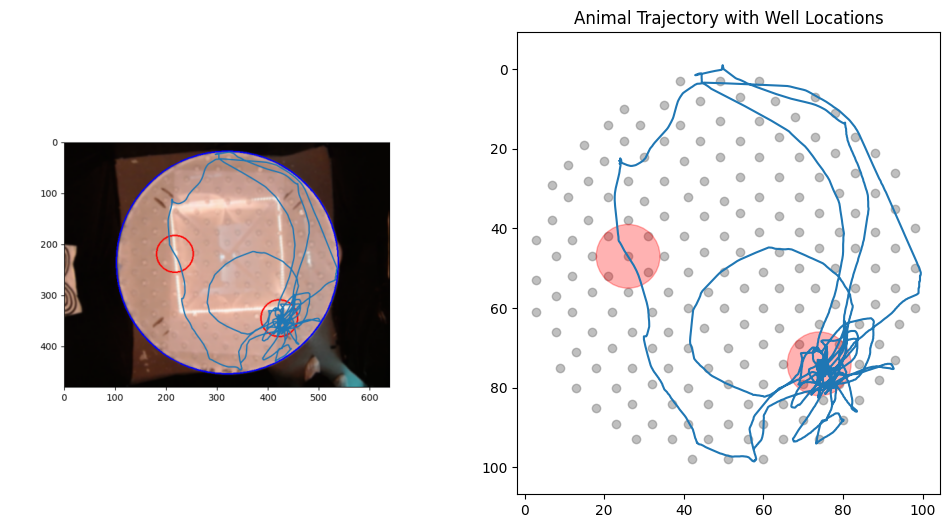

In [278]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')



/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_20470/2628838136.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


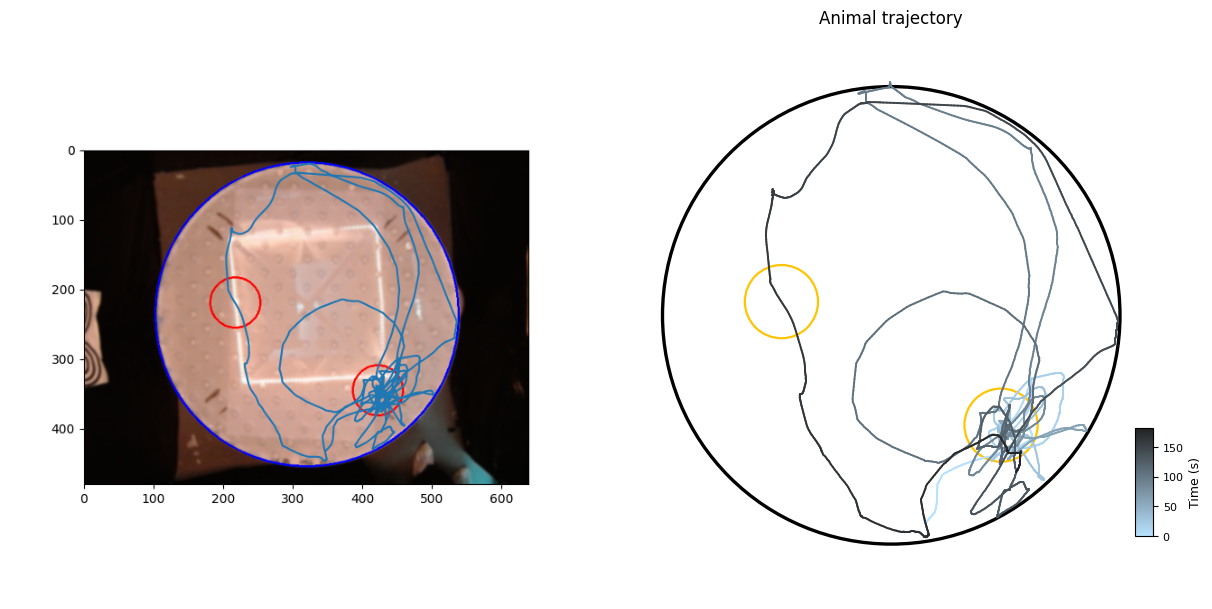

In [270]:
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
import matplotlib as mpl
import numpy as np

# ------------------------------------------------------------
# Cheeseboard geometry
# ------------------------------------------------------------
BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS   = 50

TRIGGER_RADIUS = 8

# padding to make board appear smaller inside panel
PLOT_PADDING = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=(1, 1))

# ------------------------------------------------------------
# Left panel: image
# ------------------------------------------------------------
axes[0].imshow(img)
axes[0].axis('off')

# ------------------------------------------------------------
# Right panel: trajectory
# ------------------------------------------------------------
ax = axes[1]
ax.set_facecolor("white")

# ---- time vector ----
if 't' in position.columns:
    t = position['t'].values.astype(float)
    t = (t - t[0]) / 1000
else:
    t = np.arange(len(position))

x = position['x'].values.astype(float)
y = position['y'].values.astype(float)

ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)

x = x[ok]
y = y[ok]
t = t[ok]

# ------------------------------------------------------------
# Time-coloured trajectory
# ------------------------------------------------------------
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "traj_time",
    ['#b8e2ff', '#222222']
)

norm = mpl.colors.Normalize(t.min(), t.max())

lc = LineCollection(
    segments,
    cmap=cmap,
    norm=norm,
    linewidth=1.4,
    capstyle='round'
)

lc.set_array(t[:-1])
ax.add_collection(lc)

# ------------------------------------------------------------
# Cheeseboard circle
# ------------------------------------------------------------
board_circle = Circle(
    (BOARD_CENTER_X, BOARD_CENTER_Y),
    BOARD_RADIUS,
    color='black',
    fill=False,
    linewidth=2.4
)

ax.add_artist(board_circle)

# ------------------------------------------------------------
# Reward zones (blue)
# ------------------------------------------------------------
for i in range(len(triggerLoc)):

    cx = triggerLoc['x'][i]
    cy = triggerLoc['y'][i]

    reward_circle = Circle(
        (cx, cy),
        TRIGGER_RADIUS,
        color="#ffc404",
        fill=False,
        linewidth=1.6
    )

    ax.add_artist(reward_circle)

# ------------------------------------------------------------
# Make board smaller inside panel
# ------------------------------------------------------------
ax.set_xlim(
    BOARD_CENTER_X - BOARD_RADIUS - PLOT_PADDING,
    BOARD_CENTER_X + BOARD_RADIUS + PLOT_PADDING
)

ax.set_ylim(
    BOARD_CENTER_Y + BOARD_RADIUS + PLOT_PADDING,
    BOARD_CENTER_Y - BOARD_RADIUS - PLOT_PADDING
)

ax.set_aspect('equal')

# remove axes
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Animal trajectory", fontsize=12)

# ------------------------------------------------------------
# Small colorbar bottom right
# ------------------------------------------------------------
cax = fig.add_axes([0.95, 0.13, 0.015, 0.18])

cbar = fig.colorbar(lc, cax=cax)

cbar.set_label("Time (s)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

### Occupancy map

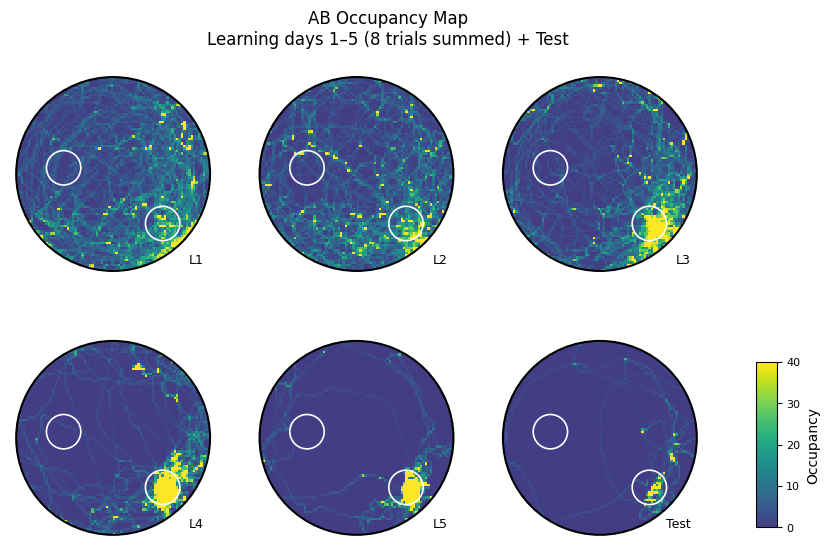

In [303]:
import matplotlib.colors as colors
# ============================================================
# OPTIONS
# ============================================================
ANIMAL_ID = 'AB'
INCLUDE_TEST_DAY = True

NBINS = 80

BOARD_CENTER_X = 50
BOARD_CENTER_Y = 50
BOARD_RADIUS   = 47          # smaller than 50

REWARD_RADIUS = 10 / 1.2

VMIN = 0
VMAX = 40

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

mt = metadata[
    (metadata['usable'] == 1) &
    (metadata['id'] == ANIMAL_ID) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
mt['plot_day'] = np.nan

mask_L = mt['trial_type'] == 'L'
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

if INCLUDE_TEST_DAY:
    L_ses = mt.loc[mt['trial_type'] == 'L', 'ses']

    if len(L_ses) > 0:
        last_L_ses = L_ses.max()
        T_after = mt[(mt['trial_type'] == 'T') & (mt['ses'] > last_L_ses)]

        if len(T_after) > 0:
            first_T_ses = T_after['ses'].min()

            idx = mt.index[
                (mt['trial_type'] == 'T') &
                (mt['ses'] == first_T_ses)
            ]

            mt.loc[idx, 'plot_day'] = 6

plot_days = [1, 2, 3, 4, 5] + ([6] if INCLUDE_TEST_DAY else [])
mt = mt[mt['plot_day'].isin(plot_days)]

# ============================================================
# Helper to load trial
# ============================================================
def load_trial(meta_row):
    dl = DataLoader(meta_row)
    position   = dl.get_data('position')
    triggerLoc = dl.get_data('triggerLoc')
    return position, triggerLoc

# ============================================================
# Build occupancy maps
# ============================================================
x_edges = np.linspace(
    BOARD_CENTER_X - BOARD_RADIUS,
    BOARD_CENTER_X + BOARD_RADIUS,
    NBINS + 1
)

y_edges = np.linspace(
    BOARD_CENTER_Y - BOARD_RADIUS,
    BOARD_CENTER_Y + BOARD_RADIUS,
    NBINS + 1
)

day_maps = {}
trigger_ref = None

for day in plot_days:
    md = mt[mt['plot_day'] == day]

    if len(md) == 0:
        day_maps[day] = None
        continue

    md = md.sort_values('trial_id')

    if day != 6:
        md_use = md
    else:
        md_use = md[md['trial_id'] == 1]
        if len(md_use) == 0:
            md_use = md.iloc[[0]]

    xs = []
    ys = []

    for _, row in md_use.iterrows():
        position, triggerLoc = load_trial(row)

        if position is None:
            continue

        x = position['x'].values.astype(float)
        y = position['y'].values.astype(float)

        ok = np.isfinite(x) & np.isfinite(y)
        if ok.sum() == 0:
            continue

        xs.append(x[ok])
        ys.append(y[ok])

        if trigger_ref is None and triggerLoc is not None:
            trigger_ref = triggerLoc.copy()

    if len(xs) == 0:
        day_maps[day] = None
        continue

    xs = np.concatenate(xs)
    ys = np.concatenate(ys)

    H, _, _ = np.histogram2d(xs, ys, bins=[x_edges, y_edges])
    H = H.T

    day_maps[day] = H

# ============================================================
# Plot
# ============================================================
day_labels = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4', 5: 'L5', 6: 'Test'}

# make panels a bit smaller and give them more space
fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.5))
axes = axes.flatten()

valid_maps = [m for m in day_maps.values() if m is not None]
vmax = VMAX if VMAX is not None else max(np.nanmax(m) for m in valid_maps)

# lighter blue -> green -> yellow
base = plt.cm.viridis
cmap = colors.LinearSegmentedColormap.from_list(
    "viridis_lighter_blue",
    base(np.linspace(0.18, 1.00, 256))   # trims off the darkest blue/purple end
)
cmap.set_bad("white")

for ax, day in zip(axes, plot_days):
    occ = day_maps[day]

    if occ is None:
        ax.axis('off')
        continue

    im = ax.imshow(
        occ,
        extent=[x_edges[0], x_edges[-1], y_edges[-1], y_edges[0]],
        cmap=cmap,
        vmin=VMIN,
        vmax=vmax,
        interpolation='nearest'
    )

    # clip heatmap strictly to cheeseboard circle
    clip_circle = Circle(
        (BOARD_CENTER_X, BOARD_CENTER_Y),
        BOARD_RADIUS,
        transform=ax.transData
    )
    im.set_clip_path(clip_circle)

    # thicker cheeseboard border
    board_circle = Circle(
        (BOARD_CENTER_X, BOARD_CENTER_Y),
        BOARD_RADIUS,
        color='black',
        fill=False,
        linewidth=1.5
    )
    ax.add_artist(board_circle)

    # reward zones
    if trigger_ref is not None:
        for i in range(len(trigger_ref)):
            cx = trigger_ref['x'].iloc[i]
            cy = trigger_ref['y'].iloc[i]

            reward_circle = Circle(
                (cx, cy),
                REWARD_RADIUS,
                color='white',
                fill=False,
                linewidth=1.2
            )
            ax.add_artist(reward_circle)

    # smaller label, bottom-right
    ax.text(
        0.94, 0.05,
        day_labels[day],
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=1.2)
    )

    # make each board occupy a little less of each panel to avoid touching
    panel_pad = 3.0
    ax.set_xlim(BOARD_CENTER_X - BOARD_RADIUS - panel_pad,
                BOARD_CENTER_X + BOARD_RADIUS + panel_pad)
    ax.set_ylim(BOARD_CENTER_Y + BOARD_RADIUS + panel_pad,
                BOARD_CENTER_Y - BOARD_RADIUS - panel_pad)

    ax.set_aspect('equal')
    ax.axis('off')

for j in range(len(plot_days), len(axes)):
    axes[j].axis('off')

fig.suptitle(
    f'{ANIMAL_ID} Occupancy Map\nLearning days 1–5 (8 trials summed) + Test',
    fontsize=12,
    x=0.4, y=0.77)

# ------------------------------------------------------------
# Small colorbar at bottom-right
# ------------------------------------------------------------
cax = fig.add_axes([0.75, 0.08, 0.02, 0.22])
# [left, bottom, width, height] in figure coordinates

cbar = fig.colorbar(im, cax=cax)

cbar.set_label('Occupancy', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# more space between panels
fig.subplots_adjust(
    left=0.04,
    right=0.7,
    bottom=0.05,
    top=0.7,
    wspace=0.18,
    hspace=0.18
)

plt.show()

In [279]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [280]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


### Compute the time animal took to reach the trigger zone

In [281]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,gender,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7251,97,F8,20260503,8,6,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7252,97,F8,20260503,8,7,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7253,97,F8,20260503,8,8,L,5,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN
7254,97,F8,20260504,9,1,T,1,NaN,1,NaN,M,F231A,NaN,0,0,0,NaN


Occupancy metrics

In [304]:
# ============================================================
# Compute exploratory metrics per trial
#
# Adds:
#   1) total_dist
#      = total distance travelled across the whole trial, in cm
#
#   2) occupancy_coverage_pct
#      = % of valid arena bins visited
#      = visited bins / all bins whose centre is inside circular arena
#
#   3) occupancy_entropy
#      = normalized Shannon entropy of occupancy distribution
#      = 0 means very concentrated occupancy
#      = 1 means perfectly evenly distributed across all valid arena bins
#
# Bin size:
#   5 cm bins in real-world units.
#
# Circular arena:
#   Real cheeseboard diameter = 120 cm
#   Tracking coordinate system = 0-100 arbitrary units
#   Therefore:
#       1 tracking unit = 1.2 cm
#       board radius = 60 cm = 50 tracking units
#
# Bin centre rule:
#   A bin is included as valid if its centre is inside the circular arena.
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
BIN_SIZE_CM = 5.0

# Coordinate conversion based on your existing code:
# R_TRIGGER = 10 / 1.2
# so:
#   1 tracking coordinate unit = 1.2 cm
#   5 cm = 5 / 1.2 tracking coordinate units
COORD_TO_CM = 1.2
BIN_SIZE_COORD = BIN_SIZE_CM / COORD_TO_CM

# Real cheeseboard:
#   diameter = 120 cm
#   radius   = 60 cm
# In your tracking coordinates:
#   60 cm / 1.2 = 50 coordinate units
BOARD_DIAMETER_CM = 120.0
BOARD_RADIUS_CM = BOARD_DIAMETER_CM / 2.0

BOARD_CENTER_X = 50.0
BOARD_CENTER_Y = 50.0
BOARD_RADIUS_COORD = BOARD_RADIUS_CM / COORD_TO_CM   # = 50

USE_TIME_WEIGHTED_OCCUPANCY = False
# False = entropy based on sample counts per bin, matching your occupancy map logic.
# True  = entropy based on time spent per bin, using position['t'] if available.

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# Output columns
# ------------------------------------------------------------
metadata['total_dist'] = np.nan
metadata['occupancy_coverage_pct'] = np.nan
metadata['occupancy_entropy'] = np.nan

# Optional useful diagnostic columns
metadata['occupancy_entropy_raw'] = np.nan
metadata['n_valid_occupancy_bins'] = np.nan
metadata['n_visited_occupancy_bins'] = np.nan
metadata['occupancy_bin_size_cm'] = BIN_SIZE_CM
metadata['occupancy_bin_size_coord'] = BIN_SIZE_COORD
metadata['board_radius_cm'] = BOARD_RADIUS_CM
metadata['board_radius_coord'] = BOARD_RADIUS_COORD

# ------------------------------------------------------------
# Build circular arena bin grid
# ------------------------------------------------------------
# Use arange so each bin is exactly 5 cm wide in real space,
# i.e. 5 / 1.2 coordinate units.
#
# The final + small epsilon prevents floating point rounding from
# accidentally dropping the last edge.
# ------------------------------------------------------------
eps = 1e-9

x_edges = np.arange(
    BOARD_CENTER_X - BOARD_RADIUS_COORD,
    BOARD_CENTER_X + BOARD_RADIUS_COORD + BIN_SIZE_COORD + eps,
    BIN_SIZE_COORD
)

y_edges = np.arange(
    BOARD_CENTER_Y - BOARD_RADIUS_COORD,
    BOARD_CENTER_Y + BOARD_RADIUS_COORD + BIN_SIZE_COORD + eps,
    BIN_SIZE_COORD
)

# If arange goes slightly beyond the board boundary because of the added bin,
# keep it. That is okay because valid bins are decided by centre-in-circle.
# This allows edge bins whose centres are inside the board.
x_centres = (x_edges[:-1] + x_edges[1:]) / 2
y_centres = (y_edges[:-1] + y_edges[1:]) / 2

xx, yy = np.meshgrid(x_centres, y_centres)

dist_from_centre_coord = np.sqrt(
    (xx - BOARD_CENTER_X) ** 2 +
    (yy - BOARD_CENTER_Y) ** 2
)

# Include a bin if its centre is inside the real circular arena
valid_bin_mask = dist_from_centre_coord <= BOARD_RADIUS_COORD
n_valid_bins = int(np.sum(valid_bin_mask))

print(f"Real board diameter: {BOARD_DIAMETER_CM:g} cm")
print(f"Real board radius:   {BOARD_RADIUS_CM:g} cm")
print(f"Coordinate radius:   {BOARD_RADIUS_COORD:g} tracking units")
print(f"Coordinate scale:    1 tracking unit = {COORD_TO_CM:g} cm")
print(f"Bin size:            {BIN_SIZE_CM:g} cm = {BIN_SIZE_COORD:.4f} tracking units")
print(f"Grid shape:          {valid_bin_mask.shape}")
print(f"Valid arena bins:    {n_valid_bins}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def compute_total_distance_cm(position):
    """
    Total path length across the whole trial, in cm.

    Uses x/y step distances directly.
    """
    x = position['x'].values.astype(float)
    y = position['y'].values.astype(float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if len(x) < 2:
        return np.nan

    dx = np.diff(x)
    dy = np.diff(y)

    step_dist_coord = np.sqrt(dx * dx + dy * dy)
    total_dist_cm = np.nansum(step_dist_coord) * COORD_TO_CM

    return float(total_dist_cm)


def compute_occupancy_metrics(position):
    """
    Computes:
      occupancy_coverage_pct
      occupancy_entropy_raw
      occupancy_entropy normalized to 0-1

    Uses only bins whose centre is inside the circular cheeseboard.
    Bin size is 5 cm in real space.
    """
    x = position['x'].values.astype(float)
    y = position['y'].values.astype(float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0

    # --------------------------------------------------------
    # Assign each sample to x/y bin
    # --------------------------------------------------------
    x_bin = np.digitize(x, x_edges) - 1
    y_bin = np.digitize(y, y_edges) - 1

    in_grid = (
        (x_bin >= 0) &
        (x_bin < len(x_edges) - 1) &
        (y_bin >= 0) &
        (y_bin < len(y_edges) - 1)
    )

    x_bin = x_bin[in_grid]
    y_bin = y_bin[in_grid]

    if len(x_bin) == 0:
        return np.nan, np.nan, np.nan, 0

    # Keep only samples falling into bins whose centre is inside circle
    inside_circle_bin = valid_bin_mask[y_bin, x_bin]

    x_bin = x_bin[inside_circle_bin]
    y_bin = y_bin[inside_circle_bin]

    if len(x_bin) == 0:
        return np.nan, np.nan, np.nan, 0

    # --------------------------------------------------------
    # Occupancy map
    # --------------------------------------------------------
    occ = np.zeros(valid_bin_mask.shape, dtype=float)

    if USE_TIME_WEIGHTED_OCCUPANCY and 't' in position.columns:
        t = position['t'].values.astype(float)
        t = t[ok]
        t = t[in_grid]
        t = t[inside_circle_bin]

        if len(t) == len(x_bin) and len(t) >= 2:
            dt = np.diff(t, append=t[-1])

            # If time is in ms, convert to seconds.
            # This does not affect normalized entropy or coverage,
            # but keeps occupancy weights interpretable.
            if np.nanmedian(dt) > 1:
                dt = dt / 1000.0

            dt[~np.isfinite(dt)] = 0
            dt[dt < 0] = 0

            weights = dt
        else:
            weights = np.ones(len(x_bin), dtype=float)
    else:
        weights = np.ones(len(x_bin), dtype=float)

    np.add.at(occ, (y_bin, x_bin), weights)

    # Only analyse valid circular arena bins
    occ_valid = occ[valid_bin_mask]

    visited = occ_valid > 0
    n_visited_bins = int(np.sum(visited))

    if n_valid_bins == 0:
        coverage_pct = np.nan
    else:
        coverage_pct = (n_visited_bins / n_valid_bins) * 100.0

    # --------------------------------------------------------
    # Occupancy entropy
    # --------------------------------------------------------
    total_occ = np.nansum(occ_valid)

    if total_occ <= 0 or not np.isfinite(total_occ):
        entropy_raw = np.nan
        entropy_norm = np.nan
    else:
        p = occ_valid / total_occ
        p = p[p > 0]

        entropy_raw = -np.sum(p * np.log(p))

        # Normalize by maximum possible entropy across all valid arena bins.
        # This means:
        #   0 = all occupancy in one bin
        #   1 = perfectly even occupancy across the whole arena
        if n_valid_bins > 1:
            entropy_norm = entropy_raw / np.log(n_valid_bins)
        else:
            entropy_norm = np.nan

    return (
        float(coverage_pct) if np.isfinite(coverage_pct) else np.nan,
        float(entropy_raw) if np.isfinite(entropy_raw) else np.nan,
        float(entropy_norm) if np.isfinite(entropy_norm) else np.nan,
        n_visited_bins
    )


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')

    if position is None or len(position) == 0:
        continue

    if ('x' not in position.columns) or ('y' not in position.columns):
        continue

    # 1) total distance
    total_dist = compute_total_distance_cm(position)

    # 2) coverage and 3) entropy
    coverage_pct, entropy_raw, entropy_norm, n_visited_bins = compute_occupancy_metrics(position)

    metadata.at[trial_id, 'total_dist'] = total_dist
    metadata.at[trial_id, 'occupancy_coverage_pct'] = coverage_pct
    metadata.at[trial_id, 'occupancy_entropy_raw'] = entropy_raw
    metadata.at[trial_id, 'occupancy_entropy'] = entropy_norm
    metadata.at[trial_id, 'n_valid_occupancy_bins'] = n_valid_bins
    metadata.at[trial_id, 'n_visited_occupancy_bins'] = n_visited_bins

# ------------------------------------------------------------
# Quick check
# ------------------------------------------------------------
metadata[[
    'sub',
    'id',
    'ses',
    'trial_type',
    'trial_type_day',
    'total_dist',
    'occupancy_coverage_pct',
    'occupancy_entropy',
    'occupancy_entropy_raw',
    'n_visited_occupancy_bins',
    'n_valid_occupancy_bins',
    'occupancy_bin_size_cm',
    'occupancy_bin_size_coord',
    'board_radius_cm',
    'board_radius_coord'
]].head()

Real board diameter: 120 cm
Real board radius:   60 cm
Coordinate radius:   50 tracking units
Coordinate scale:    1 tracking unit = 1.2 cm
Bin size:            5 cm = 4.1667 tracking units
Grid shape:          (25, 25)
Valid arena bins:    448


 11%|█         | 711/6620 [00:05<00:42, 138.34it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1180/6620 [00:09<00:38, 140.37it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6490/6620 [00:42<00:00, 202.66it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6620/6620 [00:43<00:00, 153.31it/s]


,sub,id,ses,trial_type,trial_type_day,total_dist,occupancy_coverage_pct,occupancy_entropy,occupancy_entropy_raw,n_visited_occupancy_bins,n_valid_occupancy_bins,occupancy_bin_size_cm,occupancy_bin_size_coord,board_radius_cm,board_radius_coord
0,1,A,1,H,1,2882.336023,75.892857,0.875228,5.343084,340.0,448.0,5.0,4.166667,60.0,50.0
1,1,A,1,H,1,2027.951185,65.848214,0.835817,5.102489,295.0,448.0,5.0,4.166667,60.0,50.0
2,1,A,1,H,1,1816.159847,61.160714,0.802596,4.899685,274.0,448.0,5.0,4.166667,60.0,50.0
3,1,A,1,H,1,2111.708247,65.178571,0.822880,5.023513,292.0,448.0,5.0,4.166667,60.0,50.0
4,1,A,1,H,1,2044.428060,64.062500,0.833427,5.087898,287.0,448.0,5.0,4.166667,60.0,50.0



Groups used for plotting/stats: ['ChR2', 'eYFP_ChR2']
Original genotypes loaded: ['ChR2', 'eYFP_ChR2']
Day value mode: daily_mean
Trial column used: inferred from sub/ses order
Gender filter: all

Animals after all filters:
    sub  id gender   genotype
0     1   A    NaN       ChR2
1     3   C    NaN       ChR2
2     4   D    NaN       ChR2
3     6  AB    NaN       ChR2
4     7  AC    NaN       ChR2
5     8  AD    NaN       ChR2
6     9  AE    NaN       ChR2
7    10  AF    NaN       ChR2
8    11  AG    NaN       ChR2
9    12  AH    NaN       ChR2
10   16  AM    NaN       ChR2
11   18  AO    NaN       ChR2
12   19   E    NaN  eYFP_ChR2
13   20  EE    NaN  eYFP_ChR2
14   21  EF    NaN  eYFP_ChR2
15   22   F    NaN  eYFP_ChR2
16   23   G    NaN  eYFP_ChR2

=== Line plot: total_dist ===
VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']


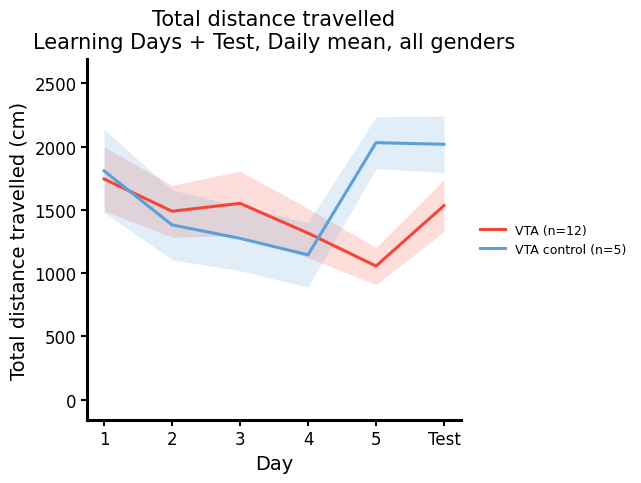


=== Line plot: occupancy_coverage_pct ===
VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']


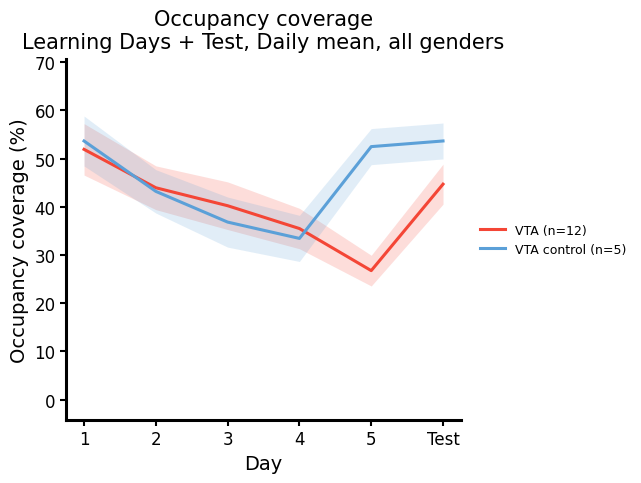


=== Line plot: occupancy_coverage_cm2 ===
VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']


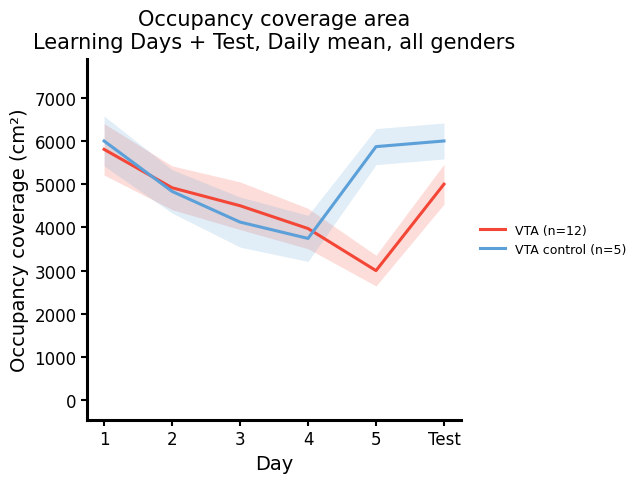


=== Line plot: occupancy_entropy ===
VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']


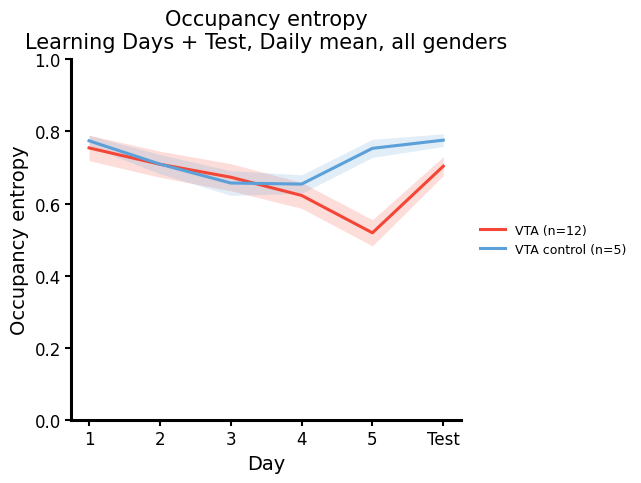


=== Test-day boxplot: total_dist ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=1532.555 vs 2017.694, median=1358.612 vs 2133.231, U=16.0, rank-biserial=-0.467, p=0.15999


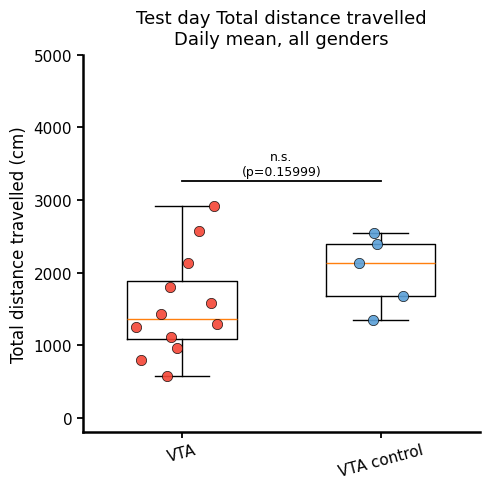


=== Test-day boxplot: occupancy_coverage_pct ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=44.699 vs 53.661, median=43.638 vs 52.679, U=16.0, rank-biserial=-0.467, p=0.15999


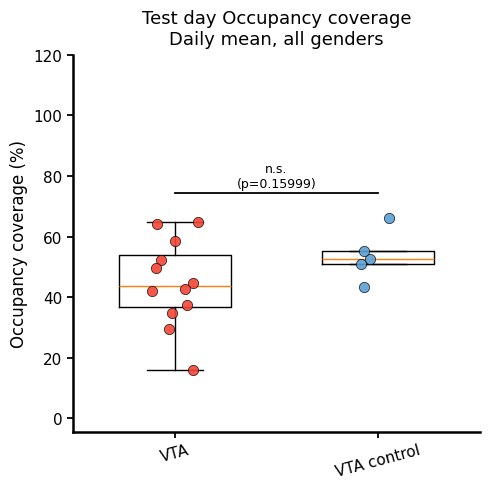


=== Test-day boxplot: occupancy_coverage_cm2 ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=5006.250 vs 6010.000, median=4887.500 vs 5900.000, U=16.0, rank-biserial=-0.467, p=0.15999


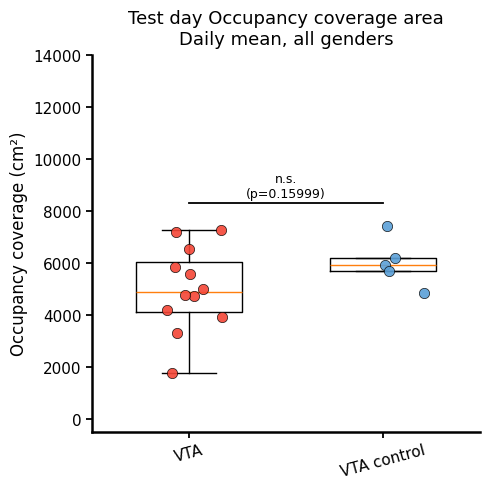


=== Test-day boxplot: occupancy_entropy ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=0.704 vs 0.776, median=0.740 vs 0.791, U=15.0, rank-biserial=-0.500, p=0.12961


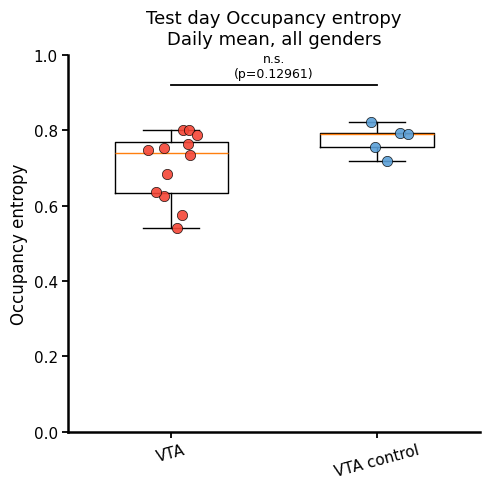


=== Learning-days 1-5 average boxplot: total_dist ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=1430.770 vs 1527.189, median=1545.072 vs 1712.175, U=23.0, rank-biserial=-0.233, p=0.50582


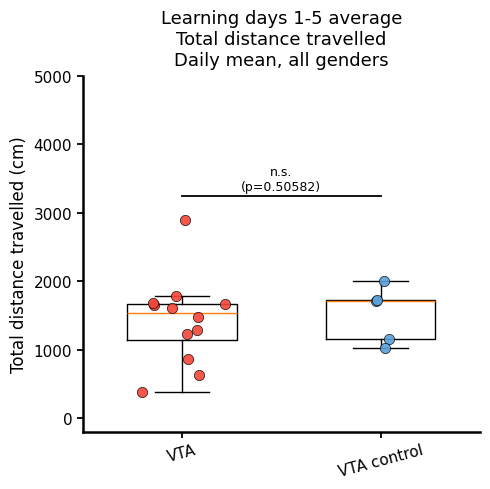


=== Learning-days 1-5 average boxplot: occupancy_coverage_pct ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=39.672 vs 43.924, median=41.454 vs 47.282, U=24.0, rank-biserial=-0.200, p=0.57434


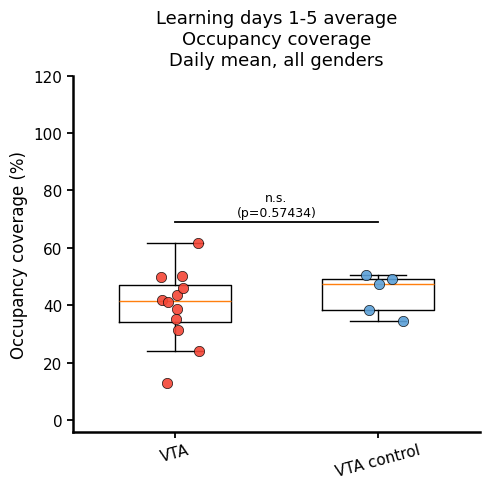


=== Learning-days 1-5 average boxplot: occupancy_coverage_cm2 ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=4443.229 vs 4919.500, median=4642.812 vs 5295.625, U=24.0, rank-biserial=-0.200, p=0.57434


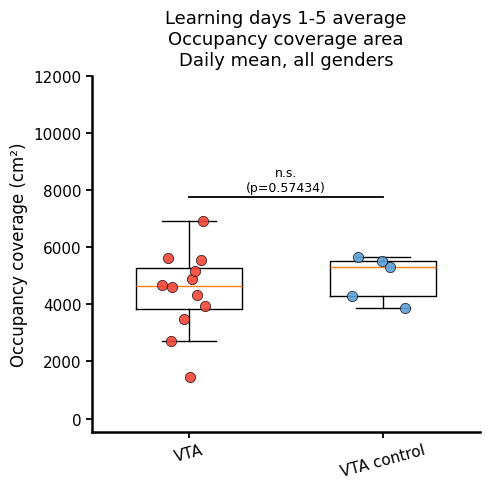


=== Learning-days 1-5 average boxplot: occupancy_entropy ===
  VTA (ChR2): n = 12, animals = [np.str_('A'), np.str_('C'), np.str_('D'), np.str_('AB'), np.str_('AC'), np.str_('AD'), np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('AM'), np.str_('AO')]
  VTA control (eYFP_ChR2): n = 5, animals = [np.str_('E'), np.str_('EE'), np.str_('EF'), np.str_('F'), np.str_('G')]

Mann–Whitney U tests:
  VTA vs VTA control: n=12 vs 5, mean=0.656 vs 0.710, median=0.662 vs 0.711, U=16.0, rank-biserial=-0.467, p=0.15999


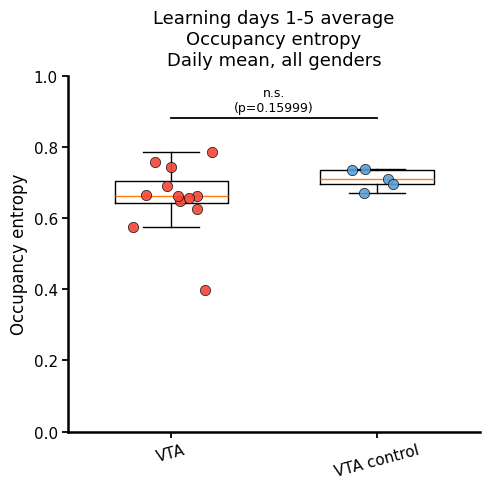

In [317]:
# Exploratory metrics across L1-L5 + Test
#
# Metrics:
#   total_dist
#       = total distance travelled across the whole trial
#
#   occupancy_coverage_pct
#       = % of valid arena bins visited
#
#   occupancy_coverage_cm2
#       = visited arena area in cm²
#       = n visited bins × 5 cm × 5 cm
#
#   occupancy_entropy
#       = normalized Shannon entropy of occupancy distribution
#
# DAY_VALUE_MODE:
#   'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   'first_trial'
#       learning days = first trial only from each day
#       test day      = first test trial only
#
# Gender option:
#   GENDER_FILTER = None      -> include all animals
#   GENDER_FILTER = 'F'       -> females only
#   GENDER_FILTER = 'M'       -> males only
#   GENDER_FILTER = ['F','M'] -> explicit both
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
GROUPS = ['ChR2','eYFP_ChR2']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['CA1', 'CA3', 'Control']

# Gender filter
GENDER_FILTER = None
# GENDER_FILTER = 'M'
# GENDER_FILTER = None 
# GENDER_FILTER = ['F', 'M']

# How to compute each animal × day value
DAY_VALUE_MODE = 'daily_mean'
# DAY_VALUE_MODE = 'daily_mean' or 'first_trial'

# Pooled control group
POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A wt',
}

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False
SHOW_ANIMAL_IDS = False

JITTER = 0.10
DOT_SIZE = 55
P_DECIMALS = 5

RUN_LINE_PLOTS = True
RUN_TEST_BOXPLOTS = True
RUN_LEARNING_AVG_BOXPLOTS = True

# Main exploratory metrics
METRICS_TO_PLOT = [
    'total_dist',
    'occupancy_coverage_pct',
    'occupancy_coverage_cm2',
    'occupancy_entropy',
]

LEARNING_AVG_BOXPLOT_METRICS = [
    'total_dist',
    'occupancy_coverage_pct',
    'occupancy_coverage_cm2',
    'occupancy_entropy',
]

METRIC_LABEL = {
    'total_dist': 'Total distance travelled (cm)',
    'occupancy_coverage_pct': 'Occupancy coverage (%)',
    'occupancy_coverage_cm2': 'Occupancy coverage (cm²)',
    'occupancy_entropy': 'Occupancy entropy',
}

METRIC_TITLE = {
    'total_dist': 'Total distance travelled',
    'occupancy_coverage_pct': 'Occupancy coverage',
    'occupancy_coverage_cm2': 'Occupancy coverage area',
    'occupancy_entropy': 'Occupancy entropy',
}

YMAX_BY_METRIC = {
    'total_dist': None,
    'occupancy_coverage_pct': None,
    'occupancy_coverage_cm2': None,
    'occupancy_entropy': 1.0,
}

YMIN_BY_METRIC = {
    'total_dist': None,
    'occupancy_coverage_pct': None,
    'occupancy_coverage_cm2': None,
    'occupancy_entropy': 0.0,
}

Y_BOTTOM_PAD_FRAC = 0.06
BOX_Y_ZERO_PAD_FRAC = 0.04

# If occupancy_coverage_cm2 is not already in metadata,
# the code can create it from n_visited_occupancy_bins.
BIN_SIZE_CM = 5.0
BIN_AREA_CM2 = BIN_SIZE_CM ** 2

# Boxplot options
COMPARISONS = 'all'
# COMPARISONS = [('F231A', 'F231A_wt')]

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")

# ---------------------------------------------------------------------
# 0. Add occupancy_coverage_cm2 if possible
# ---------------------------------------------------------------------
if 'occupancy_coverage_cm2' not in metadata.columns:
    if 'n_visited_occupancy_bins' in metadata.columns:
        metadata['occupancy_coverage_cm2'] = (
            metadata['n_visited_occupancy_bins'].astype(float) * BIN_AREA_CM2
        )
        print("Created occupancy_coverage_cm2 from n_visited_occupancy_bins.")
    else:
        print(
            "Warning: occupancy_coverage_cm2 is not in metadata, "
            "and n_visited_occupancy_bins is also missing, so cm² coverage cannot be computed."
        )

# ---------------------------------------------------------------------
# 1. Base filter and assign plot_day
# ---------------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
] + METRICS_TO_PLOT

if GENDER_FILTER is not None:
    needed_cols.append('gender')

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

# If GROUPS contains 'Control', include its original component groups.
groups_to_load = []
for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(groups_to_load)) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# ------------------------------------------------------------
# Apply gender filter
# ------------------------------------------------------------
if GENDER_FILTER is not None:
    if isinstance(GENDER_FILTER, str):
        gender_values = [GENDER_FILTER]
    else:
        gender_values = list(GENDER_FILTER)

    gender_values = [str(g).upper() for g in gender_values]

    meta_LT = meta_LT[
        meta_LT['gender'].astype(str).str.upper().isin(gender_values)
    ].copy()

# Store original genotype before pooling
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool controls into one displayed/statistical group: Control
if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# Assign plot_day
# L days 1-5 -> plot_day 1-5
# first T session after last L -> plot_day 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ---------------------------------------------------------------------
# 1b. Add trial_in_day, needed for DAY_VALUE_MODE = 'first_trial'
# ---------------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session',
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()

# ---------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals.
    Example:
      N8 (NAc_control)
      X3 (CA1_control)
      A1 (eYFP_ChR2)
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    gender_txt = ""
    if 'gender' in ms.columns and ms['gender'].notna().any():
        gender_txt = f", {str(ms['gender'].dropna().iloc[0])}"

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original}{gender_txt})'

    if gender_txt != "":
        return f'{animal_id} ({gender_txt.replace(", ", "")})'

    return animal_id


def get_day_value(ms, day, value_col):
    """
    Returns one value for one animal on one plot_day.

    DAY_VALUE_MODE:
      'daily_mean'  -> mean across all available trials in that day
      'first_trial' -> trial_in_day == 1 only
    """
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna())
    ].copy()

    if len(md) == 0:
        return np.nan

    # mean per trial first, in case duplicate rows exist for same trial
    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan
        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def get_test_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()
        value = get_day_value(ms, 6, value_col)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'value': value,
            'animal_id': get_animal_label(ms, sub)
        })

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def get_learning_avg_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['plot_day'].isin([1, 2, 3, 4, 5])) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()

        vals_day = np.array(
            [get_day_value(ms, d, value_col) for d in [1, 2, 3, 4, 5]],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals_day)):
            continue

        if np.all(np.isnan(vals_day)):
            continue

        value = np.nanmean(vals_day)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'animal_id': get_animal_label(ms, sub),
            'value': value
        })

    if len(rows) == 0:
        return np.array([]), np.array([]), np.array([])

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def style_nature(ax):
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)


def apply_y_axis(ax, ymax_candidates, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        ymax = manual_ymax
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if manual_ymin is not None:
        ymin = manual_ymin
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return stat, p


def get_comparisons():
    if COMPARISONS == 'all':
        comparisons = []
        for i in range(len(GROUPS)):
            for j in range(i + 1, len(GROUPS)):
                comparisons.append((GROUPS[i], GROUPS[j]))
        return comparisons
    return COMPARISONS


def gender_label_for_title():
    if GENDER_FILTER is None:
        return "all genders"

    if isinstance(GENDER_FILTER, str):
        return f"gender = {GENDER_FILTER}"

    return "gender = " + "/".join([str(g) for g in GENDER_FILTER])


def day_value_label_for_title():
    if DAY_VALUE_MODE == 'first_trial':
        return "First trial only"
    return "Daily mean"


# ---------------------------------------------------------------------
# 3. Line plot helper
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col):
    ylabel = METRIC_LABEL.get(value_col, value_col)
    title_base = METRIC_TITLE.get(value_col, value_col)

    group_data = {}

    print(f"\n=== Line plot: {value_col} ===")

    for g in GROUPS:
        meta_g = meta_LT[meta_LT['genotype'] == g].copy()
        mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, value_col)

        group_data[g] = {
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"{DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

    fig, ax = plt.subplots(figsize=(8, 5.2))

    ymax_candidates = []

    for g in GROUPS:
        mat = group_data[g]['mat']
        subs = group_data[g]['subs']

        if mat is None or len(subs) == 0:
            continue

        col = get_genotype_color(g)
        label = DISPLAY_NAME.get(g, g)

        if PLOT_INDIVIDUAL:
            for row in mat:
                ax.plot(
                    x_vals,
                    row,
                    '-',
                    color=col,
                    alpha=0.12,
                    linewidth=1.0,
                    label='_nolegend_',
                    zorder=1
                )

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=col,
                alpha=0.18,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if SHOW_SEM_ERRORBARS:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        ymax_candidates.append(np.nanmax(mean_ + sem_))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{title_base}\nLearning Days + Test, {day_value_label_for_title()}, {gender_label_for_title()}',
        fontsize=15,
        pad=8
    )

    style_nature(ax)
    apply_y_axis(ax, ymax_candidates, value_col)

    ax.legend(
        frameon=False,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()


# ---------------------------------------------------------------------
# 4. Boxplot helper
# ---------------------------------------------------------------------
def plot_boxplot(metric_col, boxplot_mode):
    ylabel = METRIC_LABEL.get(metric_col, metric_col)
    title_base = METRIC_TITLE.get(metric_col, metric_col)

    group_vals = {}
    group_subs = {}
    group_ids = {}

    if boxplot_mode == 'test':
        print(f"\n=== Test-day boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_test_group_vals(meta_test, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    elif boxplot_mode == 'learning_mean':
        print(f"\n=== Learning-days 1-5 average boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_learning_avg_group_vals(meta_LT, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    else:
        raise ValueError("boxplot_mode must be 'test' or 'learning_mean'")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_vals[g])}, animals = {list(group_ids[g])}"
        )

    data = [group_vals[g] for g in GROUPS]
    positions = np.arange(len(GROUPS))

    fig, ax = plt.subplots(figsize=(max(5, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = group_vals[g]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(g),
            edgecolor='k',
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_ids[g]):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # comparisons
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in get_comparisons():
        if g1 not in GROUPS or g2 not in GROUPS:
            print(f"Skipping {g1} vs {g2}: group not in GROUPS")
            continue

        vals1 = group_vals[g1]
        vals2 = group_vals[g2]

        stat, p = mwu(vals1, vals2)

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.3f} vs {np.nanmean(vals2):.3f}, "
                f"median={np.nanmedian(vals1):.3f} vs {np.nanmedian(vals2):.3f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )
        else:
            print(f"  {g1} vs {g2}: p = NaN")

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    # significance lines
    nonempty_data = [v for v in data if len(v) > 0]

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        current_y = ymax + 0.12 * yrng
        y_step = 0.28 * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2

            ax.plot(
                [positions[x1], positions[x2]],
                [current_y, current_y],
                color='k',
                lw=1.3
            )

            ax.text(
                x_mid,
                current_y + 0.015 * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        ymax_box = current_y + 0.25 * yrng

        manual_ymax = YMAX_BY_METRIC.get(metric_col, None)
        manual_ymin = YMIN_BY_METRIC.get(metric_col, None)

        if manual_ymax is not None:
            ymax_box = manual_ymax

        if manual_ymin is not None:
            ymin = manual_ymin
        else:
            ymin = -BOX_Y_ZERO_PAD_FRAC * ymax_box

        ax.set_ylim(ymin, ymax_box)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)

    if boxplot_mode == 'test':
        ax.set_title(
            f"Test day {title_base}\n{day_value_label_for_title()}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )
    else:
        ax.set_title(
            f"Learning days 1-5 average\n{title_base}\n{day_value_label_for_title()}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.tick_params(axis='y', labelsize=11)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 5. Run plots
# ---------------------------------------------------------------------
print("\nGroups used for plotting/stats:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
print("Day value mode:", DAY_VALUE_MODE)
print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Gender filter:", GENDER_FILTER if GENDER_FILTER is not None else "all")

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nAnimals after all filters:")
if len(meta_LT) > 0:
    cols_to_print = ['sub']
    if 'id' in meta_LT.columns:
        cols_to_print.append('id')
    if 'gender' in meta_LT.columns:
        cols_to_print.append('gender')
    cols_to_print.append('genotype')

    print(
        meta_LT[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")

if RUN_LINE_PLOTS:
    for metric in METRICS_TO_PLOT:
        plot_metric_for_groups(meta_LT, metric)

if RUN_TEST_BOXPLOTS:
    for metric in METRICS_TO_PLOT:
        plot_boxplot(metric, boxplot_mode='test')

if RUN_LEARNING_AVG_BOXPLOTS:
    for metric in LEARNING_AVG_BOXPLOT_METRICS:
        plot_boxplot(metric, boxplot_mode='learning_mean')

Using genotype: VTA (ChR2)
Using column: occupancy_coverage_pct
Using label: Occupancy coverage (%)
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 12
    sub  id  Day 1 trials  Day 5 trials
0     1   A             8             8
1     3   C             8             8
2     4   D             8             8
3     6  AB             8             8
4     7  AC             8             8
5     8  AD             8             8
6     9  AE             8             8
7    10  AF             8             8
8    11  AG             8             8
9    12  AH             8             8
10   16  AM             8             8
11   18  AO             8             8

Paired values used for Wilcoxon:
    sub  id         y1         y2  diff_y2_minus_y1  n1  n2
0     1   A  62.946429  29.157366        -33.789062   8   8
1     3   C  62.081473  28.543527        -33.537946   8   8
2     4   D  59.179688  30.078125        -29.101563   8

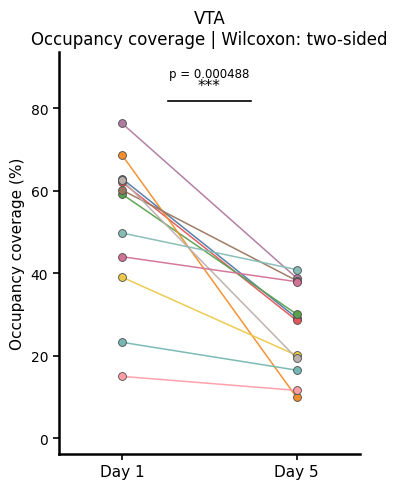

In [315]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flexible genotype:
# Paired comparison for exploration metrics
#
# Metrics:
#   total_dist
#       = total distance travelled across the whole trial
#
#   occupancy_coverage_cm2
#       = area of arena covered, in cm²
#
#   occupancy_coverage_pct
#       = percentage of valid arena bins visited
#
# COMPARE_MODE:
#   'day1_vs_test':
#       Day 1 = trial 1 only
#       Test  = first post-learning test trial only
#
#   'day1_vs_day5':
#       Day 1 = mean across available Day 1 trials
#       Day 5 = mean across available Day 5 trials
#
#   'day1_trial1_vs_day5_trial1':
#       Day 1 = trial 1 only
#       Day 5 = trial 1 only
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_vs_day5'
# COMPARE_MODE = 'day1_vs_day5'
# COMPARE_MODE = 'day1_trial1_vs_day5_trial1'

GENOTYPE_TO_USE = 'ChR2'

PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False
SHOW_ANIMAL_IDS = False

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

# ------------------------------------------------------------
# Choose exploration metric
# ------------------------------------------------------------
VALUE_COL = 'occupancy_coverage_pct'
# VALUE_COL = 'occupancy_coverage_cm2'
# VALUE_COL = 'occupancy_coverage_pct'

METRIC_INFO = {
    'total_dist': {
        'label': 'Total distance travelled (cm)',
        'title': 'Total distance travelled'
    },
    'occupancy_coverage_cm2': {
        'label': 'Occupancy coverage (cm²)',
        'title': 'Occupancy coverage'
    },
    'occupancy_coverage_pct': {
        'label': 'Occupancy coverage (%)',
        'title': 'Occupancy coverage'
    },
}

if VALUE_COL not in METRIC_INFO:
    raise ValueError(
        "VALUE_COL must be one of: "
        "'total_dist', 'occupancy_coverage_cm2', 'occupancy_coverage_pct'"
    )

VALUE_LABEL = METRIC_INFO[VALUE_COL]['label']
VALUE_TITLE = METRIC_INFO[VALUE_COL]['title']

# Optional short-duration filter
FILTER_SHORT_DURATION = False

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether y1 > y2
# 'less'      = tests whether y1 < y2
WILCOXON_ALTERNATIVE = 'two-sided'

INDIVIDUAL_COLOR_MODE = 'pastel'
DOT_EDGE = True

YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Check required columns
# ------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
    VALUE_COL,
]

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(
        f"Missing columns in metadata: {missing_cols}\n"
        f"Make sure you ran the exploration metric computation code first."
    )

# ------------------------------------------------------------
# 2) Filter
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 3) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 4) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using column:", VALUE_COL)
print("Using label:", VALUE_LABEL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 5) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    """
    One value per animal = mean across available trials in that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(np.nanmean(by_trial.values)),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day, value_col):
    """
    One value per animal = trial 1 only from that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 6) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 6, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    comparison_description = 'Day 1 trial 1 vs Test trial 1'

elif COMPARE_MODE == 'day1_vs_day5':
    day1_df = per_subject_day_mean(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_mean(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1'
    right_label = 'Day 5'
    comparison_description = 'Day 1 daily mean vs Day 5 daily mean'

elif COMPARE_MODE == 'day1_trial1_vs_day5_trial1':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Day 5 trial 1'
    comparison_description = 'Day 1 trial 1 vs Day 5 trial 1'

else:
    raise ValueError(
        "COMPARE_MODE must be 'day1_vs_test', "
        "'day1_vs_day5', or 'day1_trial1_vs_day5_trial1'"
    )

title_txt = f'{GENOTYPE_LABEL}'

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
if len(paired) > 0:
    paired_print = paired.copy()
    paired_print['diff_y2_minus_y1'] = paired_print['y2'] - paired_print['y1']
    print(paired_print[['sub', 'id', 'y1', 'y2', 'diff_y2_minus_y1', 'n1', 'n2']])
else:
    print("No paired data.")

# ------------------------------------------------------------
# 7) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.3g}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)

print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")
print(comparison_description)

# ------------------------------------------------------------
# 8) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 9) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

x1, x2 = 0.00, 0.55

n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'], row['y2']],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'], row['y2']],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'],
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

if PLOT_GROUP_MEAN and len(y1) > 0:
    m1 = np.nanmean(y1)
    m2 = np.nanmean(y2)

    s1 = 0.0 if len(y1) <= 1 else np.nanstd(y1, ddof=1) / np.sqrt(len(y1))
    s2 = 0.0 if len(y2) <= 1 else np.nanstd(y2, ddof=1) / np.sqrt(len(y2))

    ax.plot([x1, x2], [m1, m2], '-', color=base_col, linewidth=2.4, zorder=3)

    ax.errorbar(
        x1, m1, yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2, m2, yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Significance line + stars + p value
# ------------------------------------------------------------
all_y = np.r_[y1, y2]

if len(all_y) > 0 and np.isfinite(all_y).any():
    ymax_data = np.nanmax(all_y)
    ymin_data = np.nanmin(all_y)
    yrng = ymax_data - ymin_data

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = ymax_data if ymax_data > 0 else 1.0

    y_line = ymax_data + 0.08 * yrng
    y_star = ymax_data + 0.11 * yrng
    y_pval = ymax_data + 0.16 * yrng
else:
    ymax_data = 1.0
    yrng = 1.0
    y_line = 1.08
    y_star = 1.11
    y_pval = 1.16

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel(VALUE_LABEL, fontsize=11)

ax.set_title(
    f'{title_txt}\n{VALUE_TITLE} | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is not None:
    ymax = YMAX
else:
    ymax = y_pval + 0.10 * yrng

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()

In [321]:
import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# Existing metric
metadata['dist_to_trigger'] = np.nan

# New metrics (all based on the *zone actually entered first*
# or, if never entered, the nearest zone to the start)
metadata['first_choice_trigger'] = np.nan   # which trigger (1/2/3…)
metadata['L_actual']             = np.nan   # actual path length used for analysis
metadata['L_shortest']           = np.nan   # straight-line to edge of that zone
metadata['CIPL']                 = np.nan   # L_actual − L_shortest
metadata['path_eff']             = np.nan   # L_shortest / L_actual * 100

R_TRIGGER = (10/1.2)

# --- SETTINGS you can comment/uncomment ---
REQUIRE_STAY_2S = False          # False → any entry; True → require ≥2 s stay
MIN_DUR_MS      = 2000           # min duration threshold in ms
# -----------------------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # ---- Load position ----
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # ---- Load trigger locations ----
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    # ---- Add cumulative distance ----
    pos = add_distance_travelled(position)
    if pos is None or len(pos) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    # ---- Add distance-to-trigger columns ----
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i+1)
        if df_trig is None or len(df_trig) == 0:
            continue
        df_trig['trigger_id'] = i + 1
        dfs.append(df_trig)

    # ------------------------------------------------------------
    # CASE 1: never entered ANY reward zone
    # → L_actual = full-trial distance
    # → choose zone closest to start for L_shortest etc.
    # ------------------------------------------------------------
    if len(dfs) == 0:
        # actual path length = full trial
        full_dist = float(pos_['cum_dist'].iloc[-1])

        # starting position
        x0 = float(pos_['x'].iloc[0])
        y0 = float(pos_['y'].iloc[0])

        # distance from start to each zone center
        centers = np.array([
            [float(triggerLoc.iloc[i]['x']), float(triggerLoc.iloc[i]['y'])]
            for i in range(trigger_num)
        ])
        dx = centers[:, 0] - x0
        dy = centers[:, 1] - y0
        d_center = np.sqrt(dx * dx + dy * dy)

        # pick closest zone
        nearest_idx = int(np.argmin(d_center))   # 0-based
        trig_first  = nearest_idx + 1            # 1-based trigger_id

        d_min_center = float(d_center[nearest_idx])
        # shortest distance to edge of that trigger
        L_shortest = max(d_min_center - R_TRIGGER, 0.0)

        # CIPL and path efficiency
        CIPL = full_dist - L_shortest
        path_eff = (L_shortest / full_dist) * 100.0 if full_dist > 0 else np.nan

        # store
        metadata.at[trial_id, 'dist_to_trigger']     = full_dist
        metadata.at[trial_id, 'first_choice_trigger'] = trig_first
        metadata.at[trial_id, 'L_actual']           = full_dist
        metadata.at[trial_id, 'L_shortest']         = L_shortest
        metadata.at[trial_id, 'CIPL']               = CIPL
        metadata.at[trial_id, 'path_eff']           = path_eff

        continue  # go to next trial

    # ------------------------------------------------------------
    # CASE 2: at least one entry to a reward zone
    # ------------------------------------------------------------
    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    # OPTIONAL: require ≥ MIN_DUR_MS stays
    if REQUIRE_STAY_2S:
        df_use = df_all[df_all['duration'] >= MIN_DUR_MS].copy()

        # If no such stays, treat like "never reached" but still
        # choose closest reward zone from start.
        if len(df_use) == 0:
            full_dist = float(pos_['cum_dist'].iloc[-1])

            x0 = float(pos_['x'].iloc[0])
            y0 = float(pos_['y'].iloc[0])

            centers = np.array([
                [float(triggerLoc.iloc[i]['x']), float(triggerLoc.iloc[i]['y'])]
                for i in range(trigger_num)
            ])
            dx = centers[:, 0] - x0
            dy = centers[:, 1] - y0
            d_center = np.sqrt(dx * dx + dy * dy)

            nearest_idx = int(np.argmin(d_center))
            trig_first  = nearest_idx + 1
            d_min_center = float(d_center[nearest_idx])

            L_shortest = max(d_min_center - R_TRIGGER, 0.0)
            CIPL = full_dist - L_shortest
            path_eff = (L_shortest / full_dist) * 100.0 if full_dist > 0 else np.nan

            metadata.at[trial_id, 'dist_to_trigger']     = full_dist
            metadata.at[trial_id, 'first_choice_trigger'] = trig_first
            metadata.at[trial_id, 'L_actual']           = full_dist
            metadata.at[trial_id, 'L_shortest']         = L_shortest
            metadata.at[trial_id, 'CIPL']               = CIPL
            metadata.at[trial_id, 'path_eff']           = path_eff
            continue
    else:
        df_use = df_all

    # ------------------------------------------------------------
    # First *chosen* reward zone: earliest qualifying entry
    # ------------------------------------------------------------
    first_entry   = df_use.iloc[0]
    t_enter_first = first_entry['t_enter']
    trig_first    = int(first_entry['trigger_id'])

    # L_actual: distance travelled up to that time
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    if len(idxs) == 0:
        L_actual = 0.0
    else:
        L_actual = float(pos_['cum_dist'].iloc[idxs[-1]])

    # ------------------------------------------------------------
    # L_shortest: straight-line from start → edge of *that* trigger
    # ------------------------------------------------------------
    x0 = float(pos_['x'].iloc[0])
    y0 = float(pos_['y'].iloc[0])

    cx = float(triggerLoc.iloc[trig_first - 1]['x'])
    cy = float(triggerLoc.iloc[trig_first - 1]['y'])

    dx = cx - x0
    dy = cy - y0
    d_center = np.sqrt(dx * dx + dy * dy)

    L_shortest = max(d_center - R_TRIGGER, 0.0)

    # ------------------------------------------------------------
    # CIPL + path efficiency
    # ------------------------------------------------------------
    CIPL = L_actual - L_shortest if np.isfinite(L_actual) and np.isfinite(L_shortest) else np.nan
    if L_actual > 0:
        path_eff = (L_shortest / L_actual) * 100.0
    else:
        path_eff = np.nan

    # ------------------------------------------------------------
    # Store everything
    # ------------------------------------------------------------
    metadata.at[trial_id, 'dist_to_trigger']      = L_actual
    metadata.at[trial_id, 'first_choice_trigger'] = trig_first
    metadata.at[trial_id, 'L_actual']             = L_actual
    metadata.at[trial_id, 'L_shortest']           = L_shortest
    metadata.at[trial_id, 'CIPL']                 = CIPL
    metadata.at[trial_id, 'path_eff']             = path_eff

# quick check
metadata[['sub','ses','trial_type','trial_type_day',
          'dist_to_trigger',
          'first_choice_trigger',
          'L_actual',
          'L_shortest',
          'CIPL',
          'path_eff']].head()

 11%|█         | 705/6620 [00:08<01:02, 93.91it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 18%|█▊        | 1181/6620 [00:13<00:54, 100.66it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 39%|███▉      | 2610/6620 [00:26<00:26, 153.00it/s]

...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


 98%|█████████▊| 6481/6620 [01:01<00:01, 126.22it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-095_id-F6/ses-05_date-20260430/behav/sub-095_ses-05_trial-01_data-position.csv' does not exist.


100%|██████████| 6620/6620 [01:02<00:00, 105.48it/s]


,sub,ses,trial_type,trial_type_day,dist_to_trigger,first_choice_trigger,L_actual,L_shortest,CIPL,path_eff
0,1,1,H,1,21.004940,5.0,21.004940,2.704986,18.299953,12.877858
1,1,1,H,1,121.123247,3.0,121.123247,63.736658,57.386590,52.621325
2,1,1,H,1,4.226850,5.0,4.226850,3.492875,0.733975,82.635420
3,1,1,H,1,7.878806,5.0,7.878806,5.881602,1.997203,74.650938
4,1,1,H,1,132.454986,4.0,132.454986,45.804395,86.650591,34.581103



Groups used for plotting/stats: ['F231A', 'F231A_wt']
Original genotypes loaded: ['F231A', 'F231A_wt']
Day value mode: first_trial
Trial column used: inferred from sub/ses order
Gender filter: F
Stay tag:  (≥2 s stay)

Animals after all filters:
    sub  id gender  genotype
0    50  BD      F  F231A_wt
1    51  BE      F     F231A
2    52  BF      F     F231A
3    53  BG      F     F231A
4    54  BH      F     F231A
5    55  BI      F     F231A
6    60  BO      F  F231A_wt
7    63  BR      F     F231A
8    90  F1      F  F231A_wt
9    91  F2      F  F231A_wt
10   92  F3      F     F231A
11   93  F4      F     F231A

=== Line plot: dist_to_trigger ===
F231A (F231A): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A wt (F231A_wt): n = 4, ids = ['BD (F)', 'BO (F)', 'F1 (F)', 'F2 (F)']


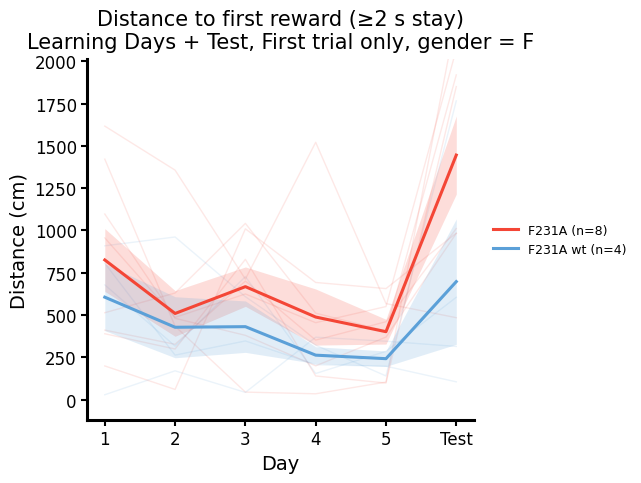


=== Line plot: CIPL ===
F231A (F231A): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A wt (F231A_wt): n = 4, ids = ['BD (F)', 'BO (F)', 'F1 (F)', 'F2 (F)']


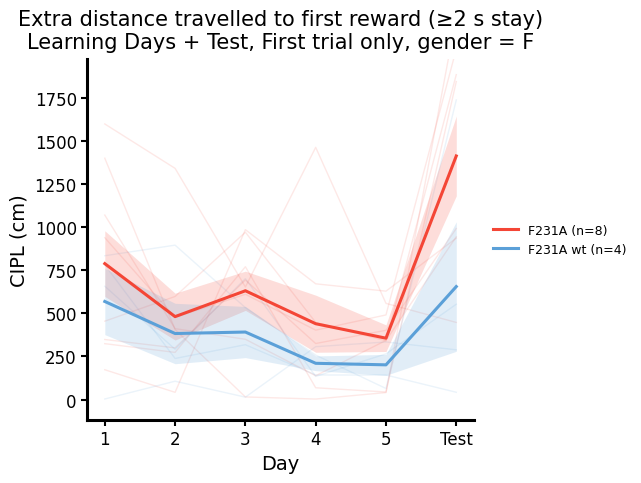


=== Line plot: path_eff ===
F231A (F231A): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A wt (F231A_wt): n = 4, ids = ['BD (F)', 'BO (F)', 'F1 (F)', 'F2 (F)']


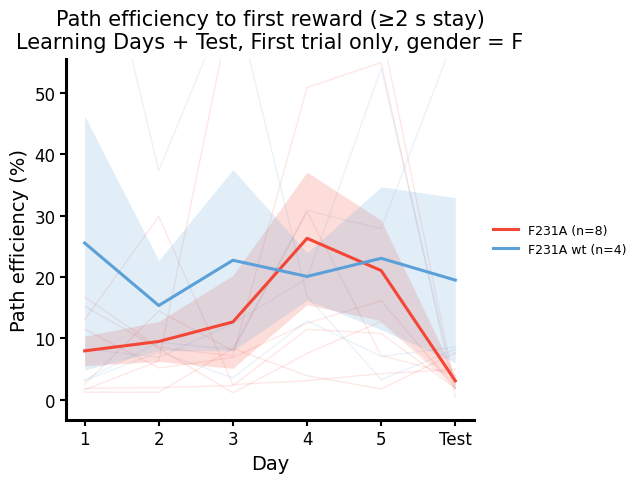


=== Test-day boxplot: dist_to_trigger ===
  F231A (F231A): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A wt (F231A_wt): n = 4, animals = [np.str_('BD (F)'), np.str_('BO (F)'), np.str_('F1 (F)'), np.str_('F2 (F)')]

Mann–Whitney U tests:
  F231A vs F231A wt: n=8 vs 4, mean=1445.82 vs 697.65, median=1431.05 vs 459.61, U=27.0, rank-biserial=0.688, p=0.07273


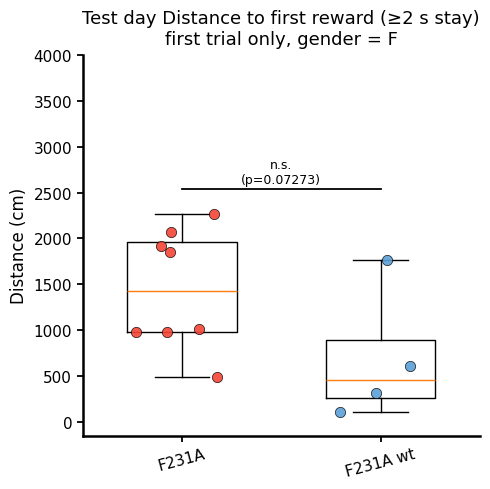


=== Test-day boxplot: CIPL ===
  F231A (F231A): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A wt (F231A_wt): n = 4, animals = [np.str_('BD (F)'), np.str_('BO (F)'), np.str_('F1 (F)'), np.str_('F2 (F)')]

Mann–Whitney U tests:
  F231A vs F231A wt: n=8 vs 4, mean=1412.27 vs 655.25, median=1417.52 vs 420.79, U=27.0, rank-biserial=0.688, p=0.07273


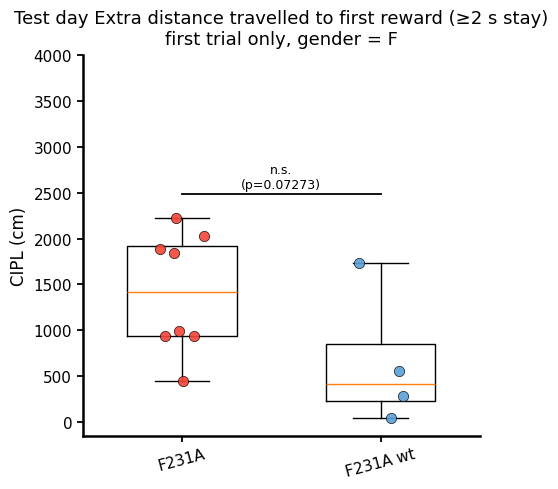


=== Test-day boxplot: path_eff ===
  F231A (F231A): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A wt (F231A_wt): n = 4, animals = [np.str_('BD (F)'), np.str_('BO (F)'), np.str_('F1 (F)'), np.str_('F2 (F)')]

Mann–Whitney U tests:
  F231A vs F231A wt: n=8 vs 4, mean=3.06 vs 19.49, median=1.92 vs 8.39, U=7.0, rank-biserial=-0.562, p=0.15354


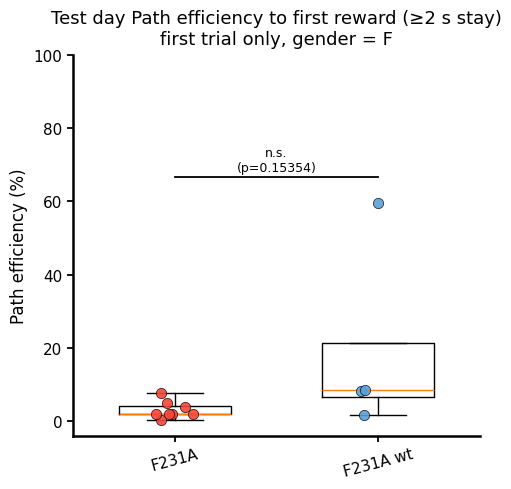


=== Learning-days 1-5 average boxplot: CIPL ===
  F231A (F231A): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A wt (F231A_wt): n = 4, animals = [np.str_('BD (F)'), np.str_('BO (F)'), np.str_('F1 (F)'), np.str_('F2 (F)')]

Mann–Whitney U tests:
  F231A vs F231A wt: n=8 vs 4, mean=539.19 vs 351.12, median=481.23 vs 367.26, U=24.0, rank-biserial=0.500, p=0.21414


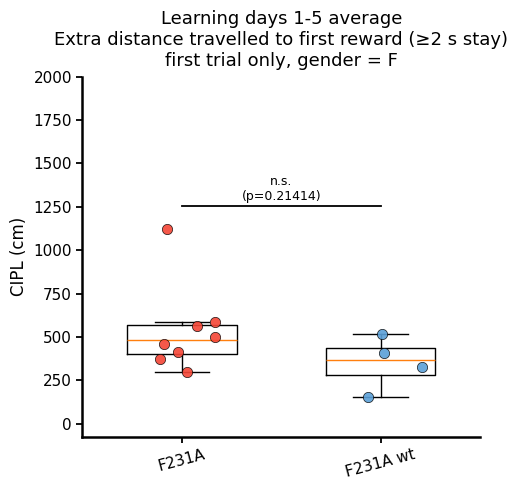


=== Learning-days 1-5 average boxplot: path_eff ===
  F231A (F231A): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A wt (F231A_wt): n = 4, animals = [np.str_('BD (F)'), np.str_('BO (F)'), np.str_('F1 (F)'), np.str_('F2 (F)')]

Mann–Whitney U tests:
  F231A vs F231A wt: n=8 vs 4, mean=15.49 vs 21.35, median=10.48 vs 18.09, U=11.0, rank-biserial=-0.312, p=0.46061


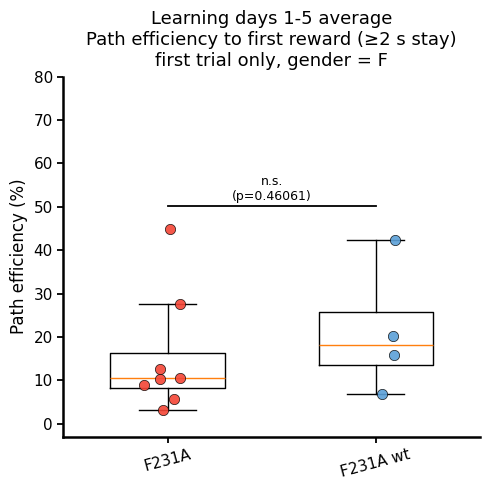

In [288]:
# ============================================================
# Distance / CIPL / Path efficiency
#
# Adds pooled group:
#   'Control' = eYFP_ChR2 + NAc_control + CA1_control
#
# New option:
#   DAY_VALUE_MODE = 'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   DAY_VALUE_MODE = 'first_trial'
#       learning days = first trial only from each day
#       test day      = first test trial only
#
# Gender option:
#   GENDER_FILTER = None      -> include all animals
#   GENDER_FILTER = 'F'       -> females only
#   GENDER_FILTER = 'M'       -> males only
#   GENDER_FILTER = ['F','M'] -> explicit both
#
# Stay tag:
#   automatically follows REQUIRE_STAY_2S if it exists.
#   If REQUIRE_STAY_2S = True  -> title shows ≥2 s stay
#   If REQUIRE_STAY_2S = False -> title shows all entries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
# GROUPS = ['ChR2', 'ChR2_short','eYFP_ChR2']
# GROUPS = ['eYFP_ChR2', 'CA1_control','NAc_control']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['CA1', 'CA3', 'Control']
# GROUPS = ['ChR2','CA1','CA3','Control']
GROUPS = ['F231A', 'F231A_wt']

# Gender filter
GENDER_FILTER = 'F'
# GENDER_FILTER = 'F'
# GENDER_FILTER = 'M'
# GENDER_FILTER = ['F', 'M']

# How to compute each animal × day value
DAY_VALUE_MODE = 'first_trial'
# DAY_VALUE_MODE = 'daily_mean'

# These original genotypes will be pooled into genotype == 'Control'
# eYFP_ChR2 = VTA control
POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A wt',
}

# ------------------------------------------------------------
# Stay-tag logic
# ------------------------------------------------------------
REQUIRE_STAY_2S_FOR_LABEL = globals().get('REQUIRE_STAY_2S', False)
MIN_DUR_MS_FOR_LABEL = globals().get('MIN_DUR_MS', 2000)

STAY_TAG = (
    f" (≥{MIN_DUR_MS_FOR_LABEL / 1000:g} s stay)"
    if REQUIRE_STAY_2S_FOR_LABEL
    else " (all entries)"
)

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = True
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False
SHOW_ANIMAL_IDS = False
JITTER = 0.10
DOT_SIZE = 55
P_DECIMALS = 5

RUN_LINE_PLOTS = True
RUN_TEST_BOXPLOTS = True
RUN_LEARNING_AVG_BOXPLOTS = True

METRICS_TO_PLOT = ['dist_to_trigger', 'CIPL', 'path_eff']
LEARNING_AVG_BOXPLOT_METRICS = ['CIPL', 'path_eff']

METRIC_LABEL = {
    'dist_to_trigger': 'Distance (cm)',
    'CIPL': 'CIPL (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'dist_to_trigger': 'Distance to first reward',
    'CIPL': 'Extra distance travelled to first reward',
    'path_eff': 'Path efficiency to first reward',
}

YMAX_BY_METRIC = {
    'dist_to_trigger': None,
    'CIPL': None,
    'path_eff': None,
}

YMIN = None
Y_BOTTOM_PAD_FRAC = 0.06
BOX_Y_ZERO_PAD_FRAC = 0.04

# Boxplot options
COMPARISONS = 'all'
# COMPARISONS = [('ChR2', 'Control'), ('NAc', 'Control')]

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")

# ---------------------------------------------------------------------
# 1. Base filter and assign plot_day
# ---------------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
] + METRICS_TO_PLOT

if GENDER_FILTER is not None:
    needed_cols.append('gender')

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

# If GROUPS contains 'Control', include its original component groups.
groups_to_load = []
for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(groups_to_load)) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# ------------------------------------------------------------
# Apply gender filter
# ------------------------------------------------------------
if GENDER_FILTER is not None:
    if isinstance(GENDER_FILTER, str):
        gender_values = [GENDER_FILTER]
    else:
        gender_values = list(GENDER_FILTER)

    gender_values = [str(g).upper() for g in gender_values]

    meta_LT = meta_LT[
        meta_LT['gender'].astype(str).str.upper().isin(gender_values)
    ].copy()

# Store original genotype before pooling
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool VTA control + NAc_control + CA1_control into one displayed/statistical group: Control
if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ---------------------------------------------------------------------
# 1b. Add trial_in_day, needed for DAY_VALUE_MODE = 'first_trial'
# ---------------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session',
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()

# ---------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals.
    Example:
      N8 (NAc_control)
      X3 (CA1_control)
      A1 (eYFP_ChR2)
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    gender_txt = ""
    if 'gender' in ms.columns and ms['gender'].notna().any():
        gender_txt = f", {str(ms['gender'].dropna().iloc[0])}"

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original}{gender_txt})'

    if gender_txt != "":
        return f'{animal_id} ({gender_txt.replace(", ", "")})'

    return animal_id


def get_day_value(ms, day, value_col):
    """
    Returns one value for one animal on one plot_day.

    DAY_VALUE_MODE:
      'daily_mean'  -> mean across all available trials in that day
      'first_trial' -> trial_in_day == 1 only
    """
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna())
    ].copy()

    if len(md) == 0:
        return np.nan

    # mean per trial first, in case duplicate rows exist for same trial
    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan
        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def get_test_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()
        value = get_day_value(ms, 6, value_col)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'value': value,
            'animal_id': get_animal_label(ms, sub)
        })

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def get_learning_avg_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['plot_day'].isin([1, 2, 3, 4, 5])) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()

        vals_day = np.array(
            [get_day_value(ms, d, value_col) for d in [1, 2, 3, 4, 5]],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals_day)):
            continue

        if np.all(np.isnan(vals_day)):
            continue

        value = np.nanmean(vals_day)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'animal_id': get_animal_label(ms, sub),
            'value': value
        })

    if len(rows) == 0:
        return np.array([]), np.array([]), np.array([])

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def style_nature(ax):
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)


def apply_y_axis(ax, ymax_candidates, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        ymax = manual_ymax
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return stat, p


def get_comparisons():
    if COMPARISONS == 'all':
        comparisons = []
        for i in range(len(GROUPS)):
            for j in range(i + 1, len(GROUPS)):
                comparisons.append((GROUPS[i], GROUPS[j]))
        return comparisons
    return COMPARISONS


def gender_label_for_title():
    if GENDER_FILTER is None:
        return "all genders"

    if isinstance(GENDER_FILTER, str):
        return f"gender = {GENDER_FILTER}"

    return "gender = " + "/".join([str(g) for g in GENDER_FILTER])


# ---------------------------------------------------------------------
# 3. Line plot helper
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col):
    ylabel = METRIC_LABEL.get(value_col, value_col)
    title_base = METRIC_TITLE.get(value_col, value_col)

    group_data = {}

    print(f"\n=== Line plot: {value_col} ===")

    for g in GROUPS:
        meta_g = meta_LT[meta_LT['genotype'] == g].copy()
        mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, value_col)

        group_data[g] = {
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"{DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

    fig, ax = plt.subplots(figsize=(8, 5.2))

    ymax_candidates = []

    for g in GROUPS:
        mat = group_data[g]['mat']
        subs = group_data[g]['subs']

        if mat is None or len(subs) == 0:
            continue

        col = get_genotype_color(g)
        label = DISPLAY_NAME.get(g, g)

        if PLOT_INDIVIDUAL:
            for row in mat:
                ax.plot(
                    x_vals,
                    row,
                    '-',
                    color=col,
                    alpha=0.12,
                    linewidth=1.0,
                    label='_nolegend_',
                    zorder=1
                )

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=col,
                alpha=0.18,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if SHOW_SEM_ERRORBARS:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        ymax_candidates.append(np.nanmax(mean_ + sem_))

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "First trial only"
    else:
        day_value_tag = "Daily mean"

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{title_base}{STAY_TAG}\nLearning Days + Test, {day_value_tag}, {gender_label_for_title()}',
        fontsize=15,
        pad=8
    )

    style_nature(ax)
    apply_y_axis(ax, ymax_candidates, value_col)

    ax.legend(
        frameon=False,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()


# ---------------------------------------------------------------------
# 4. Boxplot helper
# ---------------------------------------------------------------------
def plot_boxplot(metric_col, boxplot_mode):
    ylabel = METRIC_LABEL.get(metric_col, metric_col)
    title_base = METRIC_TITLE.get(metric_col, metric_col)

    group_vals = {}
    group_subs = {}
    group_ids = {}

    if boxplot_mode == 'test':
        print(f"\n=== Test-day boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_test_group_vals(meta_test, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    elif boxplot_mode == 'learning_mean':
        print(f"\n=== Learning-days 1-5 average boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_learning_avg_group_vals(meta_LT, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    else:
        raise ValueError("boxplot_mode must be 'test' or 'learning_mean'")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_vals[g])}, animals = {list(group_ids[g])}"
        )

    data = [group_vals[g] for g in GROUPS]
    positions = np.arange(len(GROUPS))

    fig, ax = plt.subplots(figsize=(max(5, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = group_vals[g]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(g),
            edgecolor='k',
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_ids[g]):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # comparisons
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in get_comparisons():
        if g1 not in GROUPS or g2 not in GROUPS:
            print(f"Skipping {g1} vs {g2}: group not in GROUPS")
            continue

        vals1 = group_vals[g1]
        vals2 = group_vals[g2]

        stat, p = mwu(vals1, vals2)

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.2f} vs {np.nanmean(vals2):.2f}, "
                f"median={np.nanmedian(vals1):.2f} vs {np.nanmedian(vals2):.2f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )
        else:
            print(f"  {g1} vs {g2}: p = NaN")

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    # significance lines
    nonempty_data = [v for v in data if len(v) > 0]

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        current_y = ymax + 0.12 * yrng
        y_step = 0.28 * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2

            ax.plot(
                [positions[x1], positions[x2]],
                [current_y, current_y],
                color='k',
                lw=1.3
            )

            ax.text(
                x_mid,
                current_y + 0.015 * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        ymax_box = current_y + 0.25 * yrng

        if YMIN is not None:
            ymin = YMIN
        else:
            ymin = -BOX_Y_ZERO_PAD_FRAC * ymax_box

        ax.set_ylim(ymin, ymax_box)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "first trial only"
    else:
        day_value_tag = "daily mean"

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)

    if boxplot_mode == 'test':
        ax.set_title(
            f"Test day {title_base}{STAY_TAG}\n{day_value_tag}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )
    else:
        ax.set_title(
            f"Learning days 1-5 average\n{title_base}{STAY_TAG}\n{day_value_tag}, {gender_label_for_title()}",
            fontsize=13,
            pad=8
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.tick_params(axis='y', labelsize=11)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 5. Run plots
# ---------------------------------------------------------------------
print("\nGroups used for plotting/stats:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
print("Day value mode:", DAY_VALUE_MODE)
print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Gender filter:", GENDER_FILTER if GENDER_FILTER is not None else "all")
print("Stay tag:", STAY_TAG)

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nAnimals after all filters:")
if len(meta_LT) > 0:
    cols_to_print = ['sub']
    if 'id' in meta_LT.columns:
        cols_to_print.append('id')
    if 'gender' in meta_LT.columns:
        cols_to_print.append('gender')
    cols_to_print.append('genotype')

    print(
        meta_LT[cols_to_print]
        .drop_duplicates()
        .sort_values(cols_to_print)
        .reset_index(drop=True)
    )
else:
    print("No rows left after filtering.")

if RUN_LINE_PLOTS:
    for metric in METRICS_TO_PLOT:
        plot_metric_for_groups(meta_LT, metric)

if RUN_TEST_BOXPLOTS:
    for metric in METRICS_TO_PLOT:
        plot_boxplot(metric, boxplot_mode='test')

if RUN_LEARNING_AVG_BOXPLOTS:
    for metric in LEARNING_AVG_BOXPLOT_METRICS:
        plot_boxplot(metric, boxplot_mode='learning_mean')

Stay tag used: all entries
This plotting code uses the metric columns already present in metadata.
To switch between all entries vs ≥2 s stay, rerun your metric-computation code with REQUIRE_STAY_2S True/False, then rerun this plotting code.


############################################################
RUNNING METRIC: CIPL
############################################################
Using metric: CIPL
Stay tag: all entries
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10, CIPL
Trial-level rows included: n rows = 24
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13 

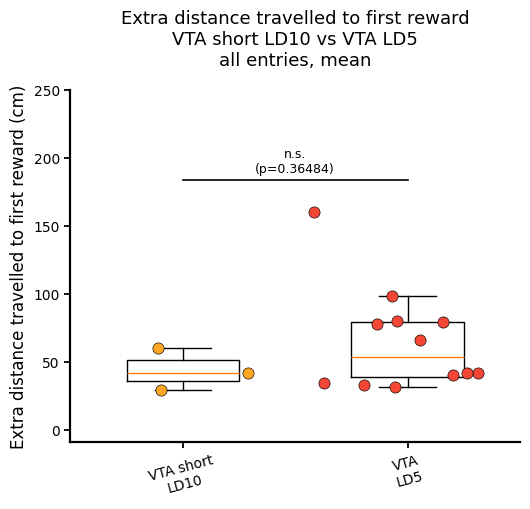


Extra distance travelled to first reward
VTA short next test vs VTA test
Metric: CIPL
Per-animal values used for statistics:

Left group:
   sub  id       value  n_trials ses_list trial_type_day_list trial_type_list  \
0   13  AI  246.527005         1     [14]                 [1]             [T]   
1   14  AJ  263.937336         1     [14]                 [1]             [T]   
2   15  AL    1.887497         1     [14]                 [1]             [T]   

  trial_in_day_list  
0               [1]  
1               [1]  
2               [1]  

Right group:
    sub  id       value  n_trials ses_list trial_type_day_list  \
0     1   A   94.368752         1      [9]                 [1]   
1     3   C  118.847043         1      [9]                 [1]   
2     4   D    1.158615         1      [9]                 [1]   
3     6  AB   99.889708         1      [9]                 [1]   
4     7  AC   86.235965         1      [9]                 [1]   
5     8  AD   16.194685         1     

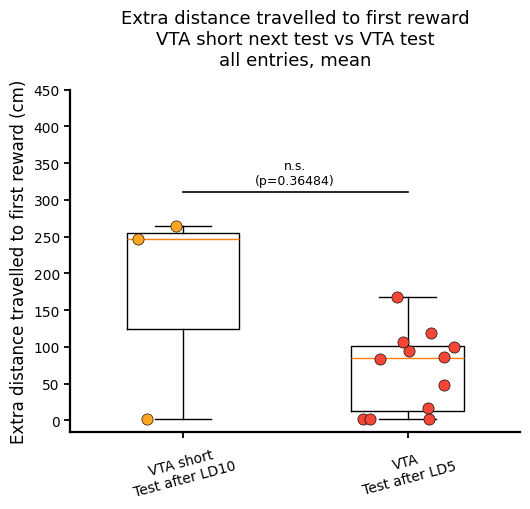



############################################################
RUNNING METRIC: path_eff
############################################################
Using metric: path_eff
Stay tag: all entries
Trial summary mode: mean
Trial column used: inferred from sub/ses/trial_id order
ChR2_short IDs requested: ['AI', 'AJ', 'AL']

Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10, path_eff
Trial-level rows included: n rows = 22
Animals included: n = 3
    sub  id    genotype  ses trial_type  trial_type_day  trial_in_day  \
0    13  AI  ChR2_short   13          L              10             1   
1    13  AI  ChR2_short   13          L              10             2   
2    13  AI  ChR2_short   13          L              10             3   
3    13  AI  ChR2_short   13          L              10             4   
4    13  AI  ChR2_short   13          L              10             5   
5    13  AI  ChR2_short   13          L              10             6   
6    13  AI  ChR2_short   13          L 

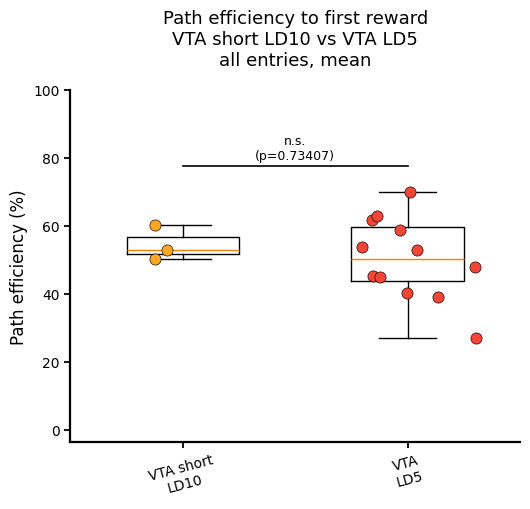


Path efficiency to first reward
VTA short next test vs VTA test
Metric: path_eff
Per-animal values used for statistics:

Left group:
   sub  id      value  n_trials ses_list trial_type_day_list trial_type_list  \
0   13  AI   5.920031         1     [14]                 [1]             [T]   
1   14  AJ   7.323923         1     [14]                 [1]             [T]   
2   15  AL  94.498535         1     [14]                 [1]             [T]   

  trial_in_day_list  
0               [1]  
1               [1]  
2               [1]  

Right group:
    sub  id      value  n_trials ses_list trial_type_day_list trial_type_list  \
0     1   A  16.402615         1      [9]                 [1]             [T]   
1     3   C  33.220664         1      [9]                 [1]             [T]   
2     4   D  96.162462         1      [9]                 [1]             [T]   
3     6  AB  29.019842         1      [9]                 [1]             [T]   
4     7  AC  12.404585         1      

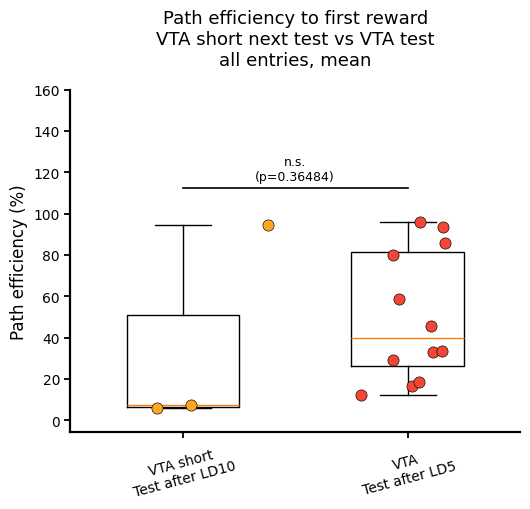

In [322]:
# ============================================================
# Compare CIPL / path efficiency:
#
# ChR2_short animals AI/AJ/AL:
#   final learning day = learning day 10
#   trial_type_day == 10, trial_type == 'L'
#
# vs
#
# ChR2 animals:
#   final learning day = learning day 5
#   trial_type_day == 5, trial_type == 'L'
#
# Also compare:
#   ChR2_short next test day after learning day 10
#   vs
#   ChR2 first test day after learning day 5
#
# Produces boxplots for:
#   1) CIPL:          ChR2_short LD10 vs ChR2 LD5
#   2) CIPL:          ChR2_short next test vs ChR2 test
#   3) path_eff:      ChR2_short LD10 vs ChR2 LD5
#   4) path_eff:      ChR2_short next test vs ChR2 test
#
# Stay tag:
#   follows REQUIRE_STAY_2S and MIN_DUR_MS from the metric-computation code.
#
# Prints:
#   - exact trial rows included
#   - animal-level values used for stats
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================

CHR2_SHORT_IDS = ['AI', 'AJ', 'AL']

CH_R2_GENOTYPE = 'ChR2'
CH_R2_SHORT_GENOTYPE = 'ChR2_short'

METRICS_TO_COMPARE = ['CIPL', 'path_eff']

METRIC_LABEL = {
    'CIPL': 'Extra distance travelled to first reward (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'CIPL': 'Extra distance travelled to first reward',
    'path_eff': 'Path efficiency to first reward',
}

EXCLUDE_ID = ['AN']       # optional
EXCLUDE_SUBS = []         # optional

REQUIRE_USABLE = True

# How to summarize multiple trials from the same animal/session/day
# 'mean' = average all included trials per animal
# 'first_trial' = use trial_in_day == 1 only
TRIAL_SUMMARY_MODE = 'mean'
# TRIAL_SUMMARY_MODE = 'first_trial'

# Plot options
SHOW_ANIMAL_IDS = False
JITTER = 0.18
DOT_SIZE = 65
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.18
P_TEXT_OFFSET_FRAC = 0.025
P_TOP_PAD_FRAC = 0.35

# y-axis
YMIN_BY_METRIC = {
    'CIPL': None,
    'path_eff': None,
}

YMAX_BY_METRIC = {
    'CIPL': None,
    'path_eff': None,
}

Y_BOTTOM_PAD_FRAC = 0.04
Y_TICK_STEP_BY_METRIC = {
    'CIPL': None,
    'path_eff': None,
}

np.random.seed(1)

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

# ------------------------------------------------------------
# Stay-tag logic
# ------------------------------------------------------------
REQUIRE_STAY_2S_FOR_LABEL = globals().get('REQUIRE_STAY_2S', False)
MIN_DUR_MS_FOR_LABEL = globals().get('MIN_DUR_MS', 2000)

STAY_TAG = (
    f"≥{MIN_DUR_MS_FOR_LABEL / 1000:g} s stay"
    if REQUIRE_STAY_2S_FOR_LABEL
    else "all entries"
)

# ============================================================
# Helper functions
# ============================================================

def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def style_nature(ax, linewidth=1.6):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def get_animal_label(ms, sub):
    if 'id' in ms.columns and ms['id'].notna().any():
        return str(ms['id'].dropna().iloc[0])
    return str(sub)


def add_trial_in_day(meta_df):
    """
    Create trial_in_day = 1..8.
    Prefer an existing trial column if present.
    Otherwise infer from sorted sub/ses/trial_id order.
    """
    meta_df = meta_df.copy()

    candidate_cols = [
        'trial_in_day',
        'trial_num',
        'trial_number',
        'trial',
        'trial_idx',
        'trial_index',
        'trial_in_session',
        'trial_id_in_session',
    ]

    trial_col = next((c for c in candidate_cols if c in meta_df.columns), None)

    if trial_col is not None:
        meta_df['trial_in_day'] = meta_df[trial_col].astype(int)
    else:
        sort_cols = ['sub', 'ses']
        if 'trial_id' in meta_df.columns:
            sort_cols.append('trial_id')

        meta_df = meta_df.sort_values(sort_cols).copy()
        meta_df['trial_in_day'] = meta_df.groupby(['sub', 'ses']).cumcount() + 1

    return meta_df, trial_col


def print_trial_rows(label, meta_df, value_col):
    """
    Print exact trial-level rows used before per-animal averaging.
    """
    print("\n============================================================")
    print(label)
    print(f"Trial-level rows included: n rows = {len(meta_df)}")
    print(f"Animals included: n = {meta_df['sub'].nunique() if len(meta_df) > 0 else 0}")

    if len(meta_df) == 0:
        print("No rows.")
        return

    cols = [
        'sub',
        'id',
        'genotype',
        'ses',
        'trial_type',
        'trial_type_day',
        'trial_in_day',
    ]

    optional_cols = [
        'trial_id',
        'date',
        'usable',
        'short_duration',
        'first_choice_trigger',
        'L_actual',
        'L_shortest',
        'CIPL',
        'path_eff',
        value_col,
    ]

    cols_to_print = []
    for c in cols + optional_cols:
        if c in meta_df.columns and c not in cols_to_print:
            cols_to_print.append(c)

    out = meta_df[cols_to_print].copy()

    sort_cols = [c for c in ['id', 'sub', 'ses', 'trial_in_day'] if c in out.columns]

    print(
        out
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )


def per_animal_value_from_trials(meta_df, value_col):
    """
    Converts trial-level rows into one value per animal.

    TRIAL_SUMMARY_MODE:
      'mean'        -> average across all included trials per animal
      'first_trial' -> only trial_in_day == 1
    """
    rows = []

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub].copy()

        if TRIAL_SUMMARY_MODE == 'first_trial':
            ms_use = ms[ms['trial_in_day'] == 1].copy()
        elif TRIAL_SUMMARY_MODE == 'mean':
            ms_use = ms.copy()
        else:
            raise ValueError("TRIAL_SUMMARY_MODE must be 'mean' or 'first_trial'")

        vals = ms_use[value_col].values.astype(float)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': get_animal_label(ms, sub),
            'value': float(np.nanmean(vals)),
            'n_trials': len(vals),
            'ses_list': sorted(ms_use['ses'].dropna().unique().tolist()) if 'ses' in ms_use.columns else [],
            'trial_type_day_list': sorted(ms_use['trial_type_day'].dropna().unique().tolist()) if 'trial_type_day' in ms_use.columns else [],
            'trial_type_list': sorted(ms_use['trial_type'].dropna().unique().tolist()) if 'trial_type' in ms_use.columns else [],
            'trial_in_day_list': sorted(ms_use['trial_in_day'].dropna().unique().tolist()) if 'trial_in_day' in ms_use.columns else [],
        })

    return pd.DataFrame(rows)


def apply_box_y_axis(ax, y_top, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)
    manual_ymin = YMIN_BY_METRIC.get(value_col, None)
    y_tick_step = Y_TICK_STEP_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        y_top = manual_ymax
    else:
        if not np.isfinite(y_top) or y_top <= 0:
            y_top = 1.0

    if manual_ymin is not None:
        y_bottom = manual_ymin
    else:
        y_bottom = -Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if y_tick_step is not None:
        yticks = np.arange(0, y_top + y_tick_step, y_tick_step)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def plot_two_group_boxplot(
    df_left,
    df_right,
    left_label,
    right_label,
    title,
    value_col,
):
    """
    Boxplot + individual dots + Mann–Whitney U test.
    df_left / df_right should contain columns:
      sub, id, value, n_trials
    """
    vals_left = df_left['value'].values.astype(float) if len(df_left) > 0 else np.array([])
    vals_right = df_right['value'].values.astype(float) if len(df_right) > 0 else np.array([])

    vals_groups = [vals_left, vals_right]
    positions = np.array([0, 1])

    print("\n============================================================")
    print(title)
    print(f"Metric: {value_col}")
    print("Per-animal values used for statistics:")

    print("\nLeft group:")
    print(df_left)

    print("\nRight group:")
    print(df_right)

    if len(vals_left) > 0 and len(vals_right) > 0:
        stat, p = mannwhitneyu(vals_left, vals_right, alternative='two-sided')
        rank_biserial = (2 * stat) / (len(vals_left) * len(vals_right)) - 1

        print("\nMann–Whitney U test:")
        print(
            f"  {left_label} vs {right_label}: "
            f"n={len(vals_left)} vs {len(vals_right)}, "
            f"mean={np.nanmean(vals_left):.3f} vs {np.nanmean(vals_right):.3f}, "
            f"median={np.nanmedian(vals_left):.3f} vs {np.nanmedian(vals_right):.3f}, "
            f"U={stat:.1f}, "
            f"rank-biserial={rank_biserial:.3f}, "
            f"p={format_p(p, P_DECIMALS)}"
        )
    else:
        stat, p = np.nan, np.nan
        print("\nMann–Whitney U test: skipped because one group has no data.")

    fig, ax = plt.subplots(figsize=(5.4, 5.2))

    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------
    ax.boxplot(
        vals_groups,
        positions=positions,
        widths=0.5,
        patch_artist=False,
        showfliers=False
    )

    # --------------------------------------------------------
    # Individual dots
    # --------------------------------------------------------
    group_keys = [CH_R2_SHORT_GENOTYPE, CH_R2_GENOTYPE]

    for i, (df_g, vals, gkey) in enumerate(zip([df_left, df_right], vals_groups, group_keys)):
        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(gkey),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(gkey),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Significance line
    # --------------------------------------------------------
    nonempty = [v for v in vals_groups if len(v) > 0]

    if len(nonempty) > 0:
        all_vals = np.concatenate(nonempty)
        ymax = np.nanmax(all_vals)
        ymin = np.nanmin(all_vals)

        yrng = ymax - ymin
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax), 1.0)

        y_line = ymax + P_LINE_START_FRAC * yrng
        y_text = y_line + P_TEXT_OFFSET_FRAC * yrng

        if np.isfinite(p):
            ax.plot(
                [positions[0], positions[1]],
                [y_line, y_line],
                color='black',
                linewidth=1.2,
                zorder=5,
                clip_on=False
            )

            ax.text(
                np.mean(positions),
                y_text,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9,
                zorder=6,
                clip_on=False
            )

        y_top_for_axis = y_line + P_TOP_PAD_FRAC * yrng
    else:
        y_top_for_axis = 1.0

    # --------------------------------------------------------
    # Axes / labels / style
    # --------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [left_label, right_label],
        fontsize=10,
        rotation=15
    )

    ax.set_ylabel(METRIC_LABEL.get(value_col, value_col), fontsize=12)

    ax.set_title(
        f'{title}\n{STAY_TAG}, {TRIAL_SUMMARY_MODE}',
        fontsize=13,
        pad=18
    )

    apply_box_y_axis(ax, y_top_for_axis, value_col)
    style_nature(ax, linewidth=1.6)

    plt.tight_layout()
    plt.show()


# ============================================================
# Main function for one metric
# ============================================================

def run_metric_comparison(value_col):
    print("\n\n############################################################")
    print(f"RUNNING METRIC: {value_col}")
    print("############################################################")

    needed_cols = [
        'usable',
        'genotype',
        'trial_type',
        'trial_type_day',
        'ses',
        'sub',
        value_col,
    ]

    missing_cols = [c for c in needed_cols if c not in metadata.columns]
    if len(missing_cols) > 0:
        raise KeyError(f"Missing columns in metadata: {missing_cols}")

    meta = metadata.copy()

    if REQUIRE_USABLE:
        meta = meta[meta['usable'] == 1].copy()

    meta = meta[
        meta['genotype'].isin([CH_R2_GENOTYPE, CH_R2_SHORT_GENOTYPE]) &
        meta['trial_type'].isin(['L', 'T']) &
        meta[value_col].notna() &
        np.isfinite(meta[value_col])
    ].copy()

    if len(EXCLUDE_ID) > 0 and 'id' in meta.columns:
        meta = meta[
            ~meta['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
        ].copy()

    if len(EXCLUDE_SUBS) > 0:
        meta = meta[
            ~meta['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
        ].copy()

    meta, trial_col = add_trial_in_day(meta)

    print("Using metric:", value_col)
    print("Stay tag:", STAY_TAG)
    print("Trial summary mode:", TRIAL_SUMMARY_MODE)
    print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses/trial_id order")
    print("ChR2_short IDs requested:", CHR2_SHORT_IDS)

    # ========================================================
    # Comparison 1:
    # ChR2_short LD10 vs ChR2 LD5
    # ========================================================

    short_ld10_trials = meta[
        (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
        (meta['id'].astype(str).isin(CHR2_SHORT_IDS)) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 10)
    ].copy()

    chr2_ld5_trials = meta[
        (meta['genotype'] == CH_R2_GENOTYPE) &
        (meta['trial_type'] == 'L') &
        (meta['trial_type_day'] == 5)
    ].copy()

    print_trial_rows(
        label=f"Comparison 1 LEFT: ChR2_short AI/AJ/AL learning day 10, {value_col}",
        meta_df=short_ld10_trials,
        value_col=value_col
    )

    print_trial_rows(
        label=f"Comparison 1 RIGHT: ChR2 learning day 5, {value_col}",
        meta_df=chr2_ld5_trials,
        value_col=value_col
    )

    short_ld10_animal = per_animal_value_from_trials(short_ld10_trials, value_col)
    chr2_ld5_animal = per_animal_value_from_trials(chr2_ld5_trials, value_col)

    # ========================================================
    # Comparison 2:
    # ChR2_short next test after LD10 vs ChR2 first test after LD5
    # ========================================================

    # --------------------------------------------------------
    # ChR2_short next test:
    # for each animal, find last ses among LD10 rows;
    # next test session = last_ld10_ses + 1
    # --------------------------------------------------------
    short_next_test_list = []

    for animal_id in CHR2_SHORT_IDS:
        m_animal_ld10 = short_ld10_trials[
            short_ld10_trials['id'].astype(str) == str(animal_id)
        ].copy()

        if len(m_animal_ld10) == 0:
            print(f"WARNING: no LD10 rows found for {animal_id}; cannot find next test.")
            continue

        last_ld10_ses = m_animal_ld10['ses'].max()
        next_test_ses = last_ld10_ses + 1

        m_next_test = meta[
            (meta['genotype'] == CH_R2_SHORT_GENOTYPE) &
            (meta['id'].astype(str) == str(animal_id)) &
            (meta['trial_type'] == 'T') &
            (meta['ses'] == next_test_ses)
        ].copy()

        if len(m_next_test) == 0:
            print(
                f"WARNING: no next test rows found for {animal_id}: "
                f"expected ses = {next_test_ses}"
            )
            continue

        short_next_test_list.append(m_next_test)

    if len(short_next_test_list) > 0:
        short_next_test_trials = pd.concat(short_next_test_list, ignore_index=False)
    else:
        short_next_test_trials = meta.iloc[0:0].copy()

    # --------------------------------------------------------
    # ChR2 first test after learning day 5:
    # computed separately for each ChR2 animal.
    # --------------------------------------------------------
    chr2_test_list = []

    meta_chr2 = meta[meta['genotype'] == CH_R2_GENOTYPE].copy()

    for sub in meta_chr2['sub'].unique():
        ms = meta_chr2[meta_chr2['sub'] == sub].copy()

        m_ld5 = ms[
            (ms['trial_type'] == 'L') &
            (ms['trial_type_day'] == 5)
        ].copy()

        if len(m_ld5) == 0:
            continue

        last_ld5_ses = m_ld5['ses'].max()

        m_test_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_ld5_ses)
        ].copy()

        if len(m_test_after) == 0:
            continue

        first_test_ses = m_test_after['ses'].min()

        m_first_test = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] == first_test_ses)
        ].copy()

        if len(m_first_test) > 0:
            chr2_test_list.append(m_first_test)

    if len(chr2_test_list) > 0:
        chr2_test_trials = pd.concat(chr2_test_list, ignore_index=False)
    else:
        chr2_test_trials = meta.iloc[0:0].copy()

    print_trial_rows(
        label=f"Comparison 2 LEFT: ChR2_short AI/AJ/AL next test after learning day 10, {value_col}",
        meta_df=short_next_test_trials,
        value_col=value_col
    )

    print_trial_rows(
        label=f"Comparison 2 RIGHT: ChR2 first test after learning day 5, {value_col}",
        meta_df=chr2_test_trials,
        value_col=value_col
    )

    short_next_test_animal = per_animal_value_from_trials(short_next_test_trials, value_col)
    chr2_test_animal = per_animal_value_from_trials(chr2_test_trials, value_col)

    # ========================================================
    # Plot 1: final learning day comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_ld10_animal,
        df_right=chr2_ld5_animal,
        left_label='VTA short\nLD10',
        right_label='VTA\nLD5',
        title=f'{METRIC_TITLE.get(value_col, value_col)}\nVTA short LD10 vs VTA LD5',
        value_col=value_col,
    )

    # ========================================================
    # Plot 2: test comparison
    # ========================================================

    plot_two_group_boxplot(
        df_left=short_next_test_animal,
        df_right=chr2_test_animal,
        left_label='VTA short\nTest after LD10',
        right_label='VTA\nTest after LD5',
        title=f'{METRIC_TITLE.get(value_col, value_col)}\nVTA short next test vs VTA test',
        value_col=value_col,
    )


# ============================================================
# Run CIPL and path efficiency
# ============================================================

print("Stay tag used:", STAY_TAG)
print("This plotting code uses the metric columns already present in metadata.")
print("To switch between all entries vs ≥2 s stay, rerun your metric-computation code with REQUIRE_STAY_2S True/False, then rerun this plotting code.")

for metric in METRICS_TO_COMPARE:
    run_metric_comparison(metric)


Groups used for plotting/stats: ['F', 'M']
Group by gender: True
Genotype compared by gender: F231A
Day value mode: daily_mean
Trial column used: inferred from sub/ses order
Stay tag:  (≥2 s stay)

=== Line plot: dist_to_trigger ===
F231A female (F): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A male (M): n = 6, ids = ['BB (M)', 'BL (M)', 'BM (M)', 'BN (M)', 'F7 (M)', 'F8 (M)']


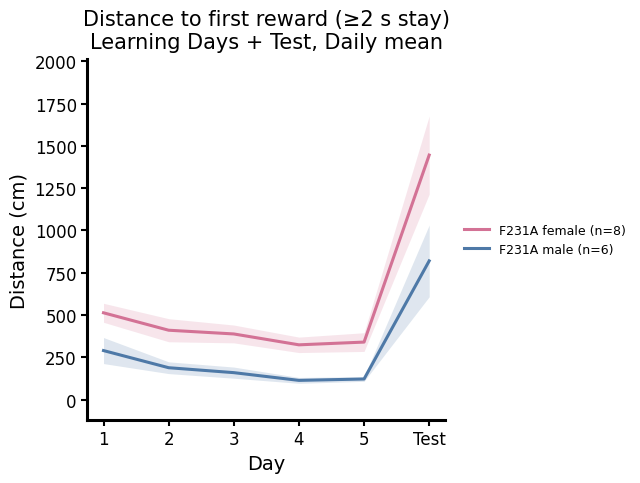


=== Line plot: CIPL ===
F231A female (F): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A male (M): n = 6, ids = ['BB (M)', 'BL (M)', 'BM (M)', 'BN (M)', 'F7 (M)', 'F8 (M)']


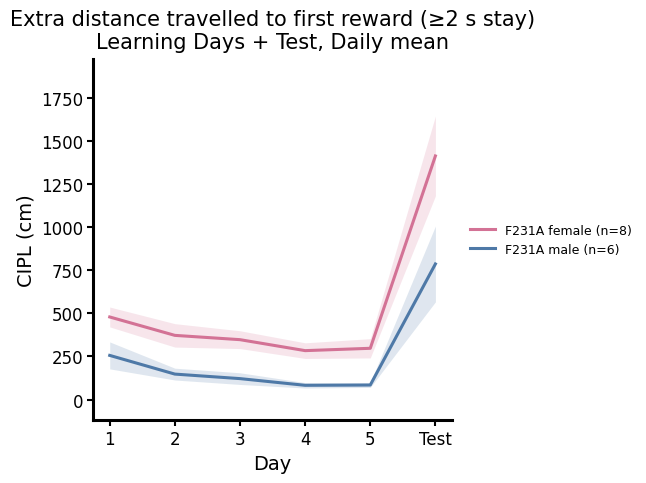


=== Line plot: path_eff ===
F231A female (F): n = 8, ids = ['BE (F)', 'BF (F)', 'BG (F)', 'BH (F)', 'BI (F)', 'BR (F)', 'F3 (F)', 'F4 (F)']
F231A male (M): n = 6, ids = ['BB (M)', 'BL (M)', 'BM (M)', 'BN (M)', 'F7 (M)', 'F8 (M)']


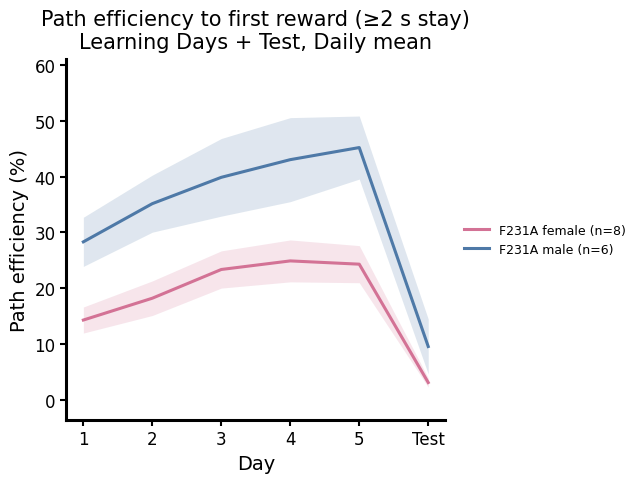


=== Test-day boxplot: dist_to_trigger ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=1445.82 vs 820.22, median=1431.05 vs 747.96, U=38.0, rank-biserial=0.583, p=0.08125


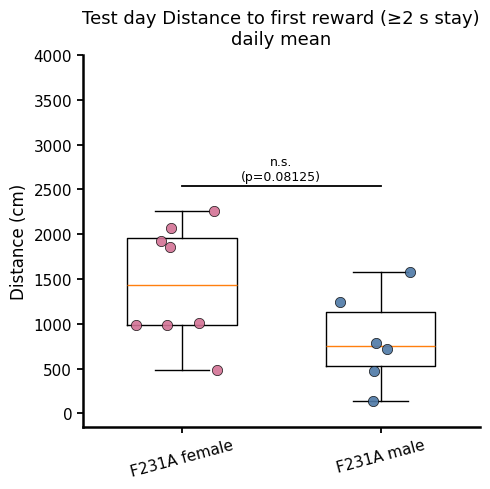


=== Test-day boxplot: CIPL ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=1412.27 vs 786.29, median=1417.52 vs 699.90, U=38.0, rank-biserial=0.583, p=0.08125


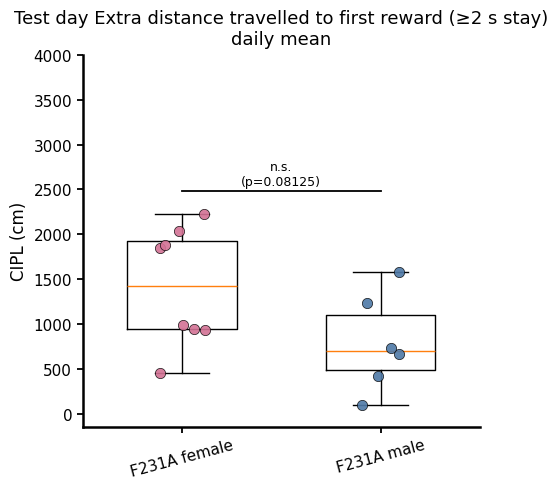


=== Test-day boxplot: path_eff ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=3.06 vs 9.52, median=1.92 vs 6.43, U=17.0, rank-biserial=-0.292, p=0.41359


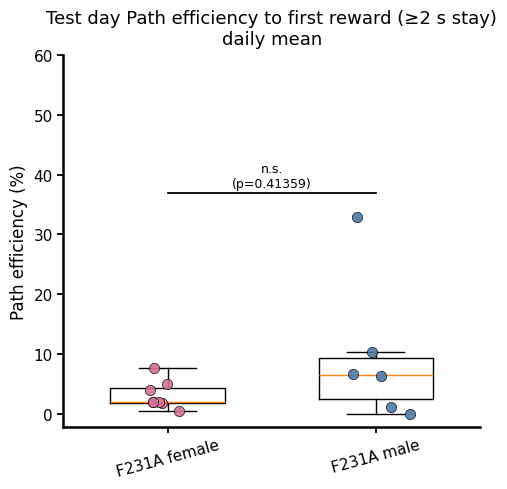


=== Learning-days 1-5 average boxplot: CIPL ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=356.03 vs 138.65, median=323.96 vs 125.48, U=45.0, rank-biserial=0.875, p=0.00466


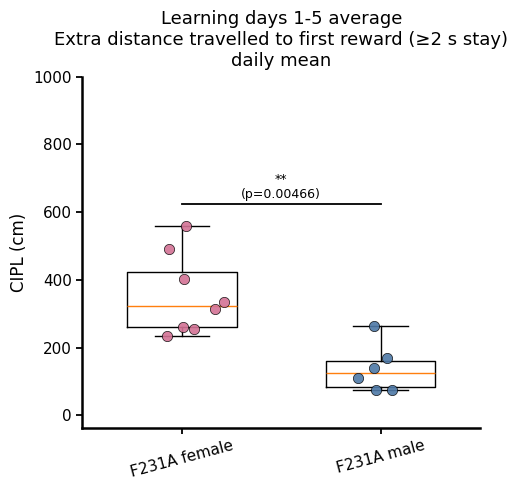


=== Learning-days 1-5 average boxplot: path_eff ===
  F231A female (F): n = 8, animals = [np.str_('BE (F)'), np.str_('BF (F)'), np.str_('BG (F)'), np.str_('BH (F)'), np.str_('BI (F)'), np.str_('BR (F)'), np.str_('F3 (F)'), np.str_('F4 (F)')]
  F231A male (M): n = 6, animals = [np.str_('BB (M)'), np.str_('BL (M)'), np.str_('BM (M)'), np.str_('BN (M)'), np.str_('F7 (M)'), np.str_('F8 (M)')]

Mann–Whitney U tests:
  F231A female vs F231A male: n=8 vs 6, mean=20.99 vs 38.31, median=20.84 vs 34.94, U=2.0, rank-biserial=-0.917, p=0.00266


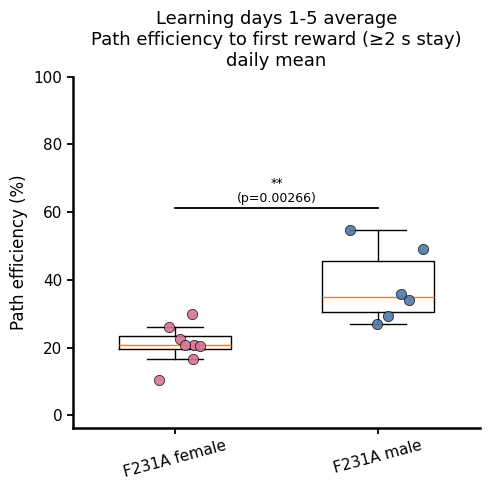

In [301]:
# ============================================================
# Distance / CIPL / Path efficiency
#
# Adds pooled group:
#   'Control' = eYFP_ChR2 + NAc_control + CA1_control
#
# Also allows gender comparison within one genotype:
#   GROUP_BY_GENDER = True
#   GENOTYPE_TO_COMPARE_BY_GENDER = 'F231A'
#   -> compares F231A female vs F231A male
#
# DAY_VALUE_MODE:
#   'daily_mean'
#       learning days = average of all trials in that day
#       test day      = average of available test trial(s), usually one trial
#
#   'first_trial'
#       learning days = first trial only from each day
#       test day      = first test trial only
#
# Stay tag:
#   automatically follows REQUIRE_STAY_2S if it exists.
#   If REQUIRE_STAY_2S = True  -> title shows ≥2 s stay
#   If REQUIRE_STAY_2S = False -> title shows all entries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------

# ------------------------------------------------------------
# Main grouping option
# ------------------------------------------------------------
GROUP_BY_GENDER = True
GENOTYPE_TO_COMPARE_BY_GENDER = 'F231A'

# If GROUP_BY_GENDER = True:
#   groups become ['F', 'M'] within GENOTYPE_TO_COMPARE_BY_GENDER.
#
# If GROUP_BY_GENDER = False:
#   use GROUPS below as normal genotype/group comparison.

# GROUPS = ['ChR2', 'ChR2_short','eYFP_ChR2']
# GROUPS = ['eYFP_ChR2', 'CA1_control','NAc_control']
# GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['CA1', 'CA3', 'Control']
# GROUPS = ['ChR2','CA1','CA3','Control']
GROUPS = ['F231A']

# How to compute each animal × day value
DAY_VALUE_MODE = 'daily_mean'
# DAY_VALUE_MODE = 'first_trial'

# These original genotypes will be pooled into genotype == 'Control'
# eYFP_ChR2 = VTA control
POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A wt',
}

# ------------------------------------------------------------
# Stay-tag logic
# ------------------------------------------------------------
# This assumes your metric computation code defined:
#   REQUIRE_STAY_2S = True/False
#   MIN_DUR_MS = 2000
#
# If those variables do not exist in the current notebook/session,
# these fallbacks prevent the plotting code from crashing.
REQUIRE_STAY_2S_FOR_LABEL = globals().get('REQUIRE_STAY_2S', False)
MIN_DUR_MS_FOR_LABEL = globals().get('MIN_DUR_MS', 2000)

STAY_TAG = (
    f" (≥{MIN_DUR_MS_FOR_LABEL / 1000:g} s stay)"
    if REQUIRE_STAY_2S_FOR_LABEL
    else " (all entries)"
)

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False
SHOW_ANIMAL_IDS = False

JITTER = 0.10
DOT_SIZE = 55
P_DECIMALS = 5

RUN_LINE_PLOTS = True
RUN_TEST_BOXPLOTS = True
RUN_LEARNING_AVG_BOXPLOTS = True

METRICS_TO_PLOT = ['dist_to_trigger', 'CIPL', 'path_eff']
LEARNING_AVG_BOXPLOT_METRICS = ['CIPL', 'path_eff']

METRIC_LABEL = {
    'dist_to_trigger': 'Distance (cm)',
    'CIPL': 'CIPL (cm)',
    'path_eff': 'Path efficiency (%)',
}

METRIC_TITLE = {
    'dist_to_trigger': 'Distance to first reward',
    'CIPL': 'Extra distance travelled to first reward',
    'path_eff': 'Path efficiency to first reward',
}

YMAX_BY_METRIC = {
    'dist_to_trigger': None,
    'CIPL': None,
    'path_eff': None,
}

YMIN = None
Y_BOTTOM_PAD_FRAC = 0.06
BOX_Y_ZERO_PAD_FRAC = 0.04

# Boxplot options
COMPARISONS = 'all'
# COMPARISONS = [('F', 'M')]
# COMPARISONS = [('ChR2', 'Control'), ('NAc', 'Control')]

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

if DAY_VALUE_MODE not in ['daily_mean', 'first_trial']:
    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")

# ---------------------------------------------------------------------
# Colour helper
# ---------------------------------------------------------------------
def get_plot_color(group):
    """
    Allows F/M plotting even if get_genotype_color() does not know gender groups.
    """
    if group == 'F':
        return '#D37295'   # rose
    if group == 'M':
        return '#4E79A7'   # blue

    return get_genotype_color(group)


# ---------------------------------------------------------------------
# 1. Base filter and assign plot_day
# ---------------------------------------------------------------------
needed_cols = [
    'usable',
    'genotype',
    'trial_type',
    'trial_type_day',
    'ses',
    'sub',
] + METRICS_TO_PLOT

if GROUP_BY_GENDER:
    needed_cols = needed_cols + ['gender']

missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

# ------------------------------------------------------------
# Load metadata according to grouping mode
# ------------------------------------------------------------
if GROUP_BY_GENDER:
    groups_to_load = [GENOTYPE_TO_COMPARE_BY_GENDER]

    meta_LT = metadata[
        (metadata['usable'] == 1) &
        (metadata['genotype'] == GENOTYPE_TO_COMPARE_BY_GENDER) &
        (metadata['gender'].astype(str).str.upper().isin(['F', 'M'])) &
        (metadata['trial_type'].isin(['L', 'T']))
    ].copy()

    # Store original genotype before replacing genotype with gender group
    meta_LT['genotype_original'] = meta_LT['genotype']

    # Use gender as the plotting/statistical group
    meta_LT['gender_original'] = meta_LT['gender']
    meta_LT['genotype'] = meta_LT['gender'].astype(str).str.upper()

    GROUPS = ['F', 'M']

    DISPLAY_NAME.update({
        'F': f'{GENOTYPE_TO_COMPARE_BY_GENDER} female',
        'M': f'{GENOTYPE_TO_COMPARE_BY_GENDER} male',
    })

else:
    # If GROUPS contains 'Control', include its original component groups.
    groups_to_load = []

    for g in GROUPS:
        if g == 'Control':
            groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
        else:
            groups_to_load.append(g)

    groups_to_load = sorted(set(groups_to_load))

    meta_LT = metadata[
        (metadata['usable'] == 1) &
        (metadata['genotype'].isin(groups_to_load)) &
        (metadata['trial_type'].isin(['L', 'T']))
    ].copy()

    # Store original genotype before pooling
    meta_LT['genotype_original'] = meta_LT['genotype']

    # Pool VTA control + NAc_control + CA1_control into one displayed/statistical group: Control
    if 'Control' in GROUPS:
        meta_LT.loc[
            meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
            'genotype'
        ] = 'Control'

# ------------------------------------------------------------
# Exclusions
# ------------------------------------------------------------
if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ---------------------------------------------------------------------
# 1b. Add trial_in_day, needed for DAY_VALUE_MODE = 'first_trial'
# ---------------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session',
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()

# ---------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals.
    Also shows gender if using GROUP_BY_GENDER.
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if GROUP_BY_GENDER:
        gender = str(ms['genotype'].dropna().iloc[0])
        return f'{animal_id} ({gender})'

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def get_day_value(ms, day, value_col):
    """
    Returns one value for one animal on one plot_day.

    DAY_VALUE_MODE:
      'daily_mean'  -> mean across all available trials in that day
      'first_trial' -> trial_in_day == 1 only
    """
    md = ms[
        (ms['plot_day'] == day) &
        (ms[value_col].notna())
    ].copy()

    if len(md) == 0:
        return np.nan

    # mean per trial first, in case duplicate rows exist for same trial
    by_trial = (
        md.groupby('trial_in_day', as_index=True)[value_col]
          .mean()
          .sort_index()
    )

    by_trial = by_trial[np.isfinite(by_trial.values)]

    if len(by_trial) == 0:
        return np.nan

    if DAY_VALUE_MODE == 'daily_mean':
        return float(np.nanmean(by_trial.values))

    if DAY_VALUE_MODE == 'first_trial':
        if 1 not in by_trial.index:
            return np.nan
        return float(by_trial.loc[1])

    raise ValueError("DAY_VALUE_MODE must be 'daily_mean' or 'first_trial'")


def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        vals = np.array(
            [get_day_value(ms, d, value_col) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def get_test_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()
        value = get_day_value(ms, 6, value_col)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'value': value,
            'animal_id': get_animal_label(ms, sub)
        })

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def get_learning_avg_group_vals(meta_df, genotype, value_col):
    m = meta_df[
        (meta_df['genotype'] == genotype) &
        (meta_df['plot_day'].isin([1, 2, 3, 4, 5])) &
        (meta_df[value_col].notna())
    ].copy()

    if m.empty:
        return np.array([]), np.array([]), np.array([])

    rows = []

    for sub in m['sub'].unique():
        ms = m[m['sub'] == sub].copy()

        vals_day = np.array(
            [get_day_value(ms, d, value_col) for d in [1, 2, 3, 4, 5]],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals_day)):
            continue

        if np.all(np.isnan(vals_day)):
            continue

        value = np.nanmean(vals_day)

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'animal_id': get_animal_label(ms, sub),
            'value': value
        })

    if len(rows) == 0:
        return np.array([]), np.array([]), np.array([])

    vals = np.array([r['value'] for r in rows], dtype=float)
    subs = np.array([r['sub'] for r in rows])
    ids = np.array([r['animal_id'] for r in rows])

    return vals, subs, ids


def style_nature(ax):
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)


def apply_y_axis(ax, ymax_candidates, value_col):
    manual_ymax = YMAX_BY_METRIC.get(value_col, None)

    if manual_ymax is not None:
        ymax = manual_ymax
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return stat, p


def get_comparisons():
    if COMPARISONS == 'all':
        comparisons = []
        for i in range(len(GROUPS)):
            for j in range(i + 1, len(GROUPS)):
                comparisons.append((GROUPS[i], GROUPS[j]))
        return comparisons

    return COMPARISONS


# ---------------------------------------------------------------------
# 3. Line plot helper
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col):
    ylabel = METRIC_LABEL.get(value_col, value_col)
    title_base = METRIC_TITLE.get(value_col, value_col)

    group_data = {}

    print(f"\n=== Line plot: {value_col} ===")

    for g in GROUPS:
        meta_g = meta_LT[meta_LT['genotype'] == g].copy()
        mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, value_col)

        group_data[g] = {
            'mat': mat_g,
            'subs': subs_g,
            'ids': ids_g,
        }

        print(f"{DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

    fig, ax = plt.subplots(figsize=(8, 5.2))

    ymax_candidates = []

    for g in GROUPS:
        mat = group_data[g]['mat']
        subs = group_data[g]['subs']

        if mat is None or len(subs) == 0:
            continue

        col = get_plot_color(g)
        label = DISPLAY_NAME.get(g, g)

        if PLOT_INDIVIDUAL:
            for row in mat:
                ax.plot(
                    x_vals,
                    row,
                    '-',
                    color=col,
                    alpha=0.12,
                    linewidth=1.0,
                    label='_nolegend_',
                    zorder=1
                )

        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=col,
                alpha=0.18,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=col,
            linewidth=2.2,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if SHOW_SEM_ERRORBARS:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=col,
                elinewidth=1.2,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        ymax_candidates.append(np.nanmax(mean_ + sem_))

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "First trial only"
    else:
        day_value_tag = "Daily mean"

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_title(
        f'{title_base}{STAY_TAG}\nLearning Days + Test, {day_value_tag}',
        fontsize=15,
        pad=8
    )

    style_nature(ax)
    apply_y_axis(ax, ymax_candidates, value_col)

    ax.legend(
        frameon=False,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()


# ---------------------------------------------------------------------
# 4. Boxplot helper
# ---------------------------------------------------------------------
def plot_boxplot(metric_col, boxplot_mode):
    ylabel = METRIC_LABEL.get(metric_col, metric_col)
    title_base = METRIC_TITLE.get(metric_col, metric_col)

    group_vals = {}
    group_subs = {}
    group_ids = {}

    if boxplot_mode == 'test':
        print(f"\n=== Test-day boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_test_group_vals(meta_test, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    elif boxplot_mode == 'learning_mean':
        print(f"\n=== Learning-days 1-5 average boxplot: {metric_col} ===")
        for g in GROUPS:
            vals_g, subs_g, ids_g = get_learning_avg_group_vals(meta_LT, g, metric_col)
            group_vals[g] = vals_g
            group_subs[g] = subs_g
            group_ids[g] = ids_g

    else:
        raise ValueError("boxplot_mode must be 'test' or 'learning_mean'")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_vals[g])}, animals = {list(group_ids[g])}"
        )

    data = [group_vals[g] for g in GROUPS]
    positions = np.arange(len(GROUPS))

    fig, ax = plt.subplots(figsize=(max(5, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = group_vals[g]

        if len(vals) == 0:
            continue

        x = np.random.normal(positions[i], JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_plot_color(g),
            edgecolor='k',
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_ids[g]):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_plot_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # comparisons
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in get_comparisons():
        if g1 not in GROUPS or g2 not in GROUPS:
            print(f"Skipping {g1} vs {g2}: group not in GROUPS")
            continue

        vals1 = group_vals[g1]
        vals2 = group_vals[g2]

        stat, p = mwu(vals1, vals2)

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.2f} vs {np.nanmean(vals2):.2f}, "
                f"median={np.nanmedian(vals1):.2f} vs {np.nanmedian(vals2):.2f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )
        else:
            print(f"  {g1} vs {g2}: p = NaN")

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    # significance lines
    nonempty_data = [v for v in data if len(v) > 0]

    if len(nonempty_data) > 0:
        all_vals = np.concatenate(nonempty_data)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        current_y = ymax + 0.12 * yrng
        y_step = 0.28 * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2

            ax.plot(
                [positions[x1], positions[x2]],
                [current_y, current_y],
                color='k',
                lw=1.3
            )

            ax.text(
                x_mid,
                current_y + 0.015 * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        ymax_box = current_y + 0.25 * yrng

        if YMIN is not None:
            ymin = YMIN
        else:
            ymin = -BOX_Y_ZERO_PAD_FRAC * ymax_box

        ax.set_ylim(ymin, ymax_box)

        yticks = ax.get_yticks()
        yticks = yticks[yticks >= 0]
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

    if DAY_VALUE_MODE == 'first_trial':
        day_value_tag = "first trial only"
    else:
        day_value_tag = "daily mean"

    ax.set_xticks(positions)
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel(ylabel, fontsize=12)

    if boxplot_mode == 'test':
        ax.set_title(
            f"Test day {title_base}{STAY_TAG}\n{day_value_tag}",
            fontsize=13,
            pad=8
        )
    else:
        ax.set_title(
            f"Learning days 1-5 average\n{title_base}{STAY_TAG}\n{day_value_tag}",
            fontsize=13,
            pad=8
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', width=1.3, length=4)
    ax.tick_params(axis='y', labelsize=11)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 5. Run plots
# ---------------------------------------------------------------------
print("\nGroups used for plotting/stats:", GROUPS)
print("Group by gender:", GROUP_BY_GENDER)

if GROUP_BY_GENDER:
    print("Genotype compared by gender:", GENOTYPE_TO_COMPARE_BY_GENDER)
else:
    print("Original genotypes loaded:", groups_to_load)

print("Day value mode:", DAY_VALUE_MODE)
print("Trial column used:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Stay tag:", STAY_TAG)

if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

if RUN_LINE_PLOTS:
    for metric in METRICS_TO_PLOT:
        plot_metric_for_groups(meta_LT, metric)

if RUN_TEST_BOXPLOTS:
    for metric in METRICS_TO_PLOT:
        plot_boxplot(metric, boxplot_mode='test')

if RUN_LEARNING_AVG_BOXPLOTS:
    for metric in LEARNING_AVG_BOXPLOT_METRICS:
        plot_boxplot(metric, boxplot_mode='learning_mean')

Using genotype: F231A (F231A)
Using column: path_eff
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included per within-day comparison:
  Day 1: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 2: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 3: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 4: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Day 5: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']
  Test: n = 14, animals = ['BB', 'BE', 'BF', 'BG', 'BH', 'BI', 'BL', 'BM', 'BN', 'BR', 'F3', 'F4', 'F7', 'F8']

Wilcoxon signed-rank tests: first trial vs best trial of same day
Alternative used: two-sided
Test day is plotted as one dot only and is not test

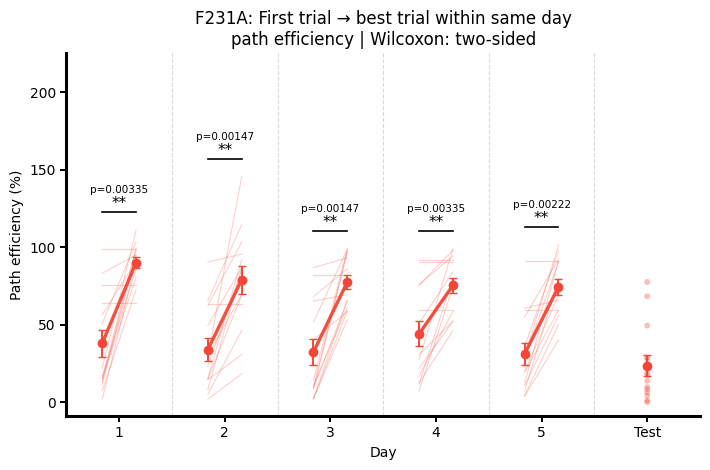

In [263]:
# ============================================================
# Flexible genotype:
# Plot "first trial of each day" -> "best trial of same day"
# Metric: path efficiency (%)
#
# Within-day progress:
#   Day 1 trial 1 -> Day 1 best trial
#   Day 2 trial 1 -> Day 2 best trial
#   Day 3 trial 1 -> Day 3 best trial
#   Day 4 trial 1 -> Day 4 best trial
#   Day 5 trial 1 -> Day 5 best trial
#
# Test day:
#   only one trial, so it is plotted as one dot only
#   no paired line / Wilcoxon test for Test
#
# IMPORTANT:
# For path efficiency, "best trial" = HIGHEST path_eff
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
#   alternative='greater' tests whether best trial > first trial
#   alternative='two-sided' tests whether first and best are different
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'F231A'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control', 'F231A'
PLOT_INDIVIDUAL = True          # False -> only mean ± SEM

EXCLUDE_ID = ['AN', 'BQ', 'BP'] # e.g. ['AS']
EXCLUDE_SUBS = []               # e.g. [43]

# Optional short-duration filtering
FILTER_SHORT_DURATION = False

VALUE_COL = 'path_eff'
VALUE_LABEL = 'Path efficiency (%)'
TITLE_SUFFIX = 'path efficiency'

# Wilcoxon:
# 'greater' = tests whether best trial path_eff > first trial path_eff
# 'less' = tests whether best trial path_eff < first trial path_eff
# 'two-sided' = tests whether first and best are different
WILCOXON_ALTERNATIVE = 'two-sided'

SHOW_P_VALUES = True
SHOW_STARS = True
P_DECIMALS = 5

# x-axis positioning
X_FIRST_OFFSET = -0.16
X_BEST_OFFSET  =  0.16

# p-value annotation spacing
P_LINE_FRAC_ABOVE = 0.08
P_STAR_FRAC_ABOVE = 0.004   # smaller = star closer to horizontal line
P_TEXT_FRAC_ABOVE = 0.075

# y-axis
YMIN = None          # None -> slightly below 0
YMAX = None          # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
needed_cols = ['usable', 'genotype', 'trial_type', 'trial_type_day', 'ses', 'sub', VALUE_COL]
missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GROUP_LABEL, f"({GENOTYPE_TO_PLOT})")
print("Using column:", VALUE_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) For each animal and day:
#    - first trial = trial_in_day == 1
#    - best trial = MAX path_eff within that day
# ------------------------------------------------------------
def per_subject_day_first_best(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, id, first_val, best_val

    For path efficiency:
      best_val = maximum path_eff within that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'first_val', 'best_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        first_val = by_trial.get(1, np.nan)
        best_val = np.nanmax(by_trial.values.astype(float))  # higher path_eff = better

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'first_val': float(first_val),
            'best_val': float(best_val)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build within-day comparison values
# ------------------------------------------------------------
within_day = []

for d in plot_days:
    df_d = per_subject_day_first_best(meta_LT, d, VALUE_COL)

    within_day.append({
        'day': d,
        'df': df_d
    })

print("\nAnimals included per within-day comparison:")
for wd in within_day:
    d = wd['day']
    df_d = wd['df']
    day_label = 'Test' if d == 6 else f'Day {d}'
    print(
        f"  {day_label}: n = {len(df_d)}, "
        f"animals = {list(df_d['id']) if len(df_d) > 0 else []}"
    )

# ------------------------------------------------------------
# 6) Stats + plotting helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def run_wilcoxon_paired(first_vals, best_vals, alternative='greater'):
    """
    Paired Wilcoxon signed-rank test.

    This calls:
        wilcoxon(best_vals, first_vals, alternative=alternative)

    For path efficiency:
      alternative='greater' tests whether best_vals > first_vals.
      alternative='less' tests whether best_vals < first_vals.
      alternative='two-sided' tests whether best_vals != first_vals.

    If all differences are zero, scipy raises an error;
    in that case return p=1.
    """
    first_vals = np.asarray(first_vals, float)
    best_vals = np.asarray(best_vals, float)

    ok = np.isfinite(first_vals) & np.isfinite(best_vals)
    first_vals = first_vals[ok]
    best_vals = best_vals[ok]

    if len(first_vals) == 0:
        return np.nan, np.nan

    diffs = best_vals - first_vals

    if np.allclose(diffs, 0):
        return 0.0, 1.0

    try:
        stat, p = wilcoxon(
            best_vals,
            first_vals,
            alternative=alternative,
            zero_method='wilcox'
        )
    except ValueError:
        stat, p = np.nan, np.nan

    return stat, p


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Run stats first
#    Test day is skipped because it usually has only one trial.
# ------------------------------------------------------------
print("\nWilcoxon signed-rank tests: first trial vs best trial of same day")
print(f"Alternative used: {WILCOXON_ALTERNATIVE}")
print("Test day is plotted as one dot only and is not tested.")

stats_results = {}

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    day_label = 'Test' if d == 6 else f'Day {d}'

    if d == 6:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': len(df_d)
        }
        print(f"  {day_label}: n = {len(df_d)}, no test")
        continue

    if len(df_d) == 0:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': 0
        }
        print(f"  {day_label}: n = 0, p = NaN")
        continue

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    stat, p = run_wilcoxon_paired(
        first_vals,
        best_vals,
        alternative=WILCOXON_ALTERNATIVE
    )

    stats_results[d] = {
        'stat': stat,
        'p': p,
        'n': len(df_d)
    }

    print(
        f"  {day_label}: "
        f"n = {len(df_d)}, "
        f"first mean = {np.nanmean(first_vals):.3f}%, "
        f"best mean = {np.nanmean(best_vals):.3f}%, "
        f"median diff best-first = {np.nanmedian(best_vals - first_vals):.3f}%, "
        f"W = {stat:.3f}, "
        f"p = {format_p(p, P_DECIMALS)}"
        if np.isfinite(p)
        else
        f"  {day_label}: n = {len(df_d)}, p = NaN"
    )

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))

col = get_genotype_color(GENOTYPE_TO_PLOT)

all_y_for_ylim = []

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    if len(df_d) == 0:
        continue

    # --------------------------------------------------------
    # Test day:
    # only plot single trial/best point, no paired line/stat
    # dots remain
    # --------------------------------------------------------
    if d == 6:
        x_test = d

        test_vals = df_d['first_val'].values.astype(float)
        test_vals = test_vals[np.isfinite(test_vals)]

        all_y_for_ylim.extend(test_vals)

        if len(test_vals) == 0:
            continue

        if PLOT_INDIVIDUAL:
            ax.scatter(
                np.full(len(test_vals), x_test),
                test_vals,
                color=col,
                s=18,
                alpha=0.35,
                edgecolor='none',
                zorder=2
            )

        m_test, s_test = mean_sem(test_vals)

        ax.errorbar(
            x_test,
            m_test,
            yerr=s_test,
            fmt='o',
            color=col,
            markersize=6,
            capsize=3,
            linewidth=1.4,
            zorder=5
        )

        continue

    x_first = d + X_FIRST_OFFSET
    x_best  = d + X_BEST_OFFSET

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    all_y_for_ylim.extend(first_vals[np.isfinite(first_vals)])
    all_y_for_ylim.extend(best_vals[np.isfinite(best_vals)])

    # --------------------------------------------------------
    # 1) Individual animal paired lines only
    #    No individual dots for learning days 1-5
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_d.iterrows():
            y_first = row['first_val']
            y_best = row['best_val']

            ax.plot(
                [x_first, x_best],
                [y_first, y_best],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    m_first, s_first = mean_sem(first_vals)
    m_best, s_best = mean_sem(best_vals)

    ax.plot(
        [x_first, x_best],
        [m_first, m_best],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=4
    )

    ax.errorbar(
        x_first,
        m_first,
        yerr=s_first,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

    ax.errorbar(
        x_best,
        m_best,
        yerr=s_best,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

# ------------------------------------------------------------
# 9) Add p-value bars after determining y scale
# ------------------------------------------------------------
if len(all_y_for_ylim) > 0:
    y_data_max = np.nanmax(all_y_for_ylim)
    y_data_min = np.nanmin(all_y_for_ylim)

    yrng = y_data_max - y_data_min
    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(y_data_max), 1.0)

    for wd in within_day:
        d = wd['day']
        df_d = wd['df']

        # Skip test day
        if d == 6:
            continue

        if len(df_d) == 0:
            continue

        x_first = d + X_FIRST_OFFSET
        x_best  = d + X_BEST_OFFSET
        x_mid = (x_first + x_best) / 2

        local_vals = np.r_[
            df_d['first_val'].values.astype(float),
            df_d['best_val'].values.astype(float)
        ]

        local_max = np.nanmax(local_vals)

        y_line = local_max + P_LINE_FRAC_ABOVE * yrng
        y_star = y_line + P_STAR_FRAC_ABOVE * yrng
        y_pval = y_line + P_TEXT_FRAC_ABOVE * yrng

        p = stats_results[d]['p']

        ax.plot(
            [x_first, x_best],
            [y_line, y_line],
            color='black',
            linewidth=1.2,
            zorder=6
        )

        if SHOW_STARS:
            ax.text(
                x_mid,
                y_star,
                p_to_stars(p),
                ha='center',
                va='bottom',
                fontsize=11,
                zorder=7
            )

        if SHOW_P_VALUES:
            ax.text(
                x_mid,
                y_pval,
                f"p={format_p(p, P_DECIMALS)}",
                ha='center',
                va='bottom',
                fontsize=7.5,
                zorder=7
            )

# ------------------------------------------------------------
# 10) Styling
# ------------------------------------------------------------
for d in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(
        d,
        color='0.85',
        linestyle='--',
        linewidth=0.8,
        zorder=0
    )

ax.set_xticks(plot_days)
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(0.5, 6.5)

ax.set_xlabel('Day')
ax.set_ylabel(VALUE_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: First trial → best trial within same day\n'
    f'{TITLE_SUFFIX} | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y_for_ylim) > 0:
        ymax = np.nanmax(all_y_for_ylim)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.55
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)

plt.tight_layout()
plt.show()

Using genotype: F231A (F231A)
Using column: path_eff
Using trial column: inferred from sub/ses order

Group plotted: F231A (F231A)
Using column: path_eff
Animals included per transition:
  Day 1 best -> Day 2 trial 1: n = 14
  Day 2 best -> Day 3 trial 1: n = 14
  Day 3 best -> Day 4 trial 1: n = 14
  Day 4 best -> Day 5 trial 1: n = 14
  Day 5 best -> Test trial 1: n = 14


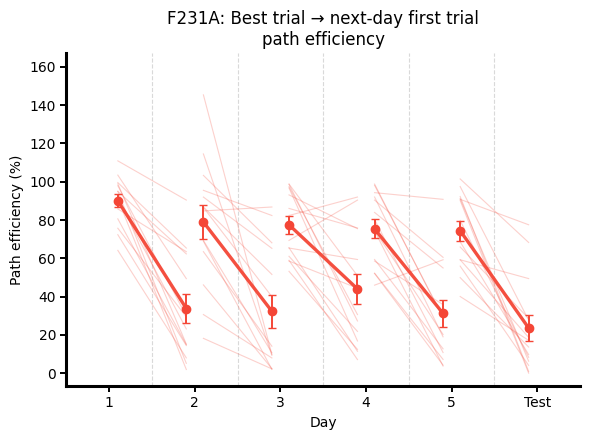

In [264]:
# ============================================================
# Flexible genotype:
# Plot "best trial from previous day" -> "first trial next day"
# Metric: path efficiency
#
# Transitions plotted:
#   Day 1 best  -> Day 2 trial 1
#   Day 2 best  -> Day 3 trial 1
#   Day 3 best  -> Day 4 trial 1
#   Day 4 best  -> Day 5 trial 1
#   Day 5 best  -> Test day trial 1
#
# IMPORTANT:
# For path efficiency, "best trial" = HIGHEST path_eff
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'F231A'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control', 'F231A'
PLOT_INDIVIDUAL = True          # False -> only mean ± SEM

EXCLUDE_ID = ['AN', 'BQ', 'BP'] # e.g. ['AS']
EXCLUDE_SUBS = []               # e.g. [43]

FILTER_SHORT_DURATION = False   # True -> apply short_duration != 1
                                # False -> no short_duration filter

VALUE_COL = 'path_eff'
VALUE_LABEL = 'Path efficiency (%)'
TITLE_SUFFIX = 'path efficiency'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

# y-axis
YMIN = None          # None -> auto with slight padding below 0
YMAX = None          # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
needed_cols = ['usable', 'genotype', 'trial_type', 'trial_type_day', 'ses', 'sub', VALUE_COL]
missing_cols = [c for c in needed_cols if c not in metadata.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Missing columns in metadata: {missing_cols}")

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GROUP_LABEL, f"({GENOTYPE_TO_PLOT})")
print("Using column:", VALUE_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")

# ------------------------------------------------------------
# 4) For each animal and day:
#    - best trial = MAX path_eff within that day
#    - first trial = trial_in_day == 1
# ------------------------------------------------------------
def per_subject_day_values(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, best_val, first_val

    For path efficiency:
      best_val = maximum path_eff within that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'best_val', 'first_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        best_val = np.nanmax(by_trial.values.astype(float))   # higher path_eff = better
        first_val = by_trial.get(1, np.nan)

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'best_val': best_val,
            'first_val': first_val
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build transition values:
#    day d best -> day d+1 first
# ------------------------------------------------------------
transitions = []

for d_prev, d_next in [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]:
    prev_df = (
        per_subject_day_values(meta_LT, d_prev, VALUE_COL)[['sub', 'best_val']]
        .rename(columns={'best_val': 'y_prev'})
    )

    next_df = (
        per_subject_day_values(meta_LT, d_next, VALUE_COL)[['sub', 'first_val']]
        .rename(columns={'first_val': 'y_next'})
    )

    merged = prev_df.merge(next_df, on='sub', how='inner').dropna()

    transitions.append({
        'd_prev': d_prev,
        'd_next': d_next,
        'df': merged
    })

print(f"\nGroup plotted: {GROUP_LABEL} ({GENOTYPE_TO_PLOT})")
print(f"Using column: {VALUE_COL}")
print("Animals included per transition:")

for tr in transitions:
    n = len(tr['df'])
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    nxt_label = 'Test' if d_next == 6 else f'Day {d_next}'
    print(f"  Day {d_prev} best -> {nxt_label} trial 1: n = {n}")

# ------------------------------------------------------------
# 6) Plot helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

col = get_genotype_color(GENOTYPE_TO_PLOT)

# x positions
x_best_offset  = 0.6
x_first_offset = 0.4

all_y = []

for tr in transitions:
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    df_tr = tr['df']

    if len(df_tr) == 0:
        continue

    x_prev = d_prev + x_best_offset
    x_next = d_next + x_first_offset

    # --------------------------------------------------------
    # 1) Individual animal lines
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_tr.iterrows():
            y_prev = row['y_prev']
            y_next = row['y_next']

            ax.plot(
                [x_prev, x_next],
                [y_prev, y_next],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

            all_y.extend([y_prev, y_next])

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    y_prev = df_tr['y_prev'].values.astype(float)
    y_next = df_tr['y_next'].values.astype(float)

    all_y.extend(list(y_prev) + list(y_next))

    m_prev, s_prev = mean_sem(y_prev)
    m_next, s_next = mean_sem(y_next)

    ax.plot(
        [x_prev, x_next],
        [m_prev, m_next],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=3
    )

    ax.errorbar(
        x_prev,
        m_prev,
        yerr=s_prev,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x_next,
        m_next,
        yerr=s_next,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for d in [2, 3, 4, 5, 6]:
    ax.axvline(d, color='0.85', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(1.0, 7.0)

ax.set_xlabel('Day')
ax.set_ylabel(VALUE_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: Best trial → next-day first trial\n'
    f'{TITLE_SUFFIX}',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y) > 0:
        ymax = np.nanmax(all_y)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.15
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()

Using genotype: F231A WT (F231A_wt)
Using column: path_eff
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 9
   sub  id  Day 1 trial 1 trials  Test trials
0   47  BA                     1            1
1   49  BC                     1            1
2   50  BD                     1            1
3   56  BJ                     1            1
4   60  BO                     1            1
5   90  F1                     1            1
6   91  F2                     1            1
7   94  F5                     1            1
8   95  F6                     1            1

Paired values used for Wilcoxon:
   sub  id         y1         y2  diff_y2_minus_y1  n1  n2
0   47  BA   4.381893   5.626034          1.244141   1   1
1   49  BC   1.963299   0.877618         -1.085681   1   1
2   50  BD   8.296410   1.661833         -6.634577   1   1
3   56  BJ  42.023570   4.361235        -37.662335   1   1
4   60  BO  87.565652   8.194581        -7

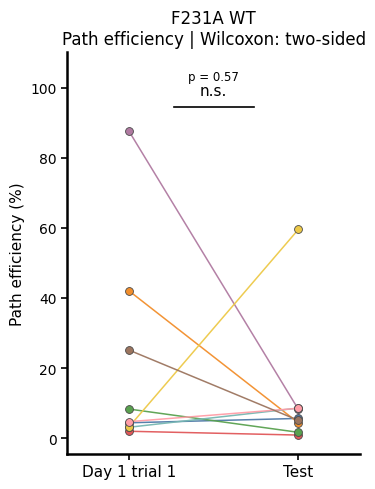

In [300]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flexible genotype:
# Paired comparison for path efficiency
#
# COMPARE_MODE:
#   'day1_vs_test':
#       Day 1 = trial 1 only
#       Test  = first post-learning test trial only
#
#   'day1_vs_day5':
#       Day 1 = mean across available Day 1 trials
#       Day 5 = mean across available Day 5 trials
#
#   'day1_trial1_vs_day5_trial1':
#       Day 1 = trial 1 only
#       Day 5 = trial 1 only
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
# ============================================================

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_vs_test'
# COMPARE_MODE = 'day1_vs_test'
# COMPARE_MODE = 'day1_vs_day5'

GENOTYPE_TO_USE = 'F231A_wt'

PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False
SHOW_ANIMAL_IDS = False

EXCLUDE_ID = ['AN', 'BQ', 'BP']
EXCLUDE_SUBS = []

VALUE_COL = 'path_eff'
VALUE_LABEL = 'Path efficiency (%)'

FILTER_SHORT_DURATION = False

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether y1 > y2
# 'less'      = tests whether y1 < y2
WILCOXON_ALTERNATIVE = 'two-sided'

INDIVIDUAL_COLOR_MODE = 'pastel'
DOT_EDGE = True

YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
    'F231A': 'F231A',
    'F231A_wt': 'F231A WT',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Filter
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using column:", VALUE_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    """
    One value per animal = mean across available trials in that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(np.nanmean(by_trial.values)),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day, value_col):
    """
    One value per animal = trial 1 only from that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 6, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    comparison_description = 'Day 1 trial 1 vs Test trial 1'

elif COMPARE_MODE == 'day1_vs_day5':
    day1_df = per_subject_day_mean(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_mean(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1'
    right_label = 'Day 5'
    comparison_description = 'Day 1 daily mean vs Day 5 daily mean'

elif COMPARE_MODE == 'day1_trial1_vs_day5_trial1':
    day1_df = per_subject_day_first_trial(meta_LT, 1, VALUE_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 5, VALUE_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Day 5 trial 1'
    comparison_description = 'Day 1 trial 1 vs Day 5 trial 1'

else:
    raise ValueError(
        "COMPARE_MODE must be 'day1_vs_test', "
        "'day1_vs_day5', or 'day1_trial1_vs_day5_trial1'"
    )

title_txt = f'{GENOTYPE_LABEL}'

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
if len(paired) > 0:
    paired_print = paired.copy()
    paired_print['diff_y2_minus_y1'] = paired_print['y2'] - paired_print['y1']
    print(paired_print[['sub', 'id', 'y1', 'y2', 'diff_y2_minus_y1', 'n1', 'n2']])
else:
    print("No paired data.")

# ------------------------------------------------------------
# 6) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.3g}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)

print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")
print(comparison_description)

# ------------------------------------------------------------
# 7) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

x1, x2 = 0.00, 0.55

n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'], row['y2']],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'], row['y2']],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'],
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

if PLOT_GROUP_MEAN and len(y1) > 0:
    m1 = np.nanmean(y1)
    m2 = np.nanmean(y2)

    s1 = 0.0 if len(y1) <= 1 else np.nanstd(y1, ddof=1) / np.sqrt(len(y1))
    s2 = 0.0 if len(y2) <= 1 else np.nanstd(y2, ddof=1) / np.sqrt(len(y2))

    ax.plot([x1, x2], [m1, m2], '-', color=base_col, linewidth=2.4, zorder=3)

    ax.errorbar(
        x1, m1, yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2, m2, yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# significance line + stars + p value
all_y = np.r_[y1, y2]

if len(all_y) > 0 and np.isfinite(all_y).any():
    ymax_data = np.nanmax(all_y)
    ymin_data = np.nanmin(all_y)
    yrng = ymax_data - ymin_data

    if not np.isfinite(yrng) or yrng <= 0:
        yrng = ymax_data if ymax_data > 0 else 1.0

    y_line = ymax_data + 0.08 * yrng
    y_star = ymax_data + 0.11 * yrng
    y_pval = ymax_data + 0.16 * yrng
else:
    ymax_data = 1.0
    yrng = 1.0
    y_line = 1.08
    y_star = 1.11
    y_pval = 1.16

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel(VALUE_LABEL, fontsize=11)

ax.set_title(
    f'{title_txt}\nPath efficiency | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is not None:
    ymax = YMAX
else:
    ymax = y_pval + 0.10 * yrng

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()

 11%|█▏        | 712/6195 [00:06<00:52, 105.24it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 19%|█▉        | 1170/6195 [00:10<00:40, 125.08it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 42%|████▏     | 2615/6195 [00:22<00:21, 167.04it/s]

...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-071_id-C1/ses-01_date-20260326/behav/sub-071_ses-01_trial-06_data-position.csv' does not exist.


 88%|████████▊ | 5424/6195 [00:44<00:06, 119.50it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


100%|██████████| 6195/6195 [00:51<00:00, 119.80it/s]


Fail-rate animals included:
  VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  CA1 (CA1): n = 7, ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3): n = 7, ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  CA1 control (CA1_control): n = 3, ids = ['C9', 'C10', 'C11']

Group fail rate by day:

VTA (ChR2)
  Day 1: mean fail rate = 1.04%, SEM = 1.04%, n = 12
  Day 2: mean fail rate = 3.12%, SEM = 2.24%, n = 12
  Day 3: mean fail rate = 1.04%, SEM = 1.04%, n = 12
  Day 4: mean fail rate = 0.00%, SEM = 0.00%, n = 12
  Day 5: mean fail rate = 0.00%, SEM = 0.00%, n = 12
  Test: mean fail rate = 0.00%, SEM = 0.00%, n = 12

CA1 (CA1)
  Day 1: mean fail rate = 21.43%, SEM = 7.07%, n = 7
  Day 2: mean fail rate = 14.29%, SEM = 5.05%, n = 7
  Day 3: mean fail rate = 16.07%, SEM = 3.57%, n = 7
  Day 4: mean fail rate = 3.57%, SEM = 2.31%, n = 7
  Day 5: mean fail rate = 0.00%, SEM = 0.00%, n = 7
  Test: mean fail rate = 0.00%, SEM = 0.00%, 

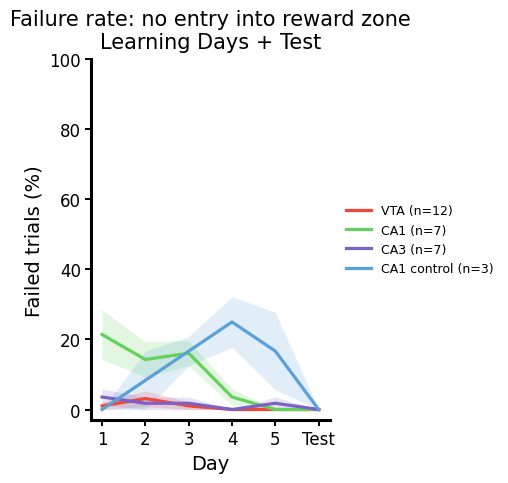

In [94]:
# ============================================================
# Compute and plot fail rate across L1-L5 + Test
#
# Success = at least one entrance into ANY trigger zone
# Fail    = no entrance into any trigger zone in that trial
#
# Produces:
#   metadata['entered_any_trigger'] = 1/0
#   metadata['fail_any_trigger']    = 1/0
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# OPTIONS
# ============================================================
#GROUPS = ['ChR2', 'eYFP_ChR2']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA1']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA3']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
GROUPS = ['ChR2','CA1', 'CA3', 'CA1_control']
# GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

EXCLUDE_ID = ['AS', 'AN']     # e.g. ['AS', 'AN']
EXCLUDE_SUBS = []     # e.g. [43]

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
SHOW_SEM_SHADING = True
SHOW_SEM_ERRORBARS = False

R_TRIGGER = 10 / 1.2

YMIN = -3             # makes 0 visible above bottom axis
YMAX = 100
Y_TICK_STEP = 20

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1) Compute success/fail for each trial
# ============================================================
metadata['entered_any_trigger'] = np.nan
metadata['fail_any_trigger'] = np.nan

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    position_ = add_dist_to_trigger(position.copy(), triggerLoc)

    entered = False

    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i + 1
        )

        if df_trigger_interaction is not None and len(df_trigger_interaction) > 0:
            entered = True
            break

    metadata.at[trial_id, 'entered_any_trigger'] = 1 if entered else 0
    metadata.at[trial_id, 'fail_any_trigger'] = 0 if entered else 1

# ============================================================
# 2) Filter metadata
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(GROUPS)) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['fail_any_trigger'].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 3) Assign plot_day: L1-L5 + first post-learning Test = day 6
# ============================================================
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1-5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ============================================================
# 4) Build animal x day fail-rate matrix
# ============================================================
def build_fail_rate_matrix(meta_group):
    """
    For each animal/day:
      fail rate = mean(fail_any_trigger) * 100

    Since fail_any_trigger is 1 for fail and 0 for success,
    the daily mean gives the proportion of failed trials.
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        fail_by_day = ms.groupby('plot_day')['fail_any_trigger'].mean() * 100.0

        vals = np.array(
            [fail_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem

# ============================================================
# 5) Build group data
# ============================================================
group_data = {}

print("Fail-rate animals included:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_fail_rate_matrix(meta_g)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

# ============================================================
# 6) Print day-wise fail rate
# ============================================================
print("\nGroup fail rate by day:")
for g in GROUPS:
    mat = group_data[g]['mat']

    if mat is None:
        continue

    print(f"\n{DISPLAY_NAME.get(g, g)} ({g})")
    for i, d in enumerate(plot_days):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            print(f"  Day {d}: no data")
            continue

        mean_fail = np.nanmean(vals)
        sem_fail = np.nanstd(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
        label = 'Test' if d == 6 else f'Day {d}'

        print(f"  {label}: mean fail rate = {mean_fail:.2f}%, SEM = {sem_fail:.2f}%, n = {len(vals)}")

# ============================================================
# 7) Plot
# ============================================================
fig, ax = plt.subplots(figsize=(6.2, 5.2))

for g in GROUPS:
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']

    if mat is None or len(subs) == 0:
        continue

    col = get_genotype_color(g)
    label = DISPLAY_NAME.get(g, g)

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=0.15,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_ = np.nanmean(mat, axis=0)
    sem_ = sem_by_day(mat)

    if SHOW_SEM_SHADING:
        ax.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.18,
            linewidth=0,
            zorder=2
        )

    ax.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        linewidth=2.3,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

    if SHOW_SEM_ERRORBARS:
        ax.errorbar(
            x_vals,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            elinewidth=1.2,
            capsize=3,
            alpha=0.9,
            zorder=4
        )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Failed trials (%)', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.set_yticks(np.arange(0, YMAX + 1, Y_TICK_STEP))
ax.tick_params(axis='y', labelsize=12)

ax.set_ylim(YMIN, YMAX)

ax.set_title(
    'Failure rate: no entry into reward zone\nLearning Days + Test',
    fontsize=15,
    pad=8
)

ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

ax.legend(
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()

In [76]:
print(metadata[['L_actual', 'L_shortest', 'CIPL']].corr())

# Check whether L_shortest changes across learning days
tmp = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['L_shortest'].notna())
].copy()

tmp['plot_day'] = np.nan
mask_L = tmp['trial_type'] == 'L'
tmp.loc[mask_L, 'plot_day'] = tmp.loc[mask_L, 'trial_type_day']

for sub in tmp['sub'].unique():
    ms = tmp[tmp['sub'] == sub]
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = tmp.index[
        (tmp['sub'] == sub) &
        (tmp['trial_type'] == 'T') &
        (tmp['ses'] == first_T_ses)
    ]
    tmp.loc[idx, 'plot_day'] = 6

tmp = tmp[tmp['plot_day'].isin([1,2,3,4,5,6])].copy()

summary = (
    tmp.groupby(['genotype', 'plot_day'])['L_shortest']
       .agg(['mean', 'std', 'count'])
       .reset_index()
)

print(summary)

            L_actual  L_shortest      CIPL
L_actual    1.000000    0.212780  0.994167
L_shortest  0.212780    1.000000  0.106154
CIPL        0.994167    0.106154  1.000000
     genotype  plot_day       mean        std  count
0       ArchT       1.0  37.365402  20.253192     48
1       ArchT       2.0  31.484045  16.937097     47
2       ArchT       3.0  36.453064  18.080572     48
3       ArchT       4.0  33.701927  17.213137     48
4       ArchT       5.0  31.690167  17.336974     48
..        ...       ...        ...        ...    ...
73  eYFP_ChR2       2.0  35.866066  21.191010     40
74  eYFP_ChR2       3.0  33.294695  18.284776     40
75  eYFP_ChR2       4.0  30.146381  18.373580     39
76  eYFP_ChR2       5.0  33.093331  18.004688     40
77  eYFP_ChR2       6.0  35.345171  11.108632      5

[78 rows x 5 columns]



=== dist_to_trigger ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


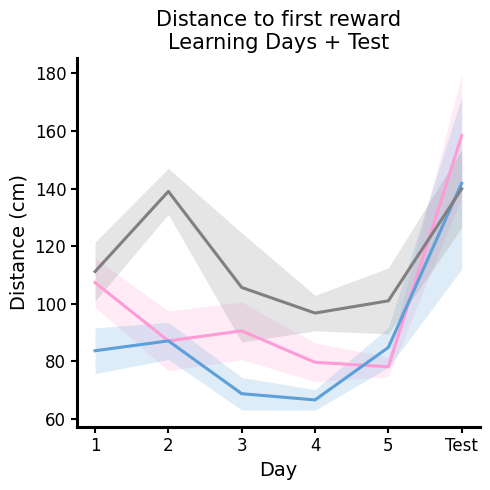


=== CIPL ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


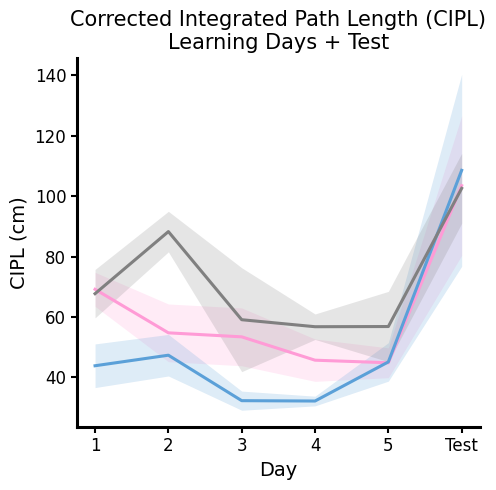


=== path_eff ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


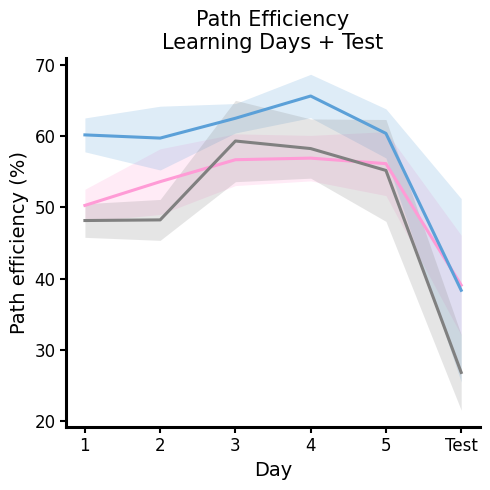

In [11]:
# Distance / CIPL / Path efficiency
# Plot ArchT vs eYFP_ArchT (+/- WT)
# Metrics: dist_to_trigger, CIPL, path_eff

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# OPTIONS for plotting
# ---------------------------------------------------------------------
INCLUDE_WT    = True    # True → include WT, False → only ArchT & eYFP_ArchT
ADD_STAY_TAG  = False   # True → add "(≥2 s stay)" into all titles

# ---------------------------------------------------------------------
# 1. Base filter: usable, not short, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST after last L session → day 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # L1–L5 + Test(6)

# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    """
    meta_group: subset of meta_LT for one genotype
    value_col:  name of column to average (e.g. 'dist_to_trigger', 'CIPL', 'path_eff')
    """
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete days 1–6 for that metric for this animal
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3. Plot helper (ArchT vs eYFP_ArchT (+/- WT))
# ---------------------------------------------------------------------
def plot_metric_for_all_genotypes(meta_LT, value_col, ylabel, title,
                                  include_wt=True):  # NEW ARG
    """
    include_wt = False → only plot ArchT & eYFP_ArchT
    """
    # split by genotype
    meta_ArchT = meta_LT[meta_LT['genotype'] == 'ArchT']
    meta_eYFP  = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']
    meta_WT    = meta_LT[meta_LT['genotype'] == 'WT']

    mat_ArchT, subs_ArchT = build_genotype_matrix(meta_ArchT, value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_WT,    subs_WT    = build_genotype_matrix(meta_WT,    value_col)

    print(f"\n=== {value_col} ===")
    print("ArchT animals plotted:", len(subs_ArchT))
    print("eYFP_ArchT animals plotted:", len(subs_eYFP))
    print("WT animals plotted:", len(subs_WT))

    plt.figure(figsize=(5,5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)   # no WT fallback requested

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        # shaded SEM
        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        # mean curve
        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    # always plot ArchT + eYFP_ArchT
    plot_group(mat_ArchT, subs_ArchT, 'ArchT',      'ArchT')
    plot_group(mat_eYFP,  subs_eYFP,  'eYFP_ArchT', 'eYFP_ArchT')

    # optionally plot WT
    if include_wt:
        plot_group(mat_WT, subs_WT, 'WT', 'WT')

    # axes, style
    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

#    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4. Call for each metric
# ---------------------------------------------------------------------
stay_tag = " (≥2 s stay)" if ADD_STAY_TAG else ""

# a) Distance (stored as dist_to_trigger)
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='dist_to_trigger',
    ylabel='Distance (cm)',
    title=f'Distance to first reward{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

# b) CIPL = L_actual - L_shortest
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='CIPL',
    ylabel='CIPL (cm)',
    title=f'Corrected Integrated Path Length (CIPL){stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

# c) Path efficiency = L_shortest / L_actual * 100
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='path_eff',
    ylabel='Path efficiency (%)',
    title=f'Path Efficiency{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

Test day CIPL per animal:
  ArchT:      n = 6,  animals = [28 29 30 31 32 33]
  eYFP_ArchT: n = 6,   animals = [34 35 36 37 38 39]
  WT:         n = 4,     animals = [24 25 26 27]
ArchT vs eYFP_ArchT: raw p = 0.937
ArchT vs WT: raw p = 0.762
eYFP_ArchT vs WT: raw p = 0.914

FDR-corrected p-values (BH):
  ArchT vs eYFP_ArchT: p_FDR = 0.937
  ArchT vs WT: p_FDR = 0.937
  eYFP_ArchT vs WT: p_FDR = 0.937


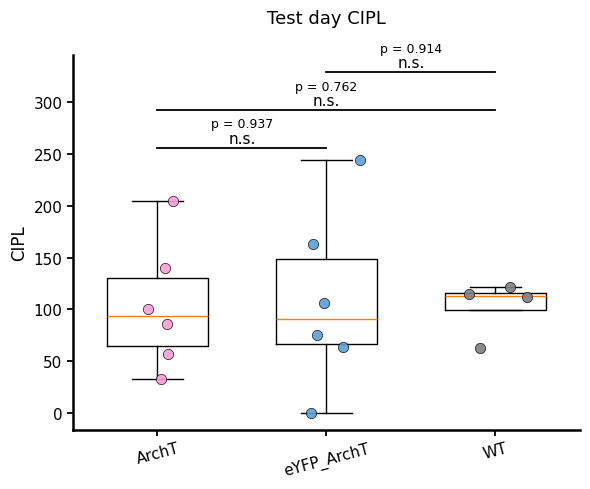

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Try FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR skipped (raw p-values used).")

# ============================================================
# OPTIONS (ArchT / eYFP_ArchT / optional WT)
# ============================================================
INCLUDE_WT   = True    # True → include WT, False → only ArchT & eYFP_ArchT
ADD_2S_TAG   = False   # True → add "(≥2 s stay)" in title

# Which metric to compare (boxplot on TEST day per animal)
METRIC_COL   = 'CIPL'  # or 'dist_to_trigger' or 'path_eff'

# ============================================================
# 1) Build meta_LT with plot_day (L1–5, Test=6)
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[METRIC_COL].notna())
].copy()

meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# Keep only test day
meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()


# ============================================================
# 2) Helper: extract per-animal values on test day
# ============================================================
def get_group_vals(meta_df, genotype, value_col):
    m = meta_df[meta_df['genotype'] == genotype]
    if m.empty:
        return np.array([]), np.array([])
    per_sub = (
        m.groupby('sub')[value_col]
         .mean()
         .astype(float)
    )
    return per_sub.values, per_sub.index.values  # vals, animal IDs


# Base two groups
vals_ArchT, subs_ArchT = get_group_vals(meta_test, 'ArchT',       METRIC_COL)
vals_eYFP,  subs_eYFP  = get_group_vals(meta_test, 'eYFP_ArchT',  METRIC_COL)

print(f"Test day {METRIC_COL} per animal:")
print(f"  ArchT:      n = {len(vals_ArchT)},  animals = {subs_ArchT}")
print(f"  eYFP_ArchT: n = {len(vals_eYFP)},   animals = {subs_eYFP}")

# Optional WT
if INCLUDE_WT:
    vals_WT, subs_WT = get_group_vals(meta_test, 'WT', METRIC_COL)
    print(f"  WT:         n = {len(vals_WT)},     animals = {subs_WT}")


# ============================================================
# 3) Assemble data & group labels depending on options
# ============================================================
if INCLUDE_WT:
    data   = [vals_ArchT, vals_eYFP, vals_WT]
    groups = ["ArchT", "eYFP_ArchT", "WT"]
else:
    data   = [vals_ArchT, vals_eYFP]
    groups = ["ArchT", "eYFP_ArchT"]

positions = np.arange(len(groups))


# ============================================================
# 4) Boxplot + jitter
# ============================================================
def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

fig, ax = plt.subplots(figsize=(6, 5))

# plain boxes (no fliers)
ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=False,
    showfliers=False
)

# jittered points
for i, vals in enumerate(data):
    if len(vals) == 0:
        continue
    x = np.random.normal(positions[i], 0.14, size=len(vals))
    col = get_genotype_color(groups[i])   # expects 'ArchT', 'eYFP_ArchT', 'WT'
    ax.scatter(
        x, vals,
        s=55,
        color=col,
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )


# ============================================================
# 5) Mann–Whitney + FDR (BH) – FDR printed, RAW p on figure
# ============================================================
comparisons = []
comparisons.append(("ArchT vs eYFP_ArchT", 0, 1, vals_ArchT, vals_eYFP))

if INCLUDE_WT:
    comparisons.append(("ArchT vs WT",        0, 2, vals_ArchT, vals_WT))
    comparisons.append(("eYFP_ArchT vs WT",   1, 2, vals_eYFP,  vals_WT))

# raw p-values
p_raw = []
for name, _, _, v1, v2 in comparisons:
    p = mwu(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR for reporting only
if HAS_SM:
    mask = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask.any():
        _, p_corr, _, _ = multipletests(p_raw[mask], alpha=0.05, method='fdr_bh')
        p_adj[mask] = p_corr
    print("\nFDR-corrected p-values (BH):")
    for (name, *_), pF in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {pF:.3g}")
else:
    print("\nUsing raw p-values only (no FDR)\n")

# ---- bars / stars / p USING RAW p-values ----
all_vals = np.concatenate([v for v in data if len(v) > 0]) if any(len(v) > 0 for v in data) else np.array([np.nan])
ymax   = np.nanmax(all_vals)
y_base = ymax * 1.05
y_step = 0.15 * ymax

for (name, i, j, _, _), p_r in zip(comparisons, p_raw):
    if np.isnan(p_r) or not np.isfinite(ymax):
        continue

    y = y_base
    y_base += y_step

    # straight horizontal bar (no dips)
    ax.plot(
        [positions[i], positions[j]],
        [y, y],
        color='k',
        lw=1.3
    )

    # stars
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.02 * ymax,
        p_to_stars(p_r),
        ha='center',
        fontsize=11
    )

    # numeric raw p-value
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.08 * ymax,
        f"p = {p_r:.3g}",
        ha='center',
        fontsize=9
    )


# ============================================================
# 6) Cosmetics + title with optional "(≥2 s stay)"
# ============================================================
ax.set_xticks(positions)
ax.set_xticklabels(groups, fontsize=11, rotation=15)
ax.set_ylabel(f'{METRIC_COL}', fontsize=12)

stay_tag = " (≥2 s stay)" if ADD_2S_TAG else ""
ax.set_title(f"Test day {METRIC_COL}{stay_tag}\n", fontsize=13, pad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', width=1.3, length=4)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

  genotype  total_trial_n   mean_dist     sd_dist   n
0     ChR2              1  157.060611  129.523072  12
1     ChR2              2  278.565502  219.285901  12
2     ChR2              3  142.712539  131.217874  12
3     ChR2              4  197.196475  126.646089  12
4     ChR2              5  235.279692  229.207652  12


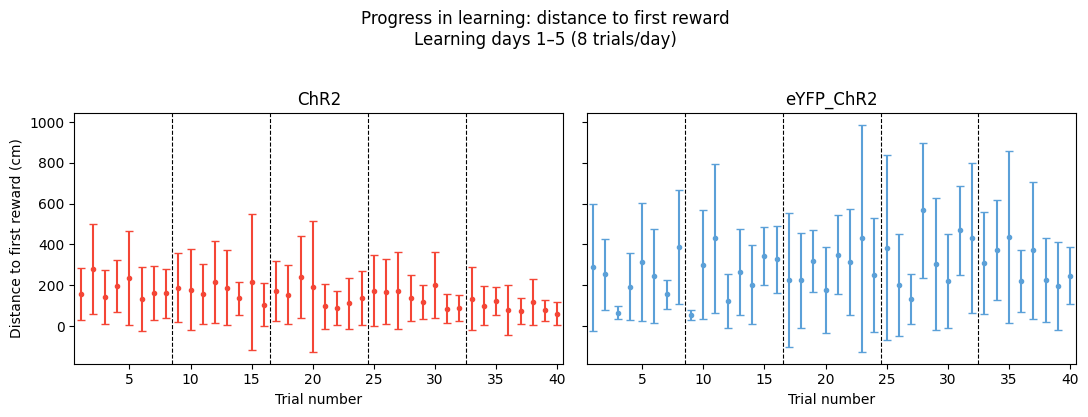

In [10]:
# progress of learning

# ------------------------------------------------------------
# 1) Filter: usable, not short, ChR2/eYFP, LEARNING (L) days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].between(1, 5)) &
    (metadata['dist_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Ensure we have trial_in_day = 1..8
# ------------------------------------------------------------
trials_per_day = 8

candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    # fall back: order within session for each animal
    meta_L = meta_L.sort_values(['sub', 'ses', 'trial_type_day']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, trials_per_day)].copy()

# ------------------------------------------------------------
# 3) Create global trial index = "total_trial_n" (1..40 for 5 days)
# ------------------------------------------------------------
meta_L['total_trial_n'] = (
    (meta_L['trial_type_day'] - 1) * trials_per_day + meta_L['trial_in_day']
).astype(int)

# ------------------------------------------------------------
# 4) Group: mean & SD distance per genotype × total_trial_n
# ------------------------------------------------------------
summary = (
    meta_L
    .groupby(['genotype', 'total_trial_n'])['dist_to_trigger']
    .agg(mean_dist='mean', sd_dist='std', n='size')
    .reset_index()
)

print(summary.head())

# ------------------------------------------------------------
# 5) Plot: error bars (mean ± SD) per trial, faceted by group
# ------------------------------------------------------------
groups = ['ChR2', 'eYFP_ChR2']
colors = {g: get_genotype_color(g) for g in groups}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, g in zip(axes, groups):
    df_g = summary[summary['genotype'] == g].sort_values('total_trial_n')

    x = df_g['total_trial_n'].values
    y = df_g['mean_dist'].values
    sd = df_g['sd_dist'].values

    # vertical error bars only (like your R code)
    ax.errorbar(
        x, y,
        yerr=sd,
        fmt='none',
        ecolor=colors[g],
        elinewidth=1.5,
        capsize=3
    )

    # optional: mean points
    ax.plot(x, y, marker='o', linestyle='none', color=colors[g], markersize=3)

    # vertical dashed lines between learning days (every 8 trials)
    for boundary in range(trials_per_day, trials_per_day * 5, trials_per_day):
        ax.axvline(boundary + 0.5, color='k', linestyle='--', linewidth=0.8)

    ax.set_title(g)
    ax.set_xlabel('Trial number')
    ax.set_xlim(0.5, trials_per_day * 5 + 0.5)

axes[0].set_ylabel('Distance to first reward (cm)')

plt.suptitle('Progress in learning: distance to first reward\nLearning days 1–5 (8 trials/day)', y=1.03, fontsize=12)

plt.tight_layout()
plt.show()

Test day CIPL per animal:
  ChR2:       n = 12,  animals = [ 1  3  4  6  7  8  9 10 11 12 16 18]
  eYFP_ChR2:  n = 5,  animals = [19 20 21 22 23]
ChR2 vs eYFP: raw p = 0.0194

FDR-corrected p-values (BH):
  ChR2 vs eYFP: p_FDR = 0.0194


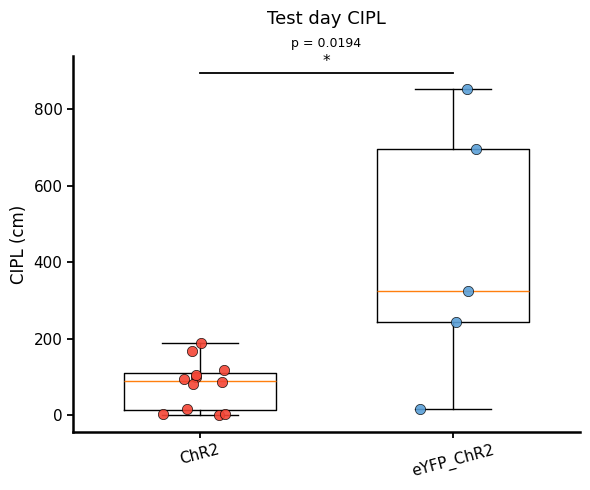

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Try FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR skipped (raw p-values used).")

# ============================================================
# OPTIONS
# ============================================================
# 1) Whether to include a third group at all
INCLUDE_THIRD_GROUP = False   # False → only ChR2 & eYFP_ChR2

# 2) If third group is included, which genotype should it be?
USE_SHORT_THIRD = True       # True → ChR2_short, False → Hp

# 3) Whether to add "(≥2 s stay)" in the title
ADD_2S_TAG = False           # True → add text, False → no text

# Column name for CIPL in your metadata
CIPL_COL = 'CIPL'            # or 'CIPL_first' etc.


# ============================================================
# 1) Build meta_LT with plot_day (L1–5, Test=6)
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp', 'ChR2_short'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[CIPL_COL].notna())
].copy()

meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# Keep only test day
meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()


# ============================================================
# 2) Helper: extract per-animal CIPL on test day
# ============================================================
def get_group_vals(meta_df, genotype, value_col):
    m = meta_df[meta_df['genotype'] == genotype]
    if m.empty:
        return np.array([]), np.array([])
    per_sub = (
        m.groupby('sub')[value_col]
         .mean()
         .astype(float)
    )
    return per_sub.values, per_sub.index.values  # vals, animal IDs


# Base two groups
vals_ChR2,  subs_ChR2  = get_group_vals(meta_test, 'ChR2',      CIPL_COL)
vals_eYFP,  subs_eYFP  = get_group_vals(meta_test, 'eYFP_ChR2', CIPL_COL)

print("Test day CIPL per animal:")
print(f"  ChR2:       n = {len(vals_ChR2)},  animals = {subs_ChR2}")
print(f"  eYFP_ChR2:  n = {len(vals_eYFP)},  animals = {subs_eYFP}")

# Third group (optional)
if INCLUDE_THIRD_GROUP:
    if USE_SHORT_THIRD:
        third_key   = 'ChR2_short'
        third_label = 'ChR2 short'
    else:
        third_key   = 'Hp'
        third_label = 'Hp'

    vals_third, subs_third = get_group_vals(meta_test, third_key, CIPL_COL)
    print(f"  {third_key}: n = {len(vals_third)}, animals = {subs_third}")


# ============================================================
# 3) Assemble data & group labels depending on options
# ============================================================
if INCLUDE_THIRD_GROUP:
    data      = [vals_ChR2, vals_eYFP, vals_third]
    groups    = ["ChR2", "eYFP_ChR2", third_label]
else:
    data      = [vals_ChR2, vals_eYFP]
    groups    = ["ChR2", "eYFP_ChR2"]

positions = np.arange(len(groups))


# ============================================================
# 4) Boxplot + jitter
# ============================================================
def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

fig, ax = plt.subplots(figsize=(6, 5))

# plain boxes (no fliers)
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=False,
    showfliers=False
)

# jittered points
for i, vals in enumerate(data):
    if len(vals) == 0:
        continue
    x = np.random.normal(positions[i], 0.08, size=len(vals))
    # assume your helper has keys: 'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp'
    key_for_color = groups[i].replace(" ", "_")
    col = get_genotype_color(key_for_color)
    ax.scatter(
        x, vals,
        s=55,
        color=col,
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )


# ============================================================
# 5) Mann–Whitney + FDR (BH) – FDR printed, RAW p on figure
# ============================================================
comparisons = []

# always have ChR2 vs eYFP
comparisons.append(("ChR2 vs eYFP", 0, 1, vals_ChR2, vals_eYFP))

if INCLUDE_THIRD_GROUP:
    comparisons.append((f"ChR2 vs {third_label}", 0, 2, vals_ChR2,  vals_third))
    comparisons.append((f"eYFP vs {third_label}", 1, 2, vals_eYFP,  vals_third))

# raw p-values
p_raw = []
for name, _, _, v1, v2 in comparisons:
    p = mwu(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR for reporting only
if HAS_SM:
    mask = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask.any():
        _, p_corr, _, _ = multipletests(p_raw[mask], alpha=0.05, method='fdr_bh')
        p_adj[mask] = p_corr
    print("\nFDR-corrected p-values (BH):")
    for (name, *_), pF in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {pF:.3g}")
else:
    print("\nUsing raw p-values only (no FDR)\n")

# ---- bars / stars / p USING RAW p-values ----
all_vals = np.concatenate([v for v in data if len(v) > 0])
ymax   = np.nanmax(all_vals)
y_base = ymax * 1.05
# if fewer comparisons, step can be smaller; but 0.15*ymax is fine
y_step = 0.15 * ymax

for (name, i, j, _, _), p_r in zip(comparisons, p_raw):
    if np.isnan(p_r):
        continue
    s = p_to_stars(p_r)

    y = y_base
    y_base += y_step

    # straight horizontal bar (no dips)
    ax.plot(
        [positions[i], positions[j]],
        [y, y],
        color='k',
        lw=1.3
    )

    # stars
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.02 * ymax,
        s,
        ha='center',
        fontsize=11
    )

    # numeric raw p-value
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.08 * ymax,
        f"p = {p_r:.3g}",
        ha='center',
        fontsize=9
    )


# ============================================================
# 6) Cosmetics + title with optional "(≥2 s stay)"
# ============================================================
ax.set_xticks(positions)
ax.set_xticklabels(groups, fontsize=11, rotation=15)
ax.set_ylabel('CIPL (cm)', fontsize=12)

if INCLUDE_THIRD_GROUP:
    comp_part = "ChR2 vs eYFP vs " + third_label
else:
    comp_part = "ChR2 vs eYFP"

stay_tag = " (≥2 s stay)" if ADD_2S_TAG else ""
ax.set_title(f"Test day CIPL{stay_tag}\n", fontsize=13, pad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', width=1.3, length=4)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

### GDI. plot distance to first reward across days 1–5, plus test day if available


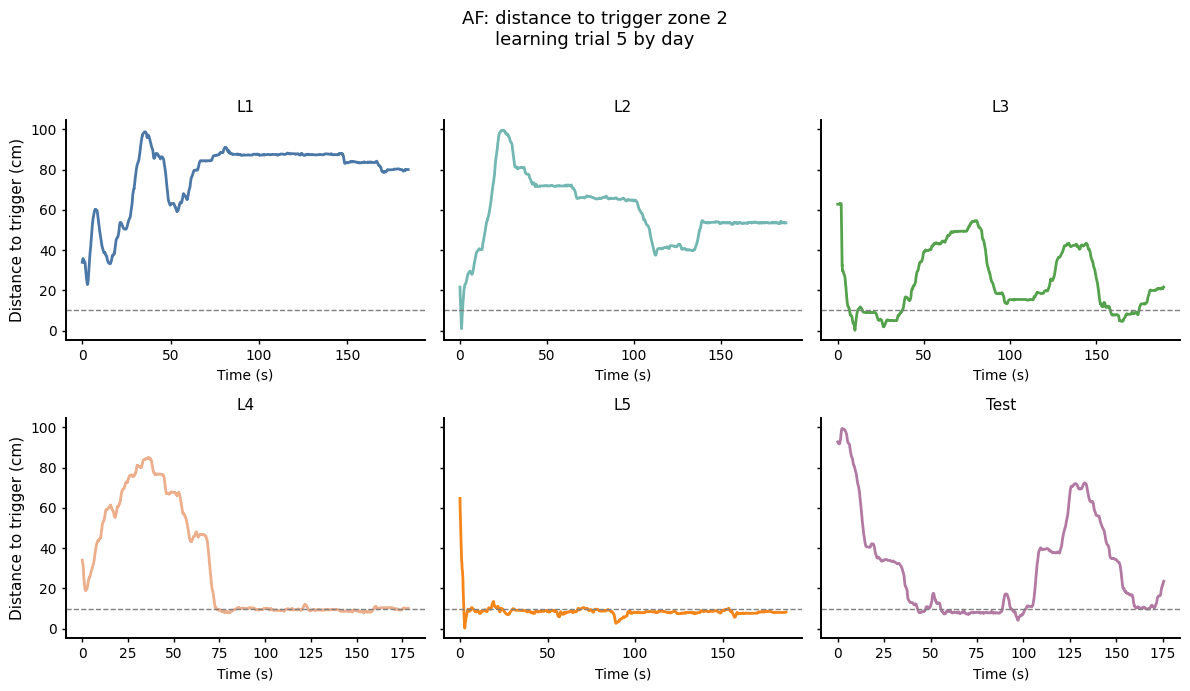

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# OPTIONS
# ============================================================
ANIMAL_ID              = 'AF'              # e.g. 'AB'
TRIGGER_TO_PLOT        = 2                 # 1 or 2
PLOT_MODE              = 'single_trial'    # 'single_trial' or 'mean_all_trials'
LEARNING_TRIAL_TO_PLOT = 5                 # which learning trial to plot (1..8)
INCLUDE_TEST_DAY       = True              # True -> include first T session after learning
N_INTERP_POINTS        = 400               # only used for mean_all_trials. When you use the mean option, the distance values are interpolated between time points for each trial.

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# ------------------------------------------------------------
# 1) Filter to one animal, usable=1, L/T only
# ------------------------------------------------------------
mt = metadata[
    (metadata['usable'] == 1) &
    (metadata['id'] == ANIMAL_ID) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

if len(mt) == 0:
    raise ValueError(f'No usable L/T trials found for animal {ANIMAL_ID}')

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
mt['plot_day'] = np.nan

mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1..5
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

if INCLUDE_TEST_DAY:
    L_ses = mt.loc[mt['trial_type'] == 'L', 'ses']
    if len(L_ses) > 0:
        last_L_ses = L_ses.max()
        T_after = mt[(mt['trial_type'] == 'T') & (mt['ses'] > last_L_ses)]
        if len(T_after) > 0:
            first_T_ses = T_after['ses'].min()
            idx = mt.index[
                (mt['trial_type'] == 'T') &
                (mt['ses'] == first_T_ses)
            ]
            mt.loc[idx, 'plot_day'] = 6

plot_days = [1, 2, 3, 4, 5] + ([6] if INCLUDE_TEST_DAY else [])
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Ensure trial_in_day exists
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    sort_cols = [c for c in ['ses', 'trial_type_day', 'trial_id'] if c in mt.columns]
    if len(sort_cols) == 0:
        sort_cols = ['ses']
    mt = mt.sort_values(sort_cols).copy()
    mt['trial_in_day'] = mt.groupby('ses').cumcount() + 1

mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 4) Helper: load one trial trace
# ------------------------------------------------------------
def load_distance_trace(meta_row, trigger_to_plot=1):
    dl = DataLoader(meta_row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        return None, None

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) < trigger_to_plot:
        return None, None

    pos_ = add_dist_to_trigger(position.copy(), triggerLoc)

    dist_col = f'dist_to_trigger_{trigger_to_plot}'
    if dist_col not in pos_.columns:
        return None, None

    # time in seconds from trial start
    t = pos_['t'].values.astype(float)
    t = (t - t[0]) / 1000.0

    # convert to real cm
    d = pos_[dist_col].values.astype(float) * 1.2

    ok = np.isfinite(t) & np.isfinite(d)
    if ok.sum() < 2:
        return None, None

    return t[ok], d[ok]

# ------------------------------------------------------------
# 5) Helper: average traces on common grid
# ------------------------------------------------------------
def average_traces(trace_list, n_points=400):
    trace_list = [(t, d) for (t, d) in trace_list if t is not None and d is not None and len(t) >= 2]
    if len(trace_list) == 0:
        return None, None, None

    max_t = np.nanmax([t[-1] for t, d in trace_list])
    common_t = np.linspace(0, max_t, n_points)

    interp_mat = []
    for t, d in trace_list:
        di = np.interp(common_t, t, d)
        di[common_t > t[-1]] = np.nan
        interp_mat.append(di)

    interp_mat = np.vstack(interp_mat)
    mean_d = np.nanmean(interp_mat, axis=0)
    n_per_t = np.sum(~np.isnan(interp_mat), axis=0)
    sem_d = np.nanstd(interp_mat, axis=0) / np.sqrt(np.maximum(n_per_t, 1))

    return common_t, mean_d, sem_d

# ------------------------------------------------------------
# 6) Make 6 little figures (subplots)
# ------------------------------------------------------------
day_labels = {1:'L1', 2:'L2', 3:'L3', 4:'L4', 5:'L5', 6:'Test'}
day_colors = {
    1:'#4C78A8',
    2:'#72B7B2',
    3:'#54A24B',
    4:'#ECAE8B',
    5:'#F58518',
    6:'#B279A2'
}

n_days = len(plot_days)
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, day in zip(axes, plot_days):
    md = mt[mt['plot_day'] == day].copy()
    md = md.sort_values('trial_in_day')

    if len(md) == 0:
        ax.set_title(day_labels[day])
        ax.axis('off')
        continue

    # ---- choose which trial(s) to use ----
    if PLOT_MODE == 'single_trial':
        if day <= 5:
            # learning days: use chosen trial number
            md_use = md[md['trial_in_day'] == LEARNING_TRIAL_TO_PLOT].copy()
        else:
            # test day: still use first/only trial
            md_use = md.iloc[[0]].copy()

    elif PLOT_MODE == 'mean_all_trials':
        md_use = md.copy()

    else:
        raise ValueError("PLOT_MODE must be 'single_trial' or 'mean_all_trials'")

    traces = []
    for _, row in md_use.iterrows():
        t, d = load_distance_trace(row, trigger_to_plot=TRIGGER_TO_PLOT)
        if t is not None:
            traces.append((t, d))

    if len(traces) == 0:
        ax.set_title(day_labels[day])
        ax.axis('off')
        continue

    if PLOT_MODE == 'single_trial':
        t, d = traces[0]
        ax.plot(
            t, d,
            color=day_colors[day],
            linewidth=2.0
        )
    else:
        common_t, mean_d, sem_d = average_traces(traces, n_points=N_INTERP_POINTS)
        ax.fill_between(
            common_t,
            mean_d - sem_d,
            mean_d + sem_d,
            color=day_colors[day],
            alpha=0.18,
            linewidth=0
        )
        ax.plot(
            common_t, mean_d,
            color=day_colors[day],
            linewidth=2.2
        )

    # real trigger boundary
    ax.axhline(10, color='0.5', linestyle='--', linewidth=1.0)

    ax.set_title(day_labels[day], fontsize=11)
    ax.set_xlabel('Time (s)', fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

# hide unused panels if fewer than 6
for j in range(len(plot_days), len(axes)):
    axes[j].axis('off')

axes[0].set_ylabel('Distance to trigger (cm)', fontsize=11)
axes[3].set_ylabel('Distance to trigger (cm)', fontsize=11)

if PLOT_MODE == 'single_trial':
    mode_text = f'learning trial {LEARNING_TRIAL_TO_PLOT}'
else:
    mode_text = 'mean of all trials'

fig.suptitle(
    f'{ANIMAL_ID}: distance to trigger zone {TRIGGER_TO_PLOT}\n{mode_text} by day',
    fontsize=13,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [240]:
# ============================================================
# 1) Compute GDI and store into metadata
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# OPTIONS
# ============================================================
TRIGGER_TO_USE = 2

BOARD_SCALE_TO_REAL = 1.2

REWARD_RADIUS_REAL_CM = 10.0
REWARD_RADIUS_ANALYSIS = REWARD_RADIUS_REAL_CM / BOARD_SCALE_TO_REAL

SPEED_THRESH_REAL = 1.0
SPEED_THRESH_ANALYSIS = SPEED_THRESH_REAL / BOARD_SCALE_TO_REAL

MIN_APPROACH_BOUT_S = 0.0

REQUIRE_MIN_REWARD_STAY = False
MIN_REWARD_STAY_MS = 2000

SMOOTH_WIN_S = 0.25

USE_NEGATIVE_SLOPE_START = True
REQUIRE_DIRECT_NEGATIVE_TO_ENTRY = True
# ✅ if REQUIRE_DIRECT_NEGATIVE_TO_ENTRY = True, ONLY duration-based tolerance for positive slope runs, no distance-based tolerance
MAX_POSITIVE_SLOPE_GAP_S = 0.15   # ← key parameter

# output columns
GDI_COL = f'GDI_trigger{TRIGGER_TO_USE}'
APPROACH_TIME_COL = f'approach_time_trigger{TRIGGER_TO_USE}'
ACTIVE_OUTSIDE_TIME_COL = f'active_outside_time_trigger{TRIGGER_TO_USE}'
N_BOUTS_COL = f'n_approach_bouts_trigger{TRIGGER_TO_USE}'

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata[GDI_COL] = np.nan
metadata[APPROACH_TIME_COL] = np.nan
metadata[ACTIVE_OUTSIDE_TIME_COL] = np.nan
metadata[N_BOUTS_COL] = np.nan

# ============================================================
# Helpers
# ============================================================
def moving_average(x, win_pts):
    if win_pts <= 1:
        return x.copy()
    kernel = np.ones(win_pts) / win_pts
    return np.convolve(x, kernel, mode='same')

def contiguous_segments(mask):
    diff = np.diff(np.r_[False, mask, False].astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return list(zip(starts, ends))

def load_trial_distance_and_speed(meta_row, trigger_to_use):
    dl = DataLoader(meta_row)

    position = dl.get_data('position')
    triggerLoc = dl.get_data('triggerLoc')

    if position is None or triggerLoc is None:
        return None

    pos = add_speed(position.copy())
    pos = add_dist_to_trigger(pos, triggerLoc)

    dist_col = f'dist_to_trigger_{trigger_to_use}'
    if dist_col not in pos.columns:
        return None

    t = (pos['t'].values - pos['t'].values[0]) / 1000.0
    d = pos[dist_col].values.astype(float)
    speed = pos['speed'].values.astype(float)

    ok = np.isfinite(t) & np.isfinite(d) & np.isfinite(speed)
    if ok.sum() < 2:
        return None

    return t[ok], d[ok], speed[ok]

# ============================================================
# CORE FUNCTION
# ============================================================
def compute_gdi_one_trial(
    t_s,
    d,
    speed,
    reward_radius,
    speed_thresh,
    min_approach_bout_s,
    require_min_reward_stay,
    min_reward_stay_s,
    use_negative_slope_start,
    smooth_win_s,
    require_direct_negative_to_entry,
    max_positive_gap_s,
):
    if len(t_s) < 2:
        return np.nan, np.nan, np.nan, 0

    dt = np.nanmedian(np.diff(t_s))
    if dt <= 0:
        return np.nan, np.nan, np.nan, 0

    outside = d > reward_radius
    active = speed > speed_thresh

    active_outside = outside & active
    active_outside_time = np.sum(active_outside) * dt

    if active_outside_time <= 0:
        return np.nan, 0, 0, 0

    inside = d <= reward_radius
    visits = contiguous_segments(inside)

    # smooth + slope
    win_pts = max(1, int(round(smooth_win_s / dt)))
    d_smooth = moving_average(d, win_pts)
    slope = np.gradient(d_smooth, t_s)

    min_bout_pts = max(1, int(round(min_approach_bout_s / dt)))
    min_stay_pts = max(1, int(round(min_reward_stay_s / dt)))
    max_gap_pts = int(round(max_positive_gap_s / dt))

    approach_mask = np.zeros(len(t_s), bool)
    n_bouts = 0

    for s_in, e_in in visits:

        if require_min_reward_stay and (e_in - s_in + 1 < min_stay_pts):
            continue

        j = s_in - 1
        if j < 0 or not outside[j]:
            continue

        e0 = j
        while j >= 0 and outside[j] and active[j]:
            j -= 1
        s0 = j + 1

        if s0 > e0:
            continue

        # define start
        if use_negative_slope_start:
            neg = slope[s0:e0+1] < 0
            if not np.any(neg):
                continue
            s_bout = s0 + np.where(neg)[0][0]
        else:
            s_bout = s0

        e_bout = e0

        if require_direct_negative_to_entry:
            bad = slope[s_bout:e_bout+1] > 0
            if np.any(bad):
                bad_runs = contiguous_segments(bad)
                if any((e - s + 1) > max_gap_pts for s, e in bad_runs):
                    continue

        if (e_bout - s_bout + 1) < min_bout_pts:
            continue

        approach_mask[s_bout:e_bout+1] = True
        n_bouts += 1

    approach_time = np.sum(approach_mask) * dt
    gdi = approach_time / active_outside_time if active_outside_time > 0 else np.nan

    return gdi, approach_time, active_outside_time, n_bouts

# ============================================================
# MAIN LOOP
# ============================================================
for i in tqdm(range(len(metadata))):

    out = load_trial_distance_and_speed(metadata.iloc[i], TRIGGER_TO_USE)
    if out is None:
        continue

    t, d, speed = out

    gdi, at, tot, nb = compute_gdi_one_trial(
        t, d, speed,
        REWARD_RADIUS_ANALYSIS,
        SPEED_THRESH_ANALYSIS,
        MIN_APPROACH_BOUT_S,
        REQUIRE_MIN_REWARD_STAY,
        MIN_REWARD_STAY_MS / 1000.0,
        USE_NEGATIVE_SLOPE_START,
        SMOOTH_WIN_S,
        REQUIRE_DIRECT_NEGATIVE_TO_ENTRY,
        MAX_POSITIVE_SLOPE_GAP_S,
    )

    metadata.at[i, GDI_COL] = gdi
    metadata.at[i, APPROACH_TIME_COL] = at
    metadata.at[i, ACTIVE_OUTSIDE_TIME_COL] = tot
    metadata.at[i, N_BOUTS_COL] = nb

metadata[[GDI_COL, APPROACH_TIME_COL, ACTIVE_OUTSIDE_TIME_COL, N_BOUTS_COL]].head()

 11%|█▏        | 707/6195 [00:07<00:46, 117.05it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 19%|█▉        | 1184/6195 [00:11<00:41, 121.98it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 42%|████▏     | 2606/6195 [00:22<00:20, 175.84it/s]

...

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-071_id-C1/ses-01_date-20260326/behav/sub-071_ses-01_trial-06_data-position.csv' does not exist.


 87%|████████▋ | 5420/6195 [00:44<00:06, 117.69it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


100%|██████████| 6195/6195 [00:51<00:00, 120.19it/s]


,GDI_trigger2,approach_time_trigger2,active_outside_time_trigger2,n_approach_bouts_trigger2
0,0.010411,2.324,223.216,2.0
1,0.017723,2.667,150.486,3.0
2,0.026597,3.179,119.527,1.0
3,0.014040,2.550,181.625,1.0
4,0.014552,1.926,132.354,2.0



Groups used for plotting: ['ChR2', 'NAc', 'Control']
Original genotypes loaded: ['CA1_control', 'ChR2', 'NAc', 'NAc_control', 'eYFP_ChR2']
Control pooled from: ['eYFP_ChR2', 'NAc_control', 'CA1_control']

Animals plotted:
  VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  NAc (NAc): n = 7, ids = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control): n = 11, ids = ['E (eYFP_ChR2)', 'EE (eYFP_ChR2)', 'EF (eYFP_ChR2)', 'F (eYFP_ChR2)', 'G (eYFP_ChR2)', 'C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']


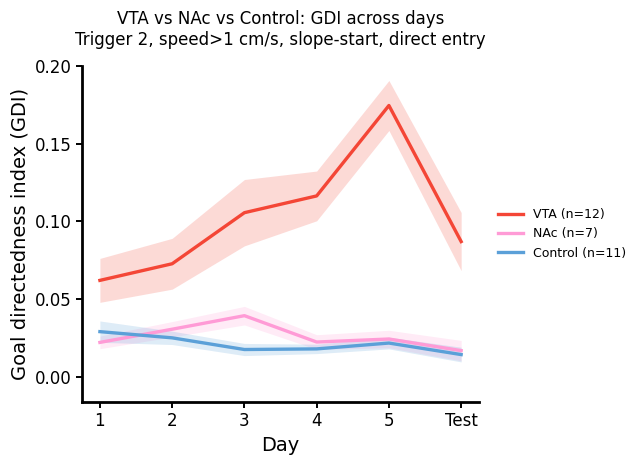

In [241]:
# ============================================================
# Plot GDI across L1-L5 + Test
#
# Adds pooled group:
#   'Control' = eYFP_ChR2 + NAc_control + CA1_control
#
# You can now use:
#   GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']
#   GROUPS = ['NAc', 'Control']
#   GROUPS = ['CA1_control', 'NAc_control']
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
# GROUPS = ['ChR2', 'ChR2_short','eYFP_ChR2']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA3']
GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['eYFP_ChR2', 'CA1_control', 'NAc_control']
# GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']
# GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']

# These original genotypes will be pooled into genotype == 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'NAc_control', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'Control': 'Control',
}

EXCLUDE_ID = ['AS', 'AN']     # e.g. ['AS', 'AN']
EXCLUDE_SUBS = []             # e.g. [43]

REQUIRE_COMPLETE = False      # True -> only animals with all L1-L5 + Test

SHOW_ANIMAL_IDS_DAY1 = False
DAY1_LABEL_X_OFFSET = 0.00
DAY1_LABEL_Y_OFFSET = 0.00
DAY1_LABEL_FONTSIZE = 8

PLOT_INDIVIDUAL = False
PLOT_GROUP_MEAN = True
SHOW_SEM_SHADING = True
PLOT_SEM_ERRORBAR = False

# y-axis options
YMIN = None              # e.g. 0, or None for auto
YMAX = 0.2               # e.g. 1, or None for auto
Y_BOTTOM_PAD_FRAC = 0.08
Y_TICK_STEP = 0.05       # change this to 0.1, 0.5, 1, etc.

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ------------------------------------------------------------
# 1) Filter metadata
# ------------------------------------------------------------
# If GROUPS contains 'Control', load the original component genotypes.
groups_to_load = []
for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(groups_to_load)) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[GDI_COL].notna())
].copy()

# Store original genotype before pooling
meta_LT['genotype_original'] = meta_LT['genotype']

# Pool NAc_control + CA1_control into one displayed/statistical group: Control
if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day: L1-L5 + first post-learning T = Test day 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1–5
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Helpers
# ------------------------------------------------------------
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals.
    Example: N8 (NAc_control), X3 (CA1_control)
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def build_genotype_matrix(meta_group, value_col):
    rows = []
    subs = []
    ids = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)
        ids.append(get_animal_label(ms, sub))

    if len(rows) == 0:
        return None, [], []

    return np.vstack(rows), subs, ids


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.4)


def apply_y_axis(ax, ymax_candidates):
    if YMAX is not None:
        ymax = YMAX
    else:
        if len(ymax_candidates) == 0:
            ymax = 1
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    # set y tick interval
    if Y_TICK_STEP is not None:
        yticks = np.arange(0, ymax + Y_TICK_STEP, Y_TICK_STEP)
        ax.set_yticks(yticks)


def plot_group(ax, mat, subs, ids, genotype_key, label):
    if mat is None or len(subs) == 0:
        return None

    base_col = get_genotype_color(genotype_key)

    # individual animals
    if PLOT_INDIVIDUAL:
        for i, row in enumerate(mat):
            ax.plot(
                x_vals,
                row,
                '-',
                color=base_col,
                alpha=0.15,
                linewidth=1.0,
                zorder=1
            )

            if SHOW_ANIMAL_IDS_DAY1:
                ax.text(
                    x_vals[0] + DAY1_LABEL_X_OFFSET,
                    row[0] + DAY1_LABEL_Y_OFFSET,
                    ids[i],
                    fontsize=DAY1_LABEL_FONTSIZE,
                    alpha=0.8,
                    ha='right',
                    va='center',
                    color=base_col
                )

    # group mean ± SEM
    if PLOT_GROUP_MEAN:
        mean_ = np.nanmean(mat, axis=0)
        sem_ = sem_by_day(mat)

        if SHOW_SEM_SHADING:
            ax.fill_between(
                x_vals,
                mean_ - sem_,
                mean_ + sem_,
                color=base_col,
                alpha=0.20,
                linewidth=0,
                zorder=2
            )

        ax.plot(
            x_vals,
            mean_,
            '-',
            color=base_col,
            linewidth=2.4,
            label=f'{label} (n={len(subs)})',
            zorder=3
        )

        if PLOT_SEM_ERRORBAR:
            ax.errorbar(
                x_vals,
                mean_,
                yerr=sem_,
                fmt='none',
                ecolor=base_col,
                elinewidth=1.3,
                capsize=3,
                alpha=0.9,
                zorder=4
            )

        return np.nanmax(mean_ + sem_)

    return None


# ------------------------------------------------------------
# 4) Build matrices
# ------------------------------------------------------------
group_data = {}

print("\nGroups used for plotting:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

print("\nAnimals plotted:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, GDI_COL)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}): n = {len(subs_g)}, ids = {ids_g}")

# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ymax_candidates = []

for g in GROUPS:
    ymax_g = plot_group(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        group_data[g]['ids'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

    if ymax_g is not None and np.isfinite(ymax_g):
        ymax_candidates.append(ymax_g)

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Goal directedness index (GDI)', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax)

title_suffix = f'Trigger {TRIGGER_TO_USE}, speed>{SPEED_THRESH_REAL:g} cm/s'

if REQUIRE_MIN_REWARD_STAY:
    title_suffix += ', reward stay ≥2 s'

if USE_NEGATIVE_SLOPE_START:
    title_suffix += ', slope-start'

if REQUIRE_DIRECT_NEGATIVE_TO_ENTRY:
    title_suffix += ', direct entry'

group_title = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])

ax.set_title(
    f'{group_title}: GDI across days\n{title_suffix}',
    fontsize=12,
    pad=15
)

apply_y_axis(ax, ymax_candidates)

ax.legend(
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()


CHECK: exact values from line-plot matrix

VTA (ChR2)
  A: L1-L5 mean = 0.2111, Test = 0.2290, full row = [0.1036 0.1871 0.1829 0.264  0.3176 0.229 ]
  C: L1-L5 mean = 0.0725, Test = 0.1281, full row = [0.0449 0.0265 0.0467 0.0714 0.1732 0.1281]
  D: L1-L5 mean = 0.0725, Test = 0.0398, full row = [0.0401 0.0373 0.0677 0.0997 0.1178 0.0398]
  AB: L1-L5 mean = 0.1367, Test = 0.0762, full row = [0.1276 0.1064 0.1448 0.1172 0.1872 0.0762]
  AC: L1-L5 mean = 0.1053, Test = 0.1334, full row = [0.0601 0.0763 0.1138 0.1043 0.1718 0.1334]
  AD: L1-L5 mean = 0.0608, Test = 0.1036, full row = [0.0171 0.0169 0.0737 0.0582 0.138  0.1036]
  AE: L1-L5 mean = 0.0629, Test = 0.1222, full row = [0.0184 0.0325 0.0361 0.0797 0.1476 0.1222]
  AF: L1-L5 mean = 0.0624, Test = 0.0155, full row = [0.0353 0.0147 0.0187 0.1026 0.1406 0.0155]
  AG: L1-L5 mean = 0.1799, Test = 0.0798, full row = [0.1751 0.1606 0.2624 0.1279 0.1734 0.0798]
  AH: L1-L5 mean = 0.1062, Test = 0.0148, full row = [0.0579 0.0501 0.1017 

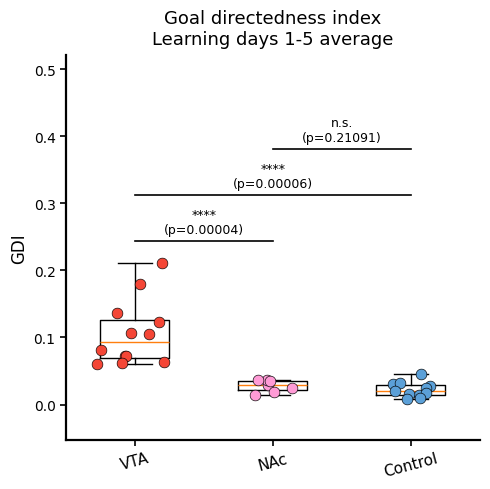


GDI boxplot from Plot 1 matrix: Test day
Animals included:
  VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  NAc (NAc): n = 7, ids = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control): n = 11, ids = ['E (eYFP_ChR2)', 'EE (eYFP_ChR2)', 'EF (eYFP_ChR2)', 'F (eYFP_ChR2)', 'G (eYFP_ChR2)', 'C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Per-animal values:
      group  sub                 id     value
0      ChR2    1                  A  0.229026
1      ChR2    3                  C  0.128115
2      ChR2    4                  D  0.039795
3      ChR2    6                 AB  0.076202
4      ChR2    7                 AC  0.133351
5      ChR2    8                 AD  0.103646
6      ChR2    9                 AE  0.122222
7      ChR2   10                 AF  0.015512
8      ChR2   11                 AG  0.079781
9      ChR2   12                 AH  0.014848
1

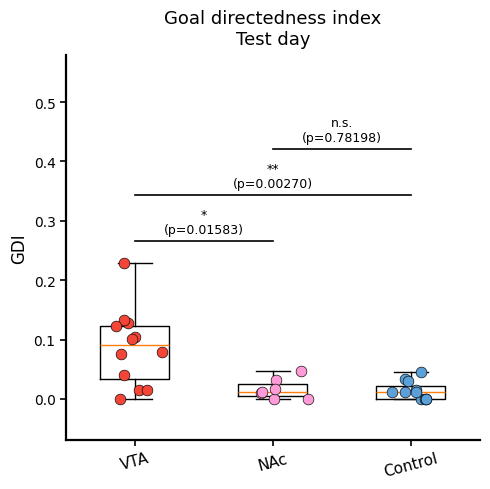

In [242]:
# ============================================================
# Boxplots from the SAME matrices used in Plot 1
#
# This guarantees:
#   - learning average = mean of mat[:, 0:5]
#   - test day = mat[:, 5]
#
# So boxplot values must match the line plot.
#
# Updates:
#   - thin black line around each dot
#   - more vertical spacing between p-value horizontal lines
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
SHOW_ANIMAL_IDS = False
COMPARISONS = 'all'

JITTER = 0.12
DOT_SIZE = 60

# dot outline
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45

P_DECIMALS = 5

BOX_YMIN = None     # e.g. 0
BOX_YMAX = None     # e.g. 0.2
BOX_Y_PAD_FRAC = 0.30

# p-value line spacing
P_LINE_START_FRAC = 0.16   # higher first p-value line
P_LINE_STEP_FRAC = 0.34    # larger = more vertical space between p lines
P_TEXT_OFFSET_FRAC = 0.035
P_TOP_PAD_FRAC = 0.35

np.random.seed(1)

# ------------------------------------------------------------
# Safety check: make sure group_data exists from the line plot
# ------------------------------------------------------------
if 'group_data' not in globals():
    raise NameError(
        "group_data does not exist. Run the line-plot code first, "
        "because the boxplot now uses the exact same matrix as Plot 1."
    )

print("\nCHECK: exact values from line-plot matrix")
for g in GROUPS:
    mat = group_data[g]['mat']
    ids = group_data[g]['ids']

    if mat is None:
        print(f"{DISPLAY_NAME.get(g, g)} ({g}): mat is None")
        continue

    print(f"\n{DISPLAY_NAME.get(g, g)} ({g})")
    for animal_id, row in zip(ids, mat):
        learning_mean = np.nanmean(row[0:5])
        test_value = row[5]
        print(
            f"  {animal_id}: "
            f"L1-L5 mean = {learning_mean:.4f}, "
            f"Test = {test_value:.4f}, "
            f"full row = {np.round(row, 4)}"
        )

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs
    return comparisons


def style_boxplot(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.6)
    ax.spines['left'].set_linewidth(1.6)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def values_from_lineplot_matrix(g, mode):
    """
    Uses the exact same matrix from the line plot.

    mode:
      'learning_mean' -> mean of days 1-5 = mat[:, 0:5]
      'test'          -> test day = mat[:, 5]
    """
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']
    ids = group_data[g]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            value = np.nanmean(row[0:5])
        elif mode == 'test':
            value = row[5]
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value': float(value)
        })

    return pd.DataFrame(rows)


def plot_gdi_boxplot_from_matrix(mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for g in GROUPS:
        df_g = values_from_lineplot_matrix(g, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value'].values.astype(float))

    print("\n============================================================")
    print(f"GDI boxplot from Plot 1 matrix: {title_suffix}")
    print("Animals included:")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    print("\nPer-animal values:")
    meta_animal = pd.concat(
        [
            group_dfs[g].assign(group=g)
            for g in GROUPS
            if len(group_dfs[g]) > 0
        ],
        ignore_index=True
    ) if any(len(group_dfs[g]) > 0 for g in GROUPS) else pd.DataFrame()

    if len(meta_animal) > 0:
        print(meta_animal[['group', 'sub', 'id', 'value']])
    else:
        print("No data.")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(5, 1.35 * len(GROUPS)), 5))

    ax.boxplot(
        vals_groups,
        positions=np.arange(len(GROUPS)),
        widths=0.50,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        vals = vals_groups[i]

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(g),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, group_dfs[g]['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # --------------------------------------------------------
    # Stats
    # --------------------------------------------------------
    comparisons_to_run = get_comparisons(GROUPS, COMPARISONS)
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in comparisons_to_run:
        vals1 = group_dfs[g1]['value'].values.astype(float)
        vals2 = group_dfs[g2]['value'].values.astype(float)

        if len(vals1) > 0 and len(vals2) > 0:
            stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
        else:
            stat, p = np.nan, np.nan

        if np.isfinite(p):
            n1 = len(vals1)
            n2 = len(vals2)
            rank_biserial = (2 * stat) / (n1 * n2) - 1

            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={n1} vs {n2}, "
                f"mean={np.nanmean(vals1):.3f} vs {np.nanmean(vals2):.3f}, "
                f"median={np.nanmedian(vals1):.3f} vs {np.nanmedian(vals2):.3f}, "
                f"U={stat:.1f}, "
                f"rank-biserial={rank_biserial:.3f}, "
                f"p={format_p(p, P_DECIMALS)}"
            )

            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

        else:
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"p = NaN"
            )

    # --------------------------------------------------------
    # Significance bars
    # --------------------------------------------------------
    nonempty_vals = [v for v in vals_groups if len(v) > 0]

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        ymax_data = np.nanmax(all_vals)
        ymin_data = np.nanmin(all_vals)

        yrng = ymax_data - ymin_data
        if not np.isfinite(yrng) or yrng <= 0:
            yrng = max(abs(ymax_data), 0.1)

        current_y = ymax_data + P_LINE_START_FRAC * yrng
        y_step = P_LINE_STEP_FRAC * yrng

        for x1, x2, p in stats_to_draw:
            x_mid = (x1 + x2) / 2.0

            ax.plot(
                [x1, x2],
                [current_y, current_y],
                color='black',
                linewidth=1.2
            )

            ax.text(
                x_mid,
                current_y + P_TEXT_OFFSET_FRAC * yrng,
                f"{p_to_stars(p)}\n(p={format_p(p, P_DECIMALS)})",
                ha='center',
                va='bottom',
                fontsize=9
            )

            current_y += y_step

        if BOX_YMIN is None:
            ymin = ymin_data - BOX_Y_PAD_FRAC * yrng
        else:
            ymin = BOX_YMIN

        if BOX_YMAX is None:
            ymax = current_y + P_TOP_PAD_FRAC * yrng
        else:
            ymax = BOX_YMAX

        ax.set_ylim(ymin, ymax)

    # --------------------------------------------------------
    # Style
    # --------------------------------------------------------
    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=11,
        rotation=15
    )

    ax.set_ylabel('GDI', fontsize=12)

    ax.set_title(
        f'Goal directedness index\n{title_suffix}',
        fontsize=13,
        pad=8
    )

    style_boxplot(ax)

    plt.tight_layout()
    plt.show()


# ============================================================
# Produce boxplots
# ============================================================
plot_gdi_boxplot_from_matrix(
    mode='learning_mean',
    title_suffix='Learning days 1-5 average'
)

plot_gdi_boxplot_from_matrix(
    mode='test',
    title_suffix='Test day'
)

Day 1 vs Day 5: n = 12 animals
Day 1 vs Test: n = 12 animals
Wilcoxon Day1 vs Day5: p = 0.000488
Wilcoxon Day1 vs Test: p = 0.0269


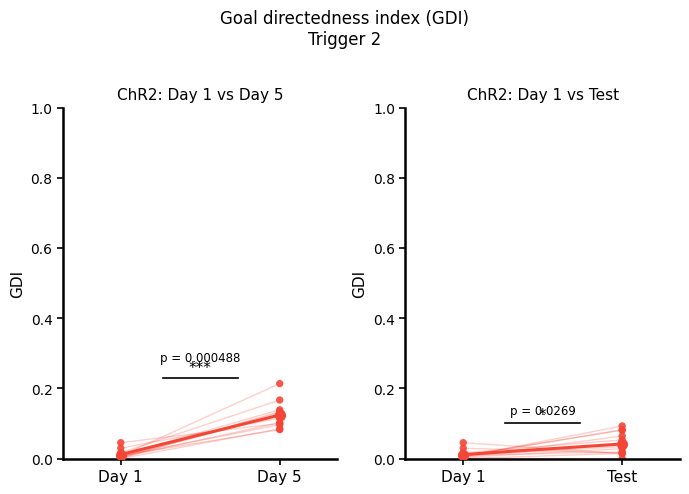

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ============================================================
# Plot 2: paired GDI comparisons
# ============================================================

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[GDI_COL].notna())
].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[(~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# Per-subject day mean GDI
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    md = meta_g[meta_g['plot_day'] == day].copy()
    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'mean_val'])

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        rows.append({
            'sub': sub,
            'mean_val': np.nanmean(ms[value_col].values.astype(float))
        })
    return pd.DataFrame(rows)

d1 = per_subject_day_mean(meta_LT, 1, GDI_COL).rename(columns={'mean_val': 'day1'})
d5 = per_subject_day_mean(meta_LT, 5, GDI_COL).rename(columns={'mean_val': 'day5'})
dt = per_subject_day_mean(meta_LT, 6, GDI_COL).rename(columns={'mean_val': 'test'})

pair_15 = d1.merge(d5, on='sub', how='inner').dropna().sort_values('sub').reset_index(drop=True)
pair_1t = d1.merge(dt, on='sub', how='inner').dropna().sort_values('sub').reset_index(drop=True)

print(f"Day 1 vs Day 5: n = {len(pair_15)} animals")
print(f"Day 1 vs Test: n = {len(pair_1t)} animals")

# ------------------------------------------------------------
# Stats
# ------------------------------------------------------------
def run_wilcoxon(a, b):
    if len(a) == 0:
        return np.nan, np.nan
    try:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, np.nan
    return stat, p

stat_15, p_15 = run_wilcoxon(pair_15['day1'].values.astype(float), pair_15['day5'].values.astype(float))
stat_1t, p_1t = run_wilcoxon(pair_1t['day1'].values.astype(float), pair_1t['test'].values.astype(float))

print(f"Wilcoxon Day1 vs Day5: p = {p_15:.3g}" if np.isfinite(p_15) else "Wilcoxon Day1 vs Day5: p = NaN")
print(f"Wilcoxon Day1 vs Test: p = {p_1t:.3g}" if np.isfinite(p_1t) else "Wilcoxon Day1 vs Test: p = NaN")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)

def draw_paired_panel(ax, df_pair, col1, col2, label1, label2, pval, title):
    x1, x2 = 0.00, 0.55

    y1 = df_pair[col1].values.astype(float)
    y2 = df_pair[col2].values.astype(float)

    # individual animals
    for _, row in df_pair.iterrows():
        ax.plot(
            [x1, x2],
            [row[col1], row[col2]],
            color=get_genotype_color('ChR2'),
            linewidth=1.0,
            alpha=0.25,
            zorder=1
        )
        ax.scatter(
            [x1, x2],
            [row[col1], row[col2]],
            s=28,
            color=get_genotype_color('ChR2'),
            edgecolor='none',
            alpha=0.9,
            zorder=2
        )

    # mean ± SEM
    def mean_sem(x):
        x = np.asarray(x, float)
        if len(x) == 0:
            return np.nan, np.nan
        if len(x) == 1:
            return x[0], 0.0
        return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))

    m1, s1 = mean_sem(y1)
    m2, s2 = mean_sem(y2)

    ax.plot([x1, x2], [m1, m2], '-', color=get_genotype_color('ChR2'), linewidth=2.2, zorder=3)
    ax.errorbar(x1, m1, yerr=s1, fmt='o', color=get_genotype_color('ChR2'), markersize=7, capsize=3, linewidth=1.4, zorder=4)
    ax.errorbar(x2, m2, yerr=s2, fmt='o', color=get_genotype_color('ChR2'), markersize=7, capsize=3, linewidth=1.4, zorder=4)

    ymax = np.nanmax(np.r_[y1, y2]) if len(df_pair) > 0 else 1
    yline = ymax + 0.08 * max(ymax, 0.1)
    ystar = ymax + 0.11 * max(ymax, 0.1)
    yp = ymax + 0.25 * max(ymax, 0.1)

    xmid = (x1 + x2) / 2
    half_len = 0.13
    ax.plot([xmid - half_len, xmid + half_len], [yline, yline], color='k', lw=1.2, zorder=5)
    ax.text(xmid, ystar, p_to_stars(pval), ha='center', va='bottom', fontsize=11, zorder=6)
    ax.text(xmid, yp, f'p = {pval:.3g}' if np.isfinite(pval) else 'p = NaN',
            ha='center', va='bottom', fontsize=8.5, zorder=6)

    ax.set_xticks([x1, x2])
    ax.set_xticklabels([label1, label2], fontsize=11)
    ax.set_ylabel('GDI', fontsize=11)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlim(-0.20, 0.75)
    ax.set_ylim(0, max(1.0, yp + 0.05))
    style_nature(ax)

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(7.0, 4.8), sharey=False)

draw_paired_panel(
    axes[0],
    pair_15,
    'day1', 'day5',
    'Day 1', 'Day 5',
    p_15,
    'ChR2: Day 1 vs Day 5'
)

draw_paired_panel(
    axes[1],
    pair_1t,
    'day1', 'test',
    'Day 1', 'Test',
    p_1t,
    'ChR2: Day 1 vs Test'
)

fig.suptitle(
    f'Goal directedness index (GDI)\nTrigger {TRIGGER_TO_USE}',
    fontsize=12,
    y=1.02
)
plt.tight_layout()
plt.show()

In [51]:
# Compute toward fraction and store into metadata
# ============================================================

import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# OPTIONS
# ============================================================
TRIGGER_TO_USE = 2

BOARD_SCALE_TO_REAL = 1.2

# thresholds in analysis-space
REWARD_RADIUS_REAL_CM = 10.0
REWARD_RADIUS_ANALYSIS = REWARD_RADIUS_REAL_CM / BOARD_SCALE_TO_REAL

SPEED_THRESH_REAL = 1.0
SPEED_THRESH_ANALYSIS = SPEED_THRESH_REAL / BOARD_SCALE_TO_REAL

# If True:
#   only count active outside-zone periods that directly lead into reward entry
# If False:
#   count all active outside-zone time in the whole trial
REQUIRE_REWARD_ENTRY_FOR_FRACTION = False

# If reward-entry restriction is on, optionally require >= 2 s stay in reward zone
REQUIRE_MIN_REWARD_STAY = False
MIN_REWARD_STAY_MS = 2000

# smooth distance before computing slope sign
SMOOTH_WIN_S = 0.25

# ignore tiny near-zero slopes
SLOPE_EPS_ANALYSIS = 1e-12

# output columns
TOWARD_TIME_COL = f'toward_time_trigger{TRIGGER_TO_USE}'
AWAY_TIME_COL = f'away_time_trigger{TRIGGER_TO_USE}'
TOWARD_FRACTION_COL = f'toward_fraction_trigger{TRIGGER_TO_USE}'
N_ENTRY_PERIODS_COL = f'n_entry_periods_trigger{TRIGGER_TO_USE}'

# ============================================================
# Load metadata
# ============================================================
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata[TOWARD_TIME_COL] = np.nan
metadata[AWAY_TIME_COL] = np.nan
metadata[TOWARD_FRACTION_COL] = np.nan
metadata[N_ENTRY_PERIODS_COL] = np.nan

# ============================================================
# Helpers
# ============================================================
def moving_average(x, win_pts):
    x = np.asarray(x, float)
    if win_pts <= 1:
        return x.copy()
    kernel = np.ones(win_pts, dtype=float) / win_pts
    return np.convolve(x, kernel, mode='same')

def contiguous_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) == 0:
        return []
    diff = np.diff(np.r_[False, mask, False].astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return list(zip(starts, ends))

def load_trial_distance_and_speed(meta_row, trigger_to_use):
    dl = DataLoader(meta_row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        return None

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) < trigger_to_use:
        return None

    pos = add_speed(position.copy())
    pos = add_dist_to_trigger(pos, triggerLoc)

    dist_col = f'dist_to_trigger_{trigger_to_use}'
    if dist_col not in pos.columns or 'speed' not in pos.columns:
        return None

    t_ms = pos['t'].values.astype(float)
    t_s = (t_ms - t_ms[0]) / 1000.0

    # keep analysis-space units internally
    d_analysis = pos[dist_col].values.astype(float)
    speed_analysis = pos['speed'].values.astype(float)

    ok = np.isfinite(t_s) & np.isfinite(d_analysis) & np.isfinite(speed_analysis)
    if ok.sum() < 2:
        return None

    return t_s[ok], d_analysis[ok], speed_analysis[ok]

def compute_toward_fraction_one_trial(
    t_s,
    d_analysis,
    speed_analysis,
    reward_radius_analysis,
    speed_thresh_analysis,
    require_reward_entry_for_fraction=True,
    require_min_reward_stay=False,
    min_reward_stay_s=2.0,
    smooth_win_s=0.25,
    slope_eps_analysis=1e-12,
):
    """
    Toward fraction =
        toward_time / (toward_time + away_time)

    where:
      toward_time = active + outside-zone + negative slope
      away_time   = active + outside-zone + positive slope

    If require_reward_entry_for_fraction=True:
      only count active outside-zone periods that directly precede reward entry.
    Otherwise:
      count all active outside-zone time in the whole trial.
    """

    t_s = np.asarray(t_s, float)
    d_analysis = np.asarray(d_analysis, float)
    speed_analysis = np.asarray(speed_analysis, float)

    if len(t_s) < 2:
        return np.nan, np.nan, np.nan, 0

    dt = np.nanmedian(np.diff(t_s))
    if not np.isfinite(dt) or dt <= 0:
        return np.nan, np.nan, np.nan, 0

    outside_zone = d_analysis > reward_radius_analysis
    inside_zone = d_analysis <= reward_radius_analysis
    active = speed_analysis > speed_thresh_analysis

    smooth_win_pts = max(1, int(round(smooth_win_s / dt)))
    d_smooth = moving_average(d_analysis, smooth_win_pts)
    dd_dt = np.gradient(d_smooth, t_s)

    toward_mask = np.zeros(len(t_s), dtype=bool)
    away_mask = np.zeros(len(t_s), dtype=bool)
    n_entry_periods = 0

    if require_reward_entry_for_fraction:
        visit_segments = contiguous_segments(inside_zone)
        min_reward_stay_pts = max(1, int(round(min_reward_stay_s / dt)))

        for s_in, e_in in visit_segments:
            if require_min_reward_stay and ((e_in - s_in + 1) < min_reward_stay_pts):
                continue

            j = s_in - 1
            if j < 0:
                continue

            # must immediately come from outside reward zone
            if not outside_zone[j]:
                continue

            # walk backward through active + outside-zone time
            e0 = j
            while j >= 0 and outside_zone[j] and active[j]:
                j -= 1
            s0 = j + 1

            if s0 > e0:
                continue

            slope_seg = dd_dt[s0:e0 + 1]

            toward_local = slope_seg < -slope_eps_analysis
            away_local = slope_seg > slope_eps_analysis

            toward_mask[s0:e0 + 1] |= toward_local
            away_mask[s0:e0 + 1] |= away_local
            n_entry_periods += 1

    else:
        valid_mask = outside_zone & active
        toward_mask = valid_mask & (dd_dt < -slope_eps_analysis)
        away_mask = valid_mask & (dd_dt > slope_eps_analysis)
        n_entry_periods = np.nan

    toward_time_s = np.sum(toward_mask) * dt
    away_time_s = np.sum(away_mask) * dt

    denom = toward_time_s + away_time_s
    toward_fraction = np.nan if denom <= 0 else toward_time_s / denom

    return toward_time_s, away_time_s, toward_fraction, n_entry_periods

# ============================================================
# Main loop
# ============================================================
for trial_id in tqdm(range(len(metadata))):
    out = load_trial_distance_and_speed(metadata.iloc[trial_id], TRIGGER_TO_USE)
    if out is None:
        continue

    t_s, d_analysis, speed_analysis = out

    toward_time_s, away_time_s, toward_fraction, n_entry_periods = compute_toward_fraction_one_trial(
        t_s=t_s,
        d_analysis=d_analysis,
        speed_analysis=speed_analysis,
        reward_radius_analysis=REWARD_RADIUS_ANALYSIS,
        speed_thresh_analysis=SPEED_THRESH_ANALYSIS,
        require_reward_entry_for_fraction=REQUIRE_REWARD_ENTRY_FOR_FRACTION,
        require_min_reward_stay=REQUIRE_MIN_REWARD_STAY,
        min_reward_stay_s=MIN_REWARD_STAY_MS / 1000.0,
        smooth_win_s=SMOOTH_WIN_S,
        slope_eps_analysis=SLOPE_EPS_ANALYSIS,
    )

    metadata.at[trial_id, TOWARD_TIME_COL] = toward_time_s
    metadata.at[trial_id, AWAY_TIME_COL] = away_time_s
    metadata.at[trial_id, TOWARD_FRACTION_COL] = toward_fraction
    metadata.at[trial_id, N_ENTRY_PERIODS_COL] = n_entry_periods

metadata[[
    'sub', 'ses', 'trial_type', 'trial_type_day',
    TOWARD_TIME_COL, AWAY_TIME_COL, TOWARD_FRACTION_COL, N_ENTRY_PERIODS_COL
]].head()

 15%|█▌        | 708/4609 [00:07<00:35, 109.20it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1178/4609 [00:11<00:35, 97.87it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2608/4609 [00:23<00:11, 169.29it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:40<00:00, 114.78it/s]


,sub,ses,trial_type,trial_type_day,toward_time_trigger2,away_time_trigger2,toward_fraction_trigger2,n_entry_periods_trigger2
0,1,1,H,1,107.436,115.752,0.481370,NaN
1,1,1,H,1,72.828,77.658,0.483952,NaN
2,1,1,H,1,55.471,63.954,0.464484,NaN
3,1,1,H,1,86.050,95.550,0.473844,NaN
4,1,1,H,1,62.928,69.372,0.475646,NaN


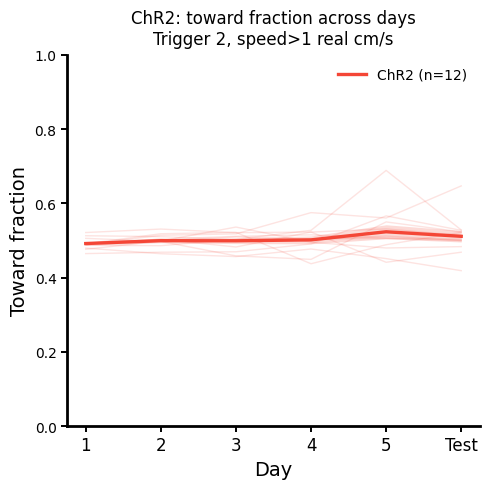

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot toward fraction across L1-L5 + Test for ChR2
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
SHOW_ANIMAL_IDS_DAY1 = False
DAY1_LABEL_X_OFFSET = 0.0
DAY1_LABEL_Y_OFFSET = 0.0
DAY1_LABEL_FONTSIZE = 8

VALUE_COL = TOWARD_FRACTION_COL

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

# ------------------------------------------------------------
# Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[(~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# Build subject x day matrix
# ------------------------------------------------------------
rows = []
subs = []

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]
    mean_by_day = ms.groupby('plot_day')[VALUE_COL].mean()
    vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

    if np.any(np.isnan(vals)):
        continue

    rows.append(vals)
    subs.append(sub)

if len(rows) == 0:
    print("No animals with complete L1-L5 + Test toward fraction.")
else:
    mat = np.vstack(rows)

    mean_ = np.nanmean(mat, axis=0)
    sem_ = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(mat.shape[0]) if mat.shape[0] > 1 else np.zeros(mat.shape[1])

    x_vals = plot_days - 1

    fig, ax = plt.subplots(figsize=(5, 5))

    # individual animals in background
    for i, row in enumerate(mat):
        ax.plot(
            x_vals, row,
            '-',
            color=get_genotype_color('ChR2'),
            alpha=0.15,
            linewidth=1.0,
            zorder=1
        )

        if SHOW_ANIMAL_IDS_DAY1:
            ax.text(
                x_vals[0] + DAY1_LABEL_X_OFFSET,
                row[0] + DAY1_LABEL_Y_OFFSET,
                str(subs[i]),
                fontsize=DAY1_LABEL_FONTSIZE,
                alpha=0.8,
                ha='right',
                va='center'
            )

    # group mean ± SEM
    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=get_genotype_color('ChR2'),
        alpha=0.20,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals, mean_,
        '-',
        color=get_genotype_color('ChR2'),
        linewidth=2.4,
        label=f'ChR2 (n={len(subs)})',
        zorder=3
    )

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Toward fraction', fontsize=14)
    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.set_ylim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.4)

    title_suffix = f'Trigger {TRIGGER_TO_USE}, speed>{SPEED_THRESH_REAL:g} real cm/s'
    if REQUIRE_REWARD_ENTRY_FOR_FRACTION:
        title_suffix += ', entry-linked'
    if REQUIRE_MIN_REWARD_STAY:
        title_suffix += ', reward stay ≥2 s'

    ax.set_title(f'ChR2: toward fraction across days\n{title_suffix}', fontsize=12, pad=8)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

In [17]:

# ============================================================
# Compute mean speed per trial:
#   1) mean_speed          = mean over all timepoints
#   2) mean_speed_moving   = mean after removing "still" samples
# Store both into metadata.
# ============================================================

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata['mean_speed'] = np.nan          # cm/s, includes still time
metadata['mean_speed_moving'] = np.nan   # cm/s, excludes still time

# --- SETTINGS ---
# Define "still" as speed <= STILL_THRESH (cm/s)
STILL_THRESH = 0.0   # keep 0.0 if still samples are exactly 0; set e.g. 0.5 if you want a small threshold
# ----------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)

    if 'speed' not in pos.columns:
        continue

    speeds = pos['speed'].values.astype(float)

    # finite only
    speeds = speeds[np.isfinite(speeds)]
    if len(speeds) == 0:
        continue

    # 1) mean speed including still time
    metadata.at[trial_id, 'mean_speed'] = float(np.nanmean(speeds))

    # 2) mean speed excluding still time (moving only)
    moving = speeds[speeds > STILL_THRESH]
    if len(moving) > 0:
        metadata.at[trial_id, 'mean_speed_moving'] = float(np.nanmean(moving))
    else:
        metadata.at[trial_id, 'mean_speed_moving'] = np.nan

metadata[['sub','ses','trial_type','trial_type_day','mean_speed','mean_speed_moving']].head()

 16%|█▌        | 725/4609 [00:04<00:24, 157.89it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1198/4609 [00:07<00:20, 164.54it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2619/4609 [00:15<00:06, 286.27it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:24<00:00, 185.46it/s]


,sub,ses,trial_type,trial_type_day,mean_speed,mean_speed_moving
0,1,1,H,1,13.183545,14.252018
1,1,1,H,1,9.790948,10.727092
2,1,1,H,1,9.168459,11.081422
3,1,1,H,1,9.678405,11.026503
4,1,1,H,1,10.652230,11.998895


ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


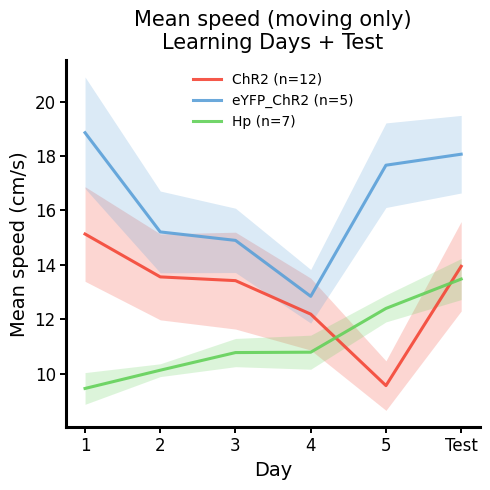

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# OPTION: choose which speed metric to plot
#   'mean_speed'         -> includes still time
#   'mean_speed_moving'  -> excludes still time
# ============================================================
SPEED_COL = 'mean_speed_moving'          # <-- change to 'mean_speed_moving' to plot moving-only

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, three genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create plot_day: learning = 1–5, test = 6 (assigned per animal)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix (SPEED_COL), require complete days
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, require_complete=True):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[SPEED_COL].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2'].copy()
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp'].copy()

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2, require_complete=True)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP, require_complete=True)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp,   require_complete=True)

print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
print("Hp animals plotted:", len(subs_Hp))

# ------------------------------------------------------------
# 3) Plot (mean ± shaded SEM only)
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, color, label, alpha_fill=0.22, alpha_line=0.9):
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    plt.plot(
        x_vals,
        mean_,
        '-',
        color=color,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

plot_group_shaded(mat_ChR2, subs_ChR2,
                  color=get_genotype_color('ChR2'),
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  color=get_genotype_color('eYFP_ChR2'),
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  color=get_genotype_color('Hp'),
                  label='Hp')

# ------------------------------------------------------------
# axis + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean speed (cm/s)', fontsize=14)

plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)

title_metric = "Mean speed" if SPEED_COL == "mean_speed" else "Mean speed (moving only)"
plt.title(f'{title_metric}\nLearning Days + Test', fontsize=15, pad=8)

plt.tight_layout()
plt.show()

[Per-trial paired] n=1280 trials | Wilcoxon p=7.37e-211
  mean(mean_speed)        = 10.933 cm/s
  mean(mean_speed_moving) = 12.748 cm/s
  mean(diff moving-all)   = 1.815 cm/s

[Per-animal paired] n=12 animals | Wilcoxon p=0.000488
  mean(mean_speed)        = 11.524 cm/s
  mean(mean_speed_moving) = 13.291 cm/s
  mean(diff moving-all)   = 1.766 cm/s


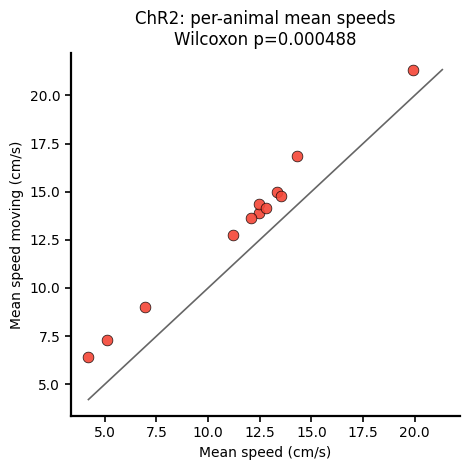

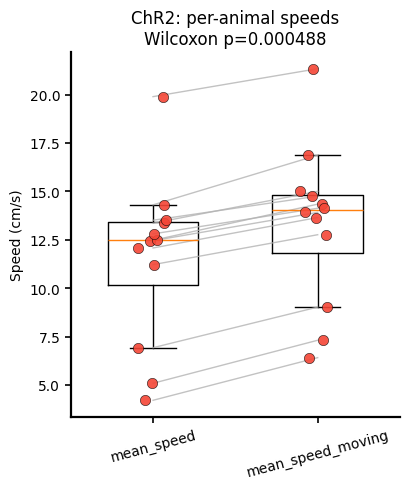

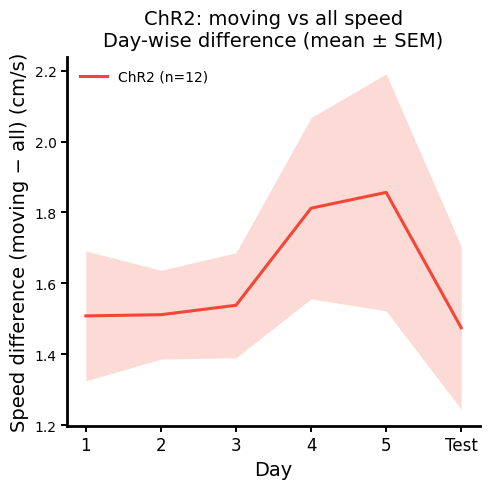

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ============================================================
# Compare mean_speed vs mean_speed_moving for ChR2
#  - does two paired comparisons:
#      (A) per-trial (paired by trial row)
#      (B) per-animal (paired by sub mean across trials)
#  - makes 2 plots:
#      (1) paired scatter (mean_speed vs mean_speed_moving)
#      (2) paired boxplot + connecting lines
#  - PLUS (NEW):
#      (3) day-wise difference across L1–L5 + Test (day 6)
# ============================================================

COL_ALL    = 'mean_speed'
COL_MOVING = 'mean_speed_moving'

# -----------------------------
# 1) Filter ChR2 trials with both metrics present
# -----------------------------
m = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata[COL_ALL].notna()) &
    (metadata[COL_MOVING].notna())
].copy()

# ===== (A) per-trial paired test =====
a_trial = m[COL_ALL].astype(float).values
b_trial = m[COL_MOVING].astype(float).values

stat_t, p_t = wilcoxon(b_trial, a_trial, alternative='two-sided')
print(f"[Per-trial paired] n={len(a_trial)} trials | Wilcoxon p={p_t:.3g}")
print(f"  mean(mean_speed)        = {np.nanmean(a_trial):.3f} cm/s")
print(f"  mean(mean_speed_moving) = {np.nanmean(b_trial):.3f} cm/s")
print(f"  mean(diff moving-all)   = {np.nanmean(b_trial - a_trial):.3f} cm/s")

# ===== (B) per-animal paired test =====
per_sub = (
    m.groupby('sub')[[COL_ALL, COL_MOVING]]
     .mean()
     .dropna()
)

a_sub = per_sub[COL_ALL].astype(float).values
b_sub = per_sub[COL_MOVING].astype(float).values

if len(per_sub) >= 2:
    stat_s, p_s = wilcoxon(b_sub, a_sub, alternative='two-sided')
    print(f"\n[Per-animal paired] n={len(a_sub)} animals | Wilcoxon p={p_s:.3g}")
    print(f"  mean(mean_speed)        = {np.nanmean(a_sub):.3f} cm/s")
    print(f"  mean(mean_speed_moving) = {np.nanmean(b_sub):.3f} cm/s")
    print(f"  mean(diff moving-all)   = {np.nanmean(b_sub - a_sub):.3f} cm/s")
else:
    print("\n[Per-animal paired] Not enough animals with both metrics to run Wilcoxon.")

# -----------------------------
# 2) Plot 1: scatter (per-animal means)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.scatter(a_sub, b_sub, s=60, color=get_genotype_color('ChR2'), edgecolor='k', linewidth=0.5, alpha=0.9)

# identity line
lo = np.nanmin(np.concatenate([a_sub, b_sub]))
hi = np.nanmax(np.concatenate([a_sub, b_sub]))
ax.plot([lo, hi], [lo, hi], '-', color='k', lw=1.2, alpha=0.6)

ax.set_xlabel('Mean speed (cm/s)')
ax.set_ylabel('Mean speed moving (cm/s)')
ax.set_title(f'ChR2: per-animal mean speeds\nWilcoxon p={p_s:.3g}' if len(per_sub) >= 2 else 'ChR2: per-animal mean speeds')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.6)
ax.spines['left'].set_linewidth(1.6)
ax.tick_params(direction='out', length=4, width=1.2)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Plot 2: paired boxplot (per-animal means) + lines
# -----------------------------
fig, ax = plt.subplots(figsize=(4.2, 5))

data = [a_sub, b_sub]
positions = [0, 1]
labels = ['mean_speed', 'mean_speed_moving']

ax.boxplot(data, positions=positions, widths=0.55, patch_artist=False, showfliers=False)

# paired lines + points
for i in range(len(a_sub)):
    ax.plot(positions, [a_sub[i], b_sub[i]], '-', color='0.7', lw=1.0, alpha=0.8, zorder=2)
ax.scatter(np.random.normal(0, 0.06, size=len(a_sub)), a_sub, s=55, color=get_genotype_color('ChR2'),
           edgecolor='k', linewidth=0.4, alpha=0.9, zorder=3)
ax.scatter(np.random.normal(1, 0.06, size=len(b_sub)), b_sub, s=55, color=get_genotype_color('ChR2'),
           edgecolor='k', linewidth=0.4, alpha=0.9, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Speed (cm/s)')
ax.set_title(f'ChR2: per-animal speeds\nWilcoxon p={p_s:.3g}' if len(per_sub) >= 2 else 'ChR2: per-animal speeds')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.6)
ax.spines['left'].set_linewidth(1.6)
ax.tick_params(direction='out', length=4, width=1.2)
plt.tight_layout()
plt.show()

# ============================================================
# (NEW) 4) Plot 3: day-wise difference (moving - all) across L1–L5 + Test
#   - builds plot_day like your other scripts:
#       L: trial_type_day (1..5)
#       T: first post-learning test session = day 6 (per animal)
#   - per animal: mean over trials within each day
#   - plots group mean ± SEM of the DIFFERENCE per day
# ============================================================

m_day = m[
    (m['trial_type'].isin(['L', 'T'])) &
    (m['trial_type_day'].notna())
].copy()

m_day['plot_day'] = np.nan
mask_L = (m_day['trial_type'] == 'L')
m_day.loc[mask_L, 'plot_day'] = m_day.loc[mask_L, 'trial_type_day']

for sub in m_day['sub'].unique():
    ms = m_day[m_day['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue
    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = m_day.index[
        (m_day['sub'] == sub) &
        (m_day['trial_type'] == 'T') &
        (m_day['ses'] == first_T_ses)
    ]
    m_day.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
m_day = m_day[m_day['plot_day'].isin(plot_days)].copy()

# per-trial diff
m_day['diff_moving_minus_all'] = m_day[COL_MOVING].astype(float) - m_day[COL_ALL].astype(float)

# build subject x day matrix of diffs (require complete 6 days)
rows = []
subs = []
for sub in m_day['sub'].unique():
    ms = m_day[m_day['sub'] == sub]
    mean_by_day = ms.groupby('plot_day')['diff_moving_minus_all'].mean()
    vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)
    if np.any(np.isnan(vals)):
        continue
    rows.append(vals)
    subs.append(sub)

if len(rows) == 0:
    print("\n[Day-wise plot] No animals with complete L1–L5 + Test for both speed metrics.")
else:
    mat = np.vstack(rows)
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    x_vals = plot_days - 1  # 0..5

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=get_genotype_color('ChR2'),
        alpha=0.20,
        linewidth=0
    )
    ax.plot(
        x_vals, mean_,
        '-',
        color=get_genotype_color('ChR2'),
        linewidth=2.2,
        label=f'ChR2 (n={len(subs)})'
    )

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Speed difference (moving − all) (cm/s)', fontsize=14)
    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1','2','3','4','5','Test'], fontsize=12)
    ax.tick_params(direction='out', length=4, width=1.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)

    ax.set_title('ChR2: moving vs all speed\nDay-wise difference (mean ± SEM)', fontsize=14, pad=8)

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

Animals included (learning trials only):
  ChR2: 12
  eYFP: 5


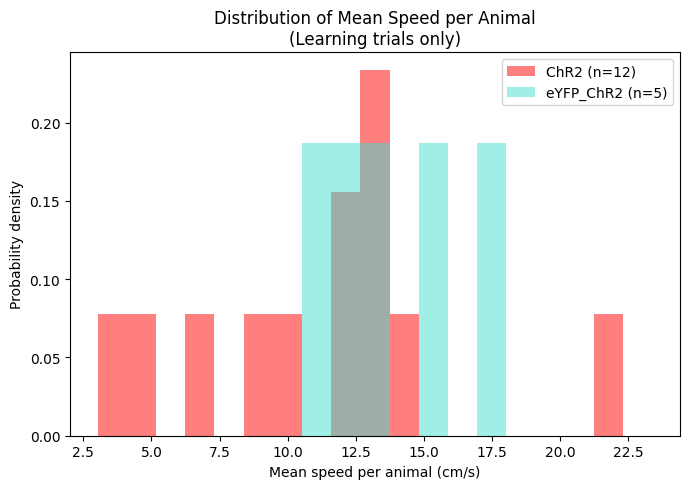

In [21]:
# Distribution of Mean Speed per Animal
# 1) Restrict to LEARNING trials only
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['mean_speed'].notna())
].copy()

# ------------------------------------------------------------
# 2) Per-animal mean speed (average across learning trials)
# ------------------------------------------------------------
meta_animal = (
    meta_L
    .groupby(['genotype', 'sub'])['mean_speed']
    .mean()
    .reset_index()
)

speeds_ChR2 = meta_animal.loc[
    meta_animal['genotype'] == 'ChR2', 'mean_speed'
].values

speeds_eYFP = meta_animal.loc[
    meta_animal['genotype'] == 'eYFP_ChR2', 'mean_speed'
].values

print("Animals included (learning trials only):")
print("  ChR2:", len(speeds_ChR2))
print("  eYFP:", len(speeds_eYFP))

# ------------------------------------------------------------
# 3) Plot histogram
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

bins = np.linspace(
    np.nanmin(meta_animal['mean_speed']),
    np.nanmax(meta_animal['mean_speed']),
    20
)

plt.hist(
    speeds_ChR2,
    bins=bins,
    color='red',
    alpha=0.5,
    density=True,
    label=f'ChR2 (n={len(speeds_ChR2)})'
)

plt.hist(
    speeds_eYFP,
    bins=bins,
    color='turquoise',
    alpha=0.5,
    density=True,
    label=f'eYFP_ChR2 (n={len(speeds_eYFP)})'
)

plt.xlabel('Mean speed per animal (cm/s)')
plt.ylabel('Probability density')
plt.title('Distribution of Mean Speed per Animal\n(Learning trials only)')
plt.legend()
plt.tight_layout()
plt.show()

Speed samples per day:
  Day 1: 456899
  Day 2: 443936
  Day 3: 466650
  Day 4: 437309
  Day 5: 423805
  Day 6: 56880


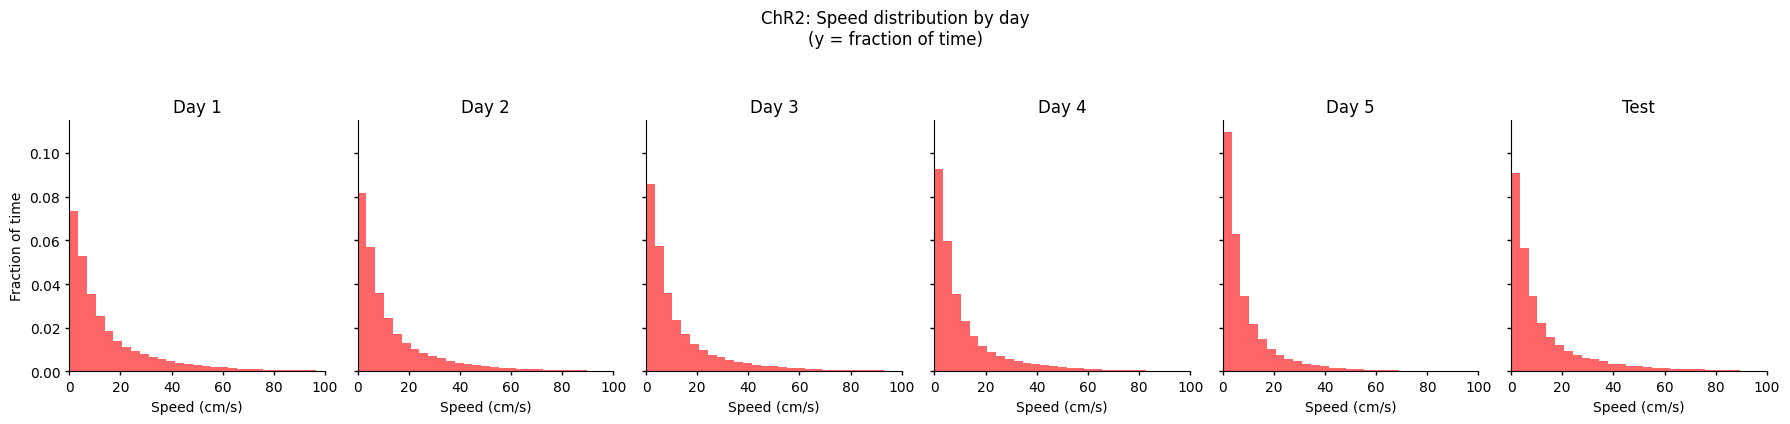

In [ ]:
# =============================================================
# Speed distribution by day (ChR2: L1–L5 + Test)
# =============================================================

days = [1, 2, 3, 4, 5, 6]  # now includes test as day 6

# ------------------------------------------------------------
# 1) Filter usable trials for ChR2 (L + T)
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L','T']))
].copy()

# assign learning trial days 1–5
meta_LT.loc[meta_LT['trial_type']=='L', 'plot_day'] = meta_LT['trial_type_day']

# ------------------------------------------------------------
# 2) Assign FIRST TEST session after learning → plot_day = 6
# ------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub']==sub]

    L_ses = ms.loc[ms['trial_type']=='L', 'ses']
    if len(L_ses)==0:
        continue
    last_L = L_ses.max()

    T_after = ms[(ms['trial_type']=='T') & (ms['ses'] > last_L)]
    if len(T_after)==0:
        continue

    first_T = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub']==sub) &
        (meta_LT['trial_type']=='T') &
        (meta_LT['ses']==first_T)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# keep only days 1–6
meta_LT = meta_LT[meta_LT['plot_day'].isin(days)]

# ------------------------------------------------------------
# 3) Collect SPEED samples per plot_day
# ------------------------------------------------------------
speed_by_day = {d: [] for d in days}

for idx, row in meta_LT.iterrows():
    dl = DataLoader(row)
    pos = dl.get_data('position')
    if pos is None or len(pos)<2:
        continue

    pos = add_speed(pos)
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]
    speeds = speeds[speeds>0]

    if len(speeds)==0:
        continue
    
    speed_by_day[int(row['plot_day'])].append(speeds)

# concatenate
for d in days:
    speed_by_day[d] = np.concatenate(speed_by_day[d]) if len(speed_by_day[d])>0 else np.array([])

print("Speed samples per day:")
for d in days:
    print(f"  Day {d}: {len(speed_by_day[d])}")

# ------------------------------------------------------------
# 4) Plot histograms (fraction of time)
# ------------------------------------------------------------

col = get_genotype_color('ChR2')
bins = np.linspace(0, 100, 30)

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=True)

labels = {1:'Day 1', 2:'Day 2', 3:'Day 3', 4:'Day 4', 5:'Day 5', 6:'Test'}

for ax, d in zip(axes, days):
    speeds = speed_by_day[d]
    
    ax.hist(
        speeds,
        bins=bins,
        density=True,
        color=col,
        alpha=0.8,
        edgecolor='none'
    )
    
    ax.set_xlim(0,100)
    ax.set_title(labels[d])
    ax.set_xlabel('Speed (cm/s)')
    if d == 1:
        ax.set_ylabel('Fraction of time')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)

fig.suptitle('ChR2: Speed distribution by day\n(y = fraction of time)',
             y=1.05, fontsize=12)

plt.tight_layout()
plt.show()

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.
ChR2 animals plotted: 12


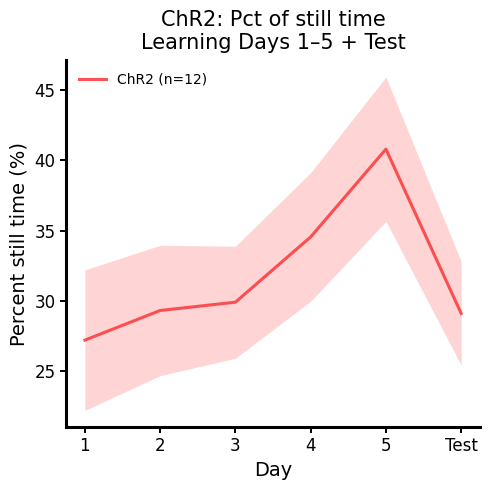

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Compute % still time per trial (using speed threshold)
# ============================================================

STILL_THRESH = 2.0  # cm/s, change if you like

# add column if not present
if 'pct_still' not in metadata.columns:
    metadata['pct_still'] = np.nan

for trial_id in range(len(metadata)):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)  # must create pos['speed']
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        continue

    pct_still = 100.0 * np.mean(speeds < STILL_THRESH)
    metadata.at[trial_id, 'pct_still'] = pct_still

# ============================================================
# 2) Build L1–5 + Test (day 6) for ChR2 only
# ============================================================

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_still'].notna())
].copy()

# init plot_day
meta_LT['plot_day'] = np.nan

# L trials: trial_type_day 1–5
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# assign first T session after last L as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1–5 + Test
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)]

# ============================================================
# 3) Subject × day matrix: % still time
# ============================================================

def build_matrix_pct_still(meta_g, require_complete=True):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_still'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs

mat_ChR2, subs_ChR2 = build_matrix_pct_still(meta_LT, require_complete=True)
print("ChR2 animals plotted:", len(subs_ChR2))

# ============================================================
# 4) Plot mean ± shaded SEM (ChR2 only)
# ============================================================

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 (for label convenience)

col = get_genotype_color('ChR2')

if mat_ChR2 is not None and len(subs_ChR2) > 0:
    mean_ = np.nanmean(mat_ChR2, axis=0)
    sem_  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])

    # shaded SEM
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=0.22,
        linewidth=0
    )

    # mean line (no markers if you don’t want dots)
    plt.plot(
        x_vals, mean_,
        '-',                # use '-' to avoid dots; '-o' if you want dots
        color=col,
        alpha=0.9,
        linewidth=2.2,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# axes + style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent still time (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('ChR2: Pct of still time\nLearning Days 1–5 + Test', fontsize=15, pad=8)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [23]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# (optionally require ≥2000 ms stay)
# ------------------------------------------------------------

metadata['mean_speed_to_trigger'] = np.nan

R_TRIGGER = (10 / 1.2)

# ----------------------------
# TOGGLE THIS
# ----------------------------
USE_MIN_DURATION = False      # set False to ignore duration
MIN_DURATION_MS = 2000       # ms
# ----------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    # add speed + distance info
    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect all trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # never entered any reward zone
    if len(dfs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    # ----------------------------
    # OPTIONAL: require ≥2000 ms stay
    # ----------------------------
    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        # never satisfied criterion → use full trial
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue
    # ----------------------------

    # first qualifying entry time
    t_enter_first = df_all.iloc[0]['t_enter']

    # speed up to that time
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = 0.0
        continue

    metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(
        pos_['speed'].iloc[idxs]
    )

 15%|█▌        | 714/4609 [00:06<00:32, 119.20it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1183/4609 [00:10<00:27, 123.30it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2610/4609 [00:21<00:13, 145.65it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:36<00:00, 126.20it/s]


In [34]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# ALSO compute mean speed while MOVING (remove still-time samples)
#
# Special rule for trials that never reach ANY reward zone:
#   - Find mean time-to-first-reward for ChR2 animals on THAT plot_day
#   - Use that time window to compute speeds for the non-reach trial
#   - If no ChR2 reaches exist for that day → fallback to full trial
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from tqdm import tqdm

# ----------------------------
# SETTINGS / TOGGLES
# ----------------------------
R_TRIGGER = (10 / 1.2)

USE_MIN_DURATION = False     # set False to ignore duration
MIN_DURATION_MS = 2000       # ms

# define "moving" (remove still time)
MOVING_EPS = 1e-6            # speed > MOVING_EPS counts as moving

# columns to write
COL_MEAN_ALL   = 'mean_speed_to_trigger'
COL_MEAN_MOVE  = 'mean_speed_moving_to_trigger'

metadata[COL_MEAN_ALL]  = np.nan
metadata[COL_MEAN_MOVE] = np.nan

# ------------------------------------------------------------
# 0) Make plot_day for all L/T trials (L1–5, Test=6)
#     (same idea as your other scripts)
# ------------------------------------------------------------
metadata['plot_day'] = np.nan

mask_LT = metadata['trial_type'].isin(['L', 'T'])
mask_L  = (metadata['trial_type'] == 'L') & mask_LT
metadata.loc[mask_L, 'plot_day'] = metadata.loc[mask_L, 'trial_type_day']

for sub in metadata.loc[mask_LT, 'sub'].unique():
    ms = metadata[(metadata['sub'] == sub) & mask_LT]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = metadata.index[
        (metadata['sub'] == sub) &
        (metadata['trial_type'] == 'T') &
        (metadata['ses'] == first_T_ses)
    ]
    metadata.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 1) PASS 1: For ChR2 only, collect time-to-first-reward per plot_day
# ------------------------------------------------------------
chR2_time_by_day = {d: [] for d in plot_days}

for trial_id in tqdm(range(len(metadata)), desc="Pass 1: ChR2 reach times"):
    row = metadata.iloc[trial_id]
    if row.get('genotype', None) != 'ChR2':
        continue
    d = row.get('plot_day', np.nan)
    if not np.isfinite(d):
        continue
    d = int(d)
    if d not in chR2_time_by_day:
        continue

    dl = DataLoader(row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    if len(dfs) == 0:
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        continue

    t_enter_first = float(df_all.iloc[0]['t_enter'])
    if np.isfinite(t_enter_first):
        chR2_time_by_day[d].append(t_enter_first)

# day-wise mean time-to-first-reward (ChR2)
chR2_mean_t_by_day = {}
print("\nChR2 mean time-to-first-reward per day (for fallback window):")
for d in plot_days:
    arr = np.array(chR2_time_by_day[d], dtype=float)
    m = np.nanmean(arr) if len(arr) else np.nan
    chR2_mean_t_by_day[int(d)] = m
    if np.isfinite(m):
        print(f"  Day {int(d)}: mean t_enter_first = {m:.1f} (n={len(arr)})")
    else:
        print(f"  Day {int(d)}: no ChR2 reaches (n=0)")

# ------------------------------------------------------------
# 2) PASS 2: Compute mean speeds using:
#     - actual t_enter_first if reached
#     - else fallback t_cut = ChR2 mean time for that plot_day
#     - else full trial
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata)), desc="Pass 2: compute speeds"):
    row = metadata.iloc[trial_id]

    # only L/T days make sense for plot_day logic; if missing, we still can do full-trial
    plot_day = row.get('plot_day', np.nan)
    plot_day_int = int(plot_day) if np.isfinite(plot_day) else None

    dl = DataLoader(row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # decide cutoff time t_cut (same units as pos_['t'] and df_trig['t_enter'])
    t_cut = None

    if len(dfs) > 0:
        df_all = (
            pd.concat(dfs, ignore_index=True)
            .sort_values('t_enter')
            .reset_index(drop=True)
        )
        if USE_MIN_DURATION:
            df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

        if len(df_all) > 0:
            # reached (under criterion)
            t_cut = float(df_all.iloc[0]['t_enter'])

    # if never reached: fallback to ChR2 mean time for that day
    if (t_cut is None) or (not np.isfinite(t_cut)):
        if plot_day_int is not None:
            t_fallback = chR2_mean_t_by_day.get(plot_day_int, np.nan)
            if np.isfinite(t_fallback):
                t_cut = float(t_fallback)

    # if still no cutoff: use full trial
    if (t_cut is None) or (not np.isfinite(t_cut)):
        t_cut = float(pos_['t'].max())

    # select samples up to cutoff
    idxs = np.where(pos_['t'].values <= t_cut)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, COL_MEAN_ALL]  = 0.0
        metadata.at[trial_id, COL_MEAN_MOVE] = np.nan
        continue

    speeds = pos_['speed'].iloc[idxs].values
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        metadata.at[trial_id, COL_MEAN_ALL]  = np.nan
        metadata.at[trial_id, COL_MEAN_MOVE] = np.nan
        continue

    # mean speed (includes still time)
    metadata.at[trial_id, COL_MEAN_ALL] = float(np.nanmean(speeds))

    # mean speed while moving (remove still time)
    speeds_move = speeds[speeds > MOVING_EPS]
    metadata.at[trial_id, COL_MEAN_MOVE] = float(np.nanmean(speeds_move)) if len(speeds_move) else np.nan

# quick check
metadata[['sub','ses','trial_type','trial_type_day','plot_day', COL_MEAN_ALL, COL_MEAN_MOVE]].head()

Pass 1: ChR2 reach times: 100%|██████████| 4609/4609 [00:04<00:00, 1019.39it/s]



ChR2 mean time-to-first-reward per day (for fallback window):
  Day 1: mean t_enter_first = 29707.4 (n=95)
  Day 2: mean t_enter_first = 27660.2 (n=93)
  Day 3: mean t_enter_first = 23398.1 (n=95)
  Day 4: mean t_enter_first = 22135.5 (n=96)
  Day 5: mean t_enter_first = 12404.1 (n=96)
  Day 6: mean t_enter_first = 12089.9 (n=12)


Pass 2: compute speeds:  15%|█▌        | 706/4609 [00:06<00:34, 113.40it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


Pass 2: compute speeds:  26%|██▌       | 1179/4609 [00:11<00:29, 118.21it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


Pass 2: compute speeds:  56%|█████▋    | 2603/4609 [00:22<00:11, 175.27it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


Pass 2: compute speeds: 100%|██████████| 4609/4609 [00:37<00:00, 124.43it/s]


,sub,ses,trial_type,trial_type_day,plot_day,mean_speed_to_trigger,mean_speed_moving_to_trigger
0,1,1,H,1,NaN,10.184602,10.271650
1,1,1,H,1,NaN,10.212567,10.331515
2,1,1,H,1,NaN,8.230093,8.504429
3,1,1,H,1,NaN,6.549703,6.775555
4,1,1,H,1,NaN,16.507261,18.249035



=== mean_speed_to_trigger ===
ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


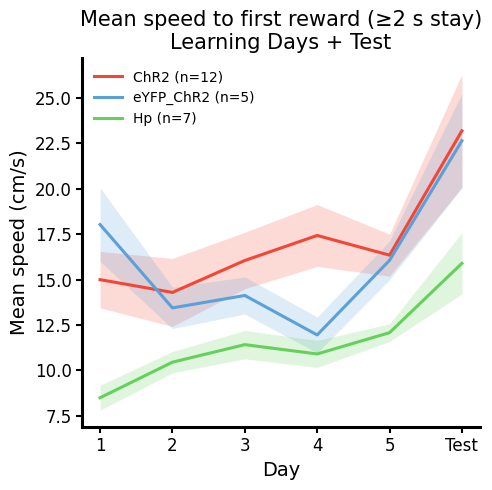

In [ ]:


# ============================================================
# Plot mean speed up to FIRST reward arrival (or fallback window)
# Groups: ChR2 vs eYFP_ChR2, optional + (ChR2_short OR Hp)
# Option: plot moving-only or overall mean speed
# Requires you already computed and stored in metadata:
#   - mean_speed_to_trigger
#   - mean_speed_moving_to_trigger
# ============================================================

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
PLOT_MOVING_ONLY = False   # False -> mean_speed_to_trigger ; True -> mean_speed_moving_to_trigger
INCLUDE_THIRD    = True   # True -> add third group
USE_SHORT        = False    # True -> third=ChR2_short ; False -> third=Hp
ADD_STAY_TAG     = False   # True -> append "(≥2 s stay)" in titles

# choose which column to plot
SPEED_COL = 'mean_speed_moving_to_trigger' if PLOT_MOVING_ONLY else 'mean_speed_to_trigger'

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp', 'ChR2_short'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (same behaviour as your other scripts)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3) Plot helper (keeps same style as your previous distance/CIPL plots)
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col, ylabel, title,
                           include_third=False, use_short=True):
    meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
    meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

    if use_short:
        third_key, third_label = 'ChR2_short', 'ChR2_short'
    else:
        third_key, third_label = 'Hp', 'Hp'
    meta_third = meta_LT[meta_LT['genotype'] == third_key]

    mat_ChR2,  subs_ChR2  = build_genotype_matrix(meta_ChR2,  value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_third, subs_third = build_genotype_matrix(meta_third, value_col)

    print(f"\n=== {value_col} ===")
    print("ChR2 animals plotted:", len(subs_ChR2))
    print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
    if include_third:
        print(f"{third_key} animals plotted:", len(subs_third))

    plt.figure(figsize=(5, 5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    plot_group(mat_ChR2, subs_ChR2, 'ChR2', 'ChR2')
    plot_group(mat_eYFP, subs_eYFP, 'eYFP_ChR2', 'eYFP_ChR2')
    if include_third:
        plot_group(mat_third, subs_third, third_key, third_label)

    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4) Call plot
# ---------------------------------------------------------------------
stay_tag = " (≥2 s stay)" if ADD_STAY_TAG else ""
moving_tag = " (moving only)" if PLOT_MOVING_ONLY else ""

plot_metric_for_groups(
    meta_LT,
    value_col=SPEED_COL,
    ylabel='Mean speed (cm/s)',
    title=f'Mean speed to first reward{moving_tag}{stay_tag}\nLearning Days + Test',
    include_third=INCLUDE_THIRD,
    use_short=USE_SHORT
)


=== mean_speed_to_trigger ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


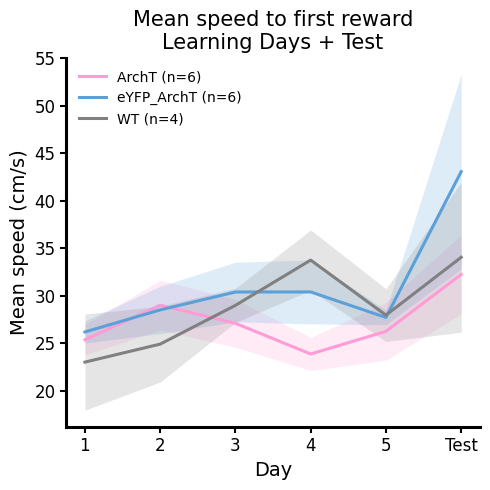

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot mean speed up to FIRST reward arrival (or fallback window)
# Groups: ArchT vs eYFP_ArchT, optional + WT
# Option: plot moving-only or overall mean speed
# Requires you already computed and stored in metadata:
#   - mean_speed_to_trigger
#   - mean_speed_moving_to_trigger
# ============================================================

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
PLOT_MOVING_ONLY = False   # False -> mean_speed_to_trigger ; True -> mean_speed_moving_to_trigger
INCLUDE_WT       = True    # True -> add WT, False -> only ArchT & eYFP_ArchT
ADD_STAY_TAG     = False    # True -> append "(≥2 s stay)" in titles

# choose which column to plot
SPEED_COL = 'mean_speed_moving_to_trigger' if PLOT_MOVING_ONLY else 'mean_speed_to_trigger'

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (same behaviour as your other scripts)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3) Plot helper (keeps same style as your previous distance/CIPL plots)
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col, ylabel, title,
                           include_wt=False):
    meta_ArchT = meta_LT[meta_LT['genotype'] == 'ArchT']
    meta_eYFP  = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']
    meta_WT    = meta_LT[meta_LT['genotype'] == 'WT']

    mat_ArchT, subs_ArchT = build_genotype_matrix(meta_ArchT, value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_WT,    subs_WT    = build_genotype_matrix(meta_WT,    value_col)

    print(f"\n=== {value_col} ===")
    print("ArchT animals plotted:", len(subs_ArchT))
    print("eYFP_ArchT animals plotted:", len(subs_eYFP))
    if include_wt:
        print("WT animals plotted:", len(subs_WT))

    plt.figure(figsize=(5, 5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    plot_group(mat_ArchT, subs_ArchT, 'ArchT', 'ArchT')
    plot_group(mat_eYFP,  subs_eYFP,  'eYFP_ArchT', 'eYFP_ArchT')
    if include_wt:
        plot_group(mat_WT, subs_WT, 'WT', 'WT')

    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4) Call plot
# ---------------------------------------------------------------------
stay_tag   = " (≥2 s stay)" if ADD_STAY_TAG else ""
moving_tag = " (moving only)" if PLOT_MOVING_ONLY else ""

plot_metric_for_groups(
    meta_LT,
    value_col=SPEED_COL,
    ylabel='Mean speed (cm/s)',
    title=f'Mean speed to first reward{moving_tag}{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

Animals plotted:
  ChR2: 10
  eYFP: 5


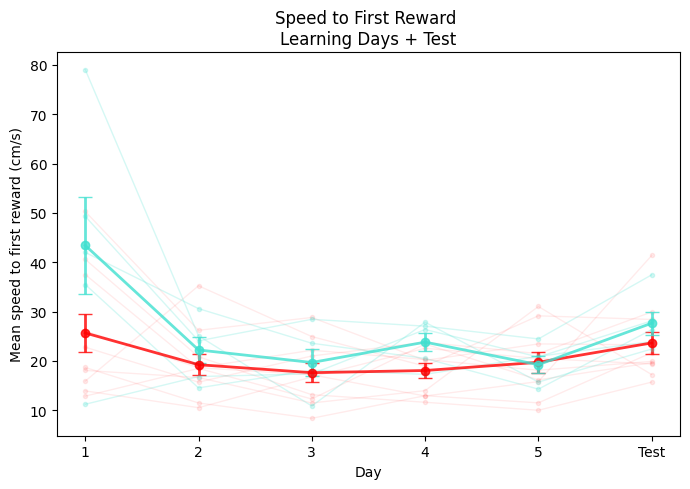

In [100]:
# Speed to first reward zone entry
# Plot ChR2 vs eYFP_ChR2 vs Hp

# ------------------------------------------------------------
# 1) Filter metadata 
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
   # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
        ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['mean_speed_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Assign plot_day (L = 1–5, first T after learning = 6)
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan
meta_LT.loc[meta_LT['trial_type'] == 'L', 'plot_day'] = meta_LT['trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 3) Subject × day matrix
# ------------------------------------------------------------
def build_matrix(meta_g):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]
        mean_by_day = ms.groupby('plot_day')['mean_speed_to_trigger'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs


#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
#meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_matrix(meta_eYFP)
#mat_Hp,   subs_Hp   = build_matrix(meta_Hp)

print("Animals plotted:")
print("  ChR2:", len(subs_ChR2))
print("  eYFP:", len(subs_eYFP))
#print("  Hp  :", len(subs_Hp))

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------

SHOW_INDIVIDUALS = True   # <<< TOGGLE THIS (True / False)

plt.figure(figsize=(7, 5))
x = plot_days - 1

def plot_group(mat, color, label, alpha_mean=0.7, alpha_ind=0.15):
    if mat is None or mat.shape[0] == 0:
        return

    # ----------------------------
    # individual animals (optional)
    # ----------------------------
    if SHOW_INDIVIDUALS:
        for row in mat:
            plt.plot(
                x, row, '-o',
                color=color,
                alpha=alpha_ind,
                linewidth=1,
                markersize=3,
                label='_nolegend_'
            )

    # ----------------------------
    # mean ± SEM
    # ----------------------------
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        alpha=alpha_mean,
        linewidth=2,
        capsize=5,
        label=f'{label} (n={mat.shape[0]})'
    )


plot_group(mat_ChR2, 'red',        'ChR2',       alpha_mean=0.8, alpha_ind=0.08)
plot_group(mat_eYFP, 'turquoise',  'eYFP_ChR2',  alpha_mean=0.8, alpha_ind=0.22)
#plot_group(mat_Hp,   '#2ca02c',    'Hp',         alpha_mean=0.8)

plt.xlabel('Day')
plt.ylabel('Mean speed to first reward (cm/s)')
plt.title('Speed to First Reward \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'])
#plt.legend(frameon=False)
plt.tight_layout()
plt.show()
